# AM115 Mini-Project 2 Supplemental Notebook
Trey Whitehead and Liam Bieber

# Part 0: Overview

The WHL’s age cap and free agency structure make it an in-
triguing case for studying playoff predictions. Teams vying for
Memorial Cup qualification, achieved by winning the WHL,
often trade future draft picks at the deadline. These trades
bring in older, more experienced players to strengthen their
rosters and boost their chances of a championship run. This
is very similar to the behavior of championship contenders
across the majority of different Sports leagues - sacrifice future
draft capital to try to capture your ”Championship Window”.
However, the WHL’s constant roster turnover, driven by player
graduations and trades, along with the limited number of
inter-conference games, makes outcomes highly unpredictable.
Driven by these factors, the roster composition of each team
on a season-over-season basis is highly variable, making
recent season success an unreliable predictor of future returns.
Therefore, repeat champions are rare, and traditional models
implemented in other sports leagues with less roster turnover
often fall short. This project leverages historical data and
advanced modeling techniques to develop a more reliable
approach to predicting playoff success in the WHL.

## 0.1: Helpful Information

### **Playoff Format**

Playoff Format: https://chl.ca/whl/whl-playoff-format/

### **Seasons and Playoff Draws**

2023-2024 Season: https://en.wikipedia.org/wiki/2023%E2%80%9324_WHL_season

2022-2023 Season: https://en.wikipedia.org/wiki/2022%E2%80%9323_WHL_season

2021-2022 Season: https://en.wikipedia.org/wiki/2021%E2%80%9322_WHL_season

2018-2019 Season: https://en.wikipedia.org/wiki/2018%E2%80%9319_WHL_season

2017-2018 Season: https://en.wikipedia.org/wiki/2017%E2%80%9318_WHL_season

### **International Play**

Often due to travel costs and logistical difficulties, some teams will only play each other once in a season. As such, we need to add a degree of randomness to those probabilities so that they are not always 1. Perhaps, the magnitude of the probability of winning can be a function of that team's overall season record. In other words, there will be too many teams that play games and are guaranteed to win more in a mock series.

### **Cancellation of International Play during 2021-2022 Season**

News Article: https://globalnews.ca/news/8175302/whl-season-border-play-canceled/

### **Season Selection**

The 2019-2020 playoffs and 2020-2021 playoffs were canceled due to the COVID-19 pandemic. As such, we selected the five most recent seasons with full statistics.

# Part 1: Data Scraping

## 1.1: Pulling Data from the Web

Below, we use Pandas, OS, Pickle, and BeautifulSoup to pull data for the past 10 non-COVID WHL seasons. We have pulled every team's head-to-head record against every other team in that time span, and we have pulled player and team statistics over that time period as well.

**DISCLAIMER: THIS SECTION TAKES 30 MINUTES TO RUN. USE THE DOWNLOADED FILE IF YOU HAVE IT. THIS WILL BE SUBMITTED WITH THE .IPYNB CODE ITSELF. THE DOWNLOADABLE PICKLE FILES ARE NOT ABLE TO BE SUBMITTED THROUGH CANVAS. THEREFORE, IF NEEDED PLEASE EMAIL TREYWHITEHEAD@COLLEGE.HARVARD.EDU OR LIAMBIEBER@COLLEGE.HARVARD.EDU**

In [ ]:
import os
import pickle
import random
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 1.1.1: Scraping the Head-to-Head Matchups

In [ ]:
# File path to save the data locally
data_file_path = 'head_to_head_data-1.pkl'


# Function to get head-to-head matchups for all teams across multiple seasons
def get_head_to_head_matchups():
    # Base URL for head-to-head stats in HTML format
    base_url = "http://www.leaguestat.com/whl/whl/en/media/?step=4&sub=14&season_id={{season_id}}&format=HTML"

    # List of team IDs
    team_ids = [
        201, 202, 228, 226, 203, 204, 205, 206, 207,
        208, 209, 210, 211, 212, 213, 214, 215, 216,
        217, 223, 227, 222
    ]

    # Season mapping for IDs
    # Seasons denoted by the year in which they concluded
    season_mapping = {
    281: "2024", 279: "2023", 275: "2022", 266: "2019", 262: "2018",
    257: "2017", 251: "2016", 249: "2015", 245: "2014", 242: "2013"
    }

    # Check if data is already saved locally to avoid repeated requests
    if os.path.exists(data_file_path):
        print("Loading data from local file...")
        with open(data_file_path, 'rb') as f:
            dataframes = pickle.load(f)
        print("Data loaded successfully.")
        return dataframes


    # Dictionary to hold DataFrames for each team
    dataframes = {}
    # Keep track of processed team pairs to avoid duplicate requests
    # This saves us a LOT of time
    processed_pairs = set()

    # Iterate over each unique season_id
    for season_id, season_year in season_mapping.items():
        # Iterate over unique pairs of team IDs
        for i in range(len(team_ids)):
            # Ensure unique pairs
            for j in range(i + 1, len(team_ids)):
                team_id_1 = team_ids[i]
                team_id_2 = team_ids[j]

                # Construct the URL for the head-to-head stats of each team pair
                url = f"{base_url.replace('{{season_id}}', str(season_id))}&team={team_id_1}&second_team={team_id_2}"
                print(f"Downloading head-to-head stats for team ID {team_id_1} vs team ID {team_id_2} from {url}...")

                # Make the request to download the HTML
                response = requests.get(url)
                print(f"Response status code: {response.status_code}")  # Check the response status
                if response.status_code == 200:
                    # Parse the HTML content
                    soup = BeautifulSoup(response.content, 'html.parser')

                    # Find all rows that contain head-to-head records for the current season
                    rows = soup.find_all('tr', class_='lsik-schedule-tr-odd') + soup.find_all('tr', class_='lsik-schedule-tr-even')
                    # Flag to check if we found the record
                    found = False

                    for row in rows:
                        cells = row.find_all('td')
                        if len(cells) > 2 and "Head to Head Record" in cells[0].text:
                            found = True
                            team_1_info = cells[1].text.strip()
                            team_2_info = cells[2].text.strip()

                            print(f"Raw records: {team_1_info}, {team_2_info}")

                            # Split the team names from their records
                            team_1_name, team_1_record = team_1_info.rsplit(' ', 1)
                            team_2_name, team_2_record = team_2_info.rsplit(' ', 1)

                            # Map records into respective stats
                            try:
                                team_1_stats = list(map(int, team_1_record.split('-')))
                                team_2_stats = list(map(int, team_2_record.split('-')))
                            except ValueError as e:
                                print(f"Error parsing records: {e}")
                                print(f"Check the records: {team_1_record}, {team_2_record}")
                                continue

                            # Use string keys for consistency
                            team_key_1 = f"Team_{team_id_1}"
                            team_key_2 = f"Team_{team_id_2}"

                            # Add the records to each team's DataFrame list if not present
                            if team_key_1 not in dataframes:
                                dataframes[team_key_1] = []
                            if team_key_2 not in dataframes:
                                dataframes[team_key_2] = []

                            # Store each team's records against the opponent with season_id and actual season
                            dataframes[team_key_1].append({
                                'Season_ID': season_id,
                                'Season': season_year,
                                'Opponent_ID': team_key_2,
                                'Opponent_Name': team_2_name,
                                'Wins': team_1_stats[0],
                                'Losses': team_1_stats[1],
                                'OT_Losses': team_1_stats[2],
                                'SO_Loss': team_1_stats[3]
                            })
                            dataframes[team_key_2].append({
                                'Season_ID': season_id,
                                'Season': season_year,
                                'Opponent_ID': team_key_1,
                                'Opponent_Name': team_1_name,
                                'Wins': team_2_stats[0],
                                'Losses': team_2_stats[1],
                                'OT_Losses': team_2_stats[2],
                                'SO_Loss': team_2_stats[3]
                            })

                            # Mark this pair as processed
                            processed_pairs.add((team_id_1, team_id_2))
                            processed_pairs.add((team_id_2, team_id_1))
                            break
                    if not found:
                        print(f"No head-to-head record found for team IDs {team_id_1} vs {team_id_2}.")
                else:
                    print(f"Failed to download data for team IDs {team_id_1} vs {team_id_2}: {response.status_code}")

    # Convert lists to DataFrames for each team
    for team_key in dataframes:
        dataframes[team_key] = pd.DataFrame(dataframes[team_key])

    # Save the data locally to avoid re-fetching it next time
    with open(data_file_path, 'wb') as f:
      pickle.dump(dataframes, f)

    return dataframes

# Call the function and get the head-to-head matchups
head_to_head_dataframes = get_head_to_head_matchups()

# Check the keys of the returned dataframes to see what was collected
print(head_to_head_dataframes.keys())

Loading data from local file...
Data loaded successfully.
dict_keys(['Team_201', 'Team_202', 'Team_228', 'Team_226', 'Team_203', 'Team_204', 'Team_205', 'Team_206', 'Team_207', 'Team_208', 'Team_209', 'Team_210', 'Team_211', 'Team_212', 'Team_213', 'Team_214', 'Team_215', 'Team_216', 'Team_217', 'Team_223', 'Team_227', 'Team_222'])


### 1.1.2: Scraping Player and Team Statistics

In [ ]:
# Define paths where the player and goalie data will be saved locally
player_data_file_path = 'whl_player_stats.pkl'
goalie_data_file_path = 'whl_goalie_stats.pkl'

# Season mapping (Season ID -> Year)... to be used globally
season_mapping = {
    281: "2024", 279: "2023", 275: "2022", 266: "2019", 262: "2018",
    257: "2017", 251: "2016", 249: "2015", 245: "2014", 242: "2013"
}

# Base URL template
base_url = "http://www.leaguestat.com/whl/whl/en/media/index.php?season_id={season_id}&step=4&sub=1&format=HTML"

# Team ID mapping for each team name
team_id_mapping_2 = {
    'Brandon': 'Team_201',
    'Calgary': 'Team_202',
    'Kamloops': 'Team_203',
    'Kelowna': 'Team_204',
    'Lethbridge': 'Team_205',
    'Medicine Hat': 'Team_206',
    'Moose Jaw': 'Team_207',
    'Portland': 'Team_208',
    'Prince Albert': 'Team_209',
    'Prince George': 'Team_210',
    'Red Deer': 'Team_211',
    'Regina': 'Team_212',
    'Saskatoon': 'Team_213',
    'Seattle': 'Team_214',
    'Spokane': 'Team_215',
    'Swift Current': 'Team_216',
    'Tri-City': 'Team_217',
    'Wenatchee': 'Team_222',
    'Winnipeg': 'Team_222',
    'Kootenay': 'Team_222',
    'Vancouver': 'Team_223',
    'Everett': 'Team_226',
    'Victoria': 'Team_227',
    'Edmonton': 'Team_228'
}

#NOTE: Goalie stats to be used in final portion of project
def is_goalie(headers):
    goalie_keywords = ['GAA', 'SV%', 'Save%', 'GA', 'SO']
    return any(keyword in headers for keyword in goalie_keywords)

# Function to process data and return DataFrame
def process_table_data(season_id, year, team_names, stats_table, is_goalie_table, team_name):
    headers = [th.text.strip() for th in stats_table.find_all('th')]

    rows = []
    for tr in stats_table.find_all('tr', class_=['lsik-schedule-tr-even', 'lsik-schedule-tr-odd']):
        cells = tr.find_all('td')
        if cells:
            row = [cell.text.strip() for cell in cells]
            rows.append(row)

    if not rows:
        print(f"No data found for table in Season ID: {season_id}")
        return None

    team_df = pd.DataFrame(rows, columns=headers)
    team_df['Team'] = team_name
    team_df['Season_ID'] = season_id
    team_df['Season'] = year

    # Map Team name to Team_ID and add the Team_ID to the DataFrame
    team_df['Team_ID'] = team_df['Team'].map(team_id_mapping_2)

    return team_df

# Function to add Team_ID to the dataframe based on first substring match
def add_team_id_to_dataframe(df, team_id_mapping_2):
    # Create a new column for Team_ID
    df['Team_ID'] = None

    for idx, row in df.iterrows():
        # Get the first substring (word before the first space) of the team name
        team_name_substring = row['Team'].split()[0]

        # Look for a match in the team_id_mapping_2
        matching_team_id = None
        for known_team_name, team_id in team_id_mapping_2.items():
            # (case-insensitive match)
            if re.match(f"^{re.escape(team_name_substring)}", known_team_name, re.IGNORECASE):
                matching_team_id = team_id
                break

        # If a match is found, append the Team_ID
        if matching_team_id:
            df.at[idx, 'Team_ID'] = matching_team_id
        else:
            print(f"Warning: No matching Team_ID found for {row['Team']}")

    return df

# Check if player data is already saved locally to avoid repeated requests
if os.path.exists(player_data_file_path) and os.path.exists(goalie_data_file_path):
    print("Loading player and goalie data from local files...")
    with open(player_data_file_path, 'rb') as f:
        final_player_df = pickle.load(f)
    with open(goalie_data_file_path, 'rb') as f:
        final_goalie_df = pickle.load(f)
else:
    # Initialize lists to store player and goalie data
    all_player_data = []
    all_goalie_data = []

    # Iterate over each season
    for season_id, year in season_mapping.items():
        print(f"Fetching data for Season ID: {season_id}, Year: {year}")

        # Build the URL for the season
        url = base_url.format(season_id=season_id)

        # Send a GET request to fetch the HTML content
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Failed to fetch data for Season ID: {season_id}")
            continue

        soup = BeautifulSoup(response.text, 'html.parser')

        # Locate all the data tables for teams (tables with class 'data')
        tables = soup.find_all('table', class_='data')

        # Locate all <td> tags with class "tback" and extract team names
        tback_td_tag = soup.find('td', class_='tback')
        team_names = [b_tag.text.strip() for b_tag in tback_td_tag.find_all('b')]

        # Iterate over each table and corresponding team name to extract player or goalie data
        for i, stats_table in enumerate(tables):
            # Determine if the table is for goalies
            is_goalie_table = is_goalie([th.text.strip() for th in stats_table.find_all('th')])

            # Get the team name (assuming each table corresponds to one team)
            team_name = team_names[2 * (i // 2)] if is_goalie_table else team_names[i]

            # Process table data into a DataFrame
            team_df = process_table_data(season_id, year, team_names, stats_table, is_goalie_table, team_name)

            # Skip if no valid DataFrame is returned
            if team_df is None:
                continue

            # Append to the appropriate list
            (all_goalie_data if is_goalie_table else all_player_data).append(team_df)

    # Concatenate player and goalie data into separate DataFrames
    final_player_df = pd.concat(all_player_data, ignore_index=True) if all_player_data else pd.DataFrame()
    final_goalie_df = pd.concat(all_goalie_data, ignore_index=True) if all_goalie_data else pd.DataFrame()

# Rename columns for consistency
final_player_df.rename(columns={'#': 'Number'}, inplace=True)
final_goalie_df.rename(columns={'#': 'Number'}, inplace=True)

# Function to clean the DataFrame by removing rows with non-numeric or null values
def remove_rows_with_non_numeric_or_null(df, column_name):
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    return df.dropna(subset=[column_name])

# Clean the DataFrames
final_player_df_cleaned = remove_rows_with_non_numeric_or_null(final_player_df, 'Number')
final_goalie_df_cleaned = remove_rows_with_non_numeric_or_null(final_goalie_df, 'Number')

# Drop any empty columns if present
final_player_df_cleaned.drop(columns=[''], errors='ignore', inplace=True)
final_goalie_df_cleaned.drop(columns=[''], errors='ignore', inplace=True)

# Add Team_ID based on the first substring match
final_player_df_cleaned = add_team_id_to_dataframe(final_player_df_cleaned, team_id_mapping_2)
final_goalie_df_cleaned = add_team_id_to_dataframe(final_goalie_df_cleaned, team_id_mapping_2)

# Save the cleaned DataFrames to pickle files
with open(player_data_file_path, 'wb') as f:
    pickle.dump(final_player_df_cleaned, f)

with open(goalie_data_file_path, 'wb') as f:
    pickle.dump(final_goalie_df_cleaned, f)

print("Player data saved to 'whl_player_stats.pkl'")
print("Goalie data saved to 'whl_goalie_stats.pkl'")

Loading player and goalie data from local files...
Player data saved to 'whl_player_stats.pkl'
Goalie data saved to 'whl_goalie_stats.pkl'


In [ ]:
final_player_df_cleaned.replace('NaN', np.nan, inplace=True)
final_goalie_df_cleaned.replace('NaN', np.nan, inplace=True)

# Define the columns that should be numeric for players
numeric_player_columns = [
    'Number', 'GP', 'G', 'A', 'PTS', '+/-', 'PIM', 'PP', 'PPA', 'SH', 'SHA', 'GW',
    'FG', 'IG', 'OT', 'UA', 'EN', 'SOG', 'SOA', 'SOGW', 'SO%', 'Pt/G',
    'PIM/G', 'Shots', 'Sh%', 'WFO', 'FO', 'Season_ID', 'Season']

# Define the columns that should be numeric for goalies
numeric_goalie_columns = ['Number', 'Goalie', 'GP', 'MINS', 'W', 'L', 'OTL', 'SL', 'SO', 'EN', 'GA', 'GAA', 'SOGP',
    'SOW', 'SL', 'SOGA', 'SOA', 'SO%', 'SA', 'SVS', 'SV%', 'Team', 'Season_ID', 'Season']

# Convert the specified columns to numeric, coercing errors to NaN for player columns
# No issue for goalie data
for col in numeric_player_columns:
    final_player_df_cleaned[col] = pd.to_numeric(final_player_df_cleaned[col], errors='coerce')

In [ ]:
final_player_df_cleaned.columns

# Filter players with more than 10 GP
filtered_df = final_player_df_cleaned[final_player_df_cleaned['GP'] > 10]

# Group by Team and Season_ID, and calculate relevant statistics
team_info_skill_concentration = (
    filtered_df.groupby(['Team', 'Team_ID', 'Season', 'Season_ID'])
    .agg(
        # Totals
        total_goals=('G', 'sum'),
        total_assists=('A', 'sum'),
        total_points=('PTS', 'sum'),
        total_penalty_minutes=('PIM', 'sum'),
        total_powerplay_goals=('PP', 'sum'),
        total_powerplay_assists=('PPA', 'sum'),
        total_shorthanded_goals=('SH', 'sum'),
        total_shorthanded_assists=('SHA', 'sum'),
        total_game_winning_goals=('GW', 'sum'),
        total_empty_net_goals=('EN', 'sum'),
        total_shots=('Shots', 'sum'),
        total_faceoffs=('FO', 'sum'),

        # Averages and standard deviations
        avg_plus_minus_per_player=('+/-', 'mean'),
        std_plus_minus=('+/-', 'std'),
        avg_goals_per_player=('G', 'mean'),
        std_goals=('G', 'std'),
        avg_assists_per_player=('A', 'mean'),
        std_assists=('A', 'std'),
        avg_points_per_player=('PTS', 'mean'),
        std_points=('PTS', 'std'),
        avg_penalty_minutes_per_player=('PIM', 'mean'),
        std_penalty_minutes=('PIM', 'std')
    )
    .reset_index()
)

team_info_skill_concentration.head(5)

,Team,Team_ID,Season,Season_ID,total_goals,total_assists,total_points,total_penalty_minutes,total_powerplay_goals,total_powerplay_assists,total_shorthanded_goals,total_shorthanded_assists,total_game_winning_goals,total_empty_net_goals,total_shots,total_faceoffs,avg_plus_minus_per_player,std_plus_minus,avg_goals_per_player,std_goals,avg_assists_per_player,std_assists,avg_points_per_player,std_points,avg_penalty_minutes_per_player,std_penalty_minutes
0,Brandon Wheat Kings,Team_201,2013,242,185,320,505,968,47,93,6,5,20,6,0,0.0,-12.592593,11.603246,6.851852,6.199899,11.851852,8.332991,18.703704,13.908533,35.851852,36.279581
1,Brandon Wheat Kings,Team_201,2014,245,270,468,738,885,80,156,9,9,32,8,0,0.0,-2.923077,7.567949,10.384615,9.859318,18.000000,13.392535,28.384615,21.718337,34.038462,23.668512
2,Brandon Wheat Kings,Team_201,2015,249,348,625,973,796,78,158,7,8,53,19,208,0.0,19.400000,14.279939,13.920000,12.556273,25.000000,16.830033,38.920000,27.505939,31.840000,25.461867
3,Brandon Wheat Kings,Team_201,2016,251,313,550,863,930,71,146,15,17,47,10,408,0.0,16.000000,20.276929,11.592593,13.203319,20.370370,19.658915,31.962963,31.326422,34.444444,28.819509
4,Brandon Wheat Kings,Team_201,2017,257,224,375,599,1056,66,125,16,19,27,5,0,0.0,-3.862069,7.881824,7.724138,10.756714,12.931034,12.966801,20.655172,22.850877,36.413793,31.891017


In [ ]:
# Dictionary to store final records for each team
team_season_records = {}

team_ids = [
        201, 202, 228, 226, 203, 204, 205, 206, 207,
        208, 209, 210, 211, 212, 213, 214, 215, 216,
        217, 223, 227, 222
    ]

# Iterate through each team in the dictionary
for team_id in team_ids:
    team_key = f"Team_{team_id}"

    if team_key in head_to_head_dataframes:
        team_df = head_to_head_dataframes[team_key]

        # Group by season and calculate total Wins, Losses, OT Losses, and SO Losses
        season_records = team_df.groupby(['Season_ID', 'Season']).agg(
            Total_Wins=('Wins', 'sum'),
            Total_Losses=('Losses', 'sum'),
            Total_OT_Losses=('OT_Losses', 'sum'),
            Total_SO_Losses=('SO_Loss', 'sum')
        ).reset_index()

        # Calculate total points
        season_records['Ranking_Points'] = (season_records['Total_Wins'] * 2) + (
            season_records['Total_OT_Losses'] + season_records['Total_SO_Losses'])

        # Add total games played column
        season_records['Total_Games_Played'] = (
            season_records['Total_Wins'] +
            season_records['Total_Losses'] +
            season_records['Total_OT_Losses'] +
            season_records['Total_SO_Losses']
        )

        # Calculating...
        season_records['Ranking_Points_Per_Game'] = season_records['Ranking_Points'] / season_records['Total_Games_Played']

        # Add new calculated columns for win percentages and regulation percentages
        season_records['Win_Percent_Overall'] = season_records['Total_Wins'] / (
            season_records['Total_Wins'] +
            season_records['Total_Losses'] +
            season_records['Total_OT_Losses'] +
            season_records['Total_SO_Losses']
        )

        season_records['Win_Loss_Percent_Regulation'] = season_records['Total_Wins'] / (
            season_records['Total_Wins'] + season_records['Total_Losses']
        )

        season_records['Percent_Games_to_OT'] = (
            season_records['Total_OT_Losses'] + season_records['Total_SO_Losses']
        ) / (
            season_records['Total_Wins'] +
            season_records['Total_Losses'] +
            season_records['Total_OT_Losses'] +
            season_records['Total_SO_Losses']
        )

        # Add the Team_ID column for each team
        season_records['Team_ID'] = team_key

        # Add this team's season records to the dictionary
        team_season_records[team_key] = season_records

# Concatenate all team records into one DataFrame
all_team_records = pd.concat(team_season_records.values(), keys=team_season_records.keys())

all_team_records.reset_index(drop=True, inplace=True)
all_team_records.head()

,Season_ID,Season,Total_Wins,Total_Losses,Total_OT_Losses,Total_SO_Losses,Ranking_Points,Total_Games_Played,Ranking_Points_Per_Game,Win_Percent_Overall,Win_Loss_Percent_Regulation,Percent_Games_to_OT,Team_ID
0,242,2013,24,40,4,4,56,72,0.777778,0.333333,0.375000,0.111111,Team_201
1,245,2014,34,29,6,3,77,72,1.069444,0.472222,0.539683,0.125000,Team_201
2,249,2015,53,11,4,4,114,72,1.583333,0.736111,0.828125,0.111111,Team_201
3,251,2016,48,18,4,2,102,72,1.416667,0.666667,0.727273,0.083333,Team_201
4,257,2017,31,31,7,3,72,72,1.000000,0.430556,0.500000,0.138889,Team_201


In [ ]:
# Merge the two DataFrames on 'season' and 'Team_ID'
merged_data = pd.merge(team_info_skill_concentration, all_team_records,
                       left_on=['Season_ID', 'Team_ID'],
                       right_on=['Season_ID', 'Team_ID'],
                       how='inner')

merged_data

# Rename 'season_x' to 'season' and drop 'season_y'
merged_data = merged_data.rename(columns={'Season_x': 'Season'}).drop(columns=['Season_y'])

# Separate columns into non-numeric (object type) and numeric types
non_numeric_columns = merged_data.select_dtypes(include=['object']).columns
numeric_columns = merged_data.select_dtypes(exclude=['object']).columns

# Reorder the columns: non-numeric columns first, then numeric columns
final_merged_data = merged_data[non_numeric_columns.tolist() + numeric_columns.tolist()]

# Reset the index for cleaner output (optional)
final_merged_data.reset_index(drop=True, inplace=True)

# Sort the DataFrame by 'Ranking_Points_Per_Game' in descending order
top_teams = final_merged_data.sort_values(by='Ranking_Points_Per_Game', ascending=False)

# Display top teams
top_10_teams = top_teams.head(10)
top_10_teams

,Team,Team_ID,Season,Season_ID,total_goals,total_assists,total_points,total_penalty_minutes,total_powerplay_goals,total_powerplay_assists,total_shorthanded_goals,total_shorthanded_assists,total_game_winning_goals,total_empty_net_goals,total_shots,total_faceoffs,avg_plus_minus_per_player,std_plus_minus,avg_goals_per_player,std_goals,avg_assists_per_player,std_assists,avg_points_per_player,std_points,avg_penalty_minutes_per_player,std_penalty_minutes,Total_Wins,Total_Losses,Total_OT_Losses,Total_SO_Losses,Ranking_Points,Total_Games_Played,Ranking_Points_Per_Game,Win_Percent_Overall,Win_Loss_Percent_Regulation,Percent_Games_to_OT
219,Winnipeg ICE,Team_222,2023,279,353,603,956,892,72,149,17,18,63,11,2560,4555.0,20.965517,23.604604,12.172414,14.025663,20.793103,20.121735,32.965517,32.320364,30.758621,20.583723,57,10,1,0,115,68,1.691176,0.838235,0.850746,0.014706
113,Prince Albert Raiders,Team_209,2019,266,324,523,847,823,63,120,23,22,57,11,2678,4767.0,26.416667,22.665654,13.500000,13.041739,21.791667,15.723091,35.291667,27.200510,34.291667,29.525934,54,10,2,2,112,68,1.647059,0.794118,0.843750,0.058824
123,Prince George Cougars,Team_209,2019,266,149,243,392,879,46,91,3,1,16,2,1993,4250.0,-15.434783,12.698697,6.478261,7.797841,10.565217,9.365440,17.043478,15.140188,38.217391,38.948633,54,10,2,2,112,68,1.647059,0.794118,0.843750,0.058824
51,Kelowna Rockets,Team_204,2014,245,306,512,818,1137,68,127,13,11,52,12,0,0.0,18.500000,16.669133,11.769231,10.977459,19.692308,13.361944,31.461538,22.884459,43.730769,29.529047,57,11,0,4,118,72,1.638889,0.791667,0.838235,0.055556
218,Winnipeg ICE,Team_222,2022,275,334,591,925,728,77,158,5,7,53,9,2550,4645.0,20.700000,19.946739,11.133333,12.675617,19.700000,17.906173,30.833333,28.833749,24.266667,19.303266,53,10,3,2,111,68,1.632353,0.779412,0.841270,0.073529
165,Seattle Thunderbirds,Team_214,2023,279,312,534,846,931,58,119,13,20,57,17,2569,4474.0,22.517241,19.776647,10.758621,10.841900,18.413793,16.482712,29.172414,25.762749,32.103448,24.936125,54,11,1,2,111,68,1.632353,0.794118,0.830769,0.044118
97,Portland Winterhawks,Team_208,2013,242,333,570,903,1128,82,158,13,11,56,9,0,0.0,22.153846,22.538309,12.807692,15.359738,21.923077,22.743655,34.730769,37.337978,43.384615,42.175895,57,12,1,2,117,72,1.625000,0.791667,0.826087,0.041667
2,Brandon Wheat Kings,Team_201,2015,249,348,625,973,796,78,158,7,8,53,19,208,0.0,19.400000,14.279939,13.920000,12.556273,25.000000,16.830033,38.920000,27.505939,31.840000,25.461867,53,11,4,4,114,72,1.583333,0.736111,0.828125,0.111111
98,Portland Winterhawks,Team_208,2014,245,335,553,888,1162,92,175,17,14,51,10,0,0.0,19.520000,18.650559,13.400000,15.223337,22.120000,21.421018,35.520000,35.238615,46.480000,32.904052,54,13,2,3,113,72,1.569444,0.750000,0.805970,0.069444
52,Kelowna Rockets,Team_204,2015,249,320,543,863,1054,91,185,16,13,55,18,296,0.0,15.142857,13.791340,11.428571,11.377133,19.392857,16.235168,30.821429,25.277795,37.642857,28.675986,53,13,5,1,112,72,1.555556,0.736111,0.803030,0.083333


In [ ]:
final_merged_data.columns

Index(['Team', 'Team_ID', 'Season', 'Season_ID', 'total_goals',
       'total_assists', 'total_points', 'total_penalty_minutes',
       'total_powerplay_goals', 'total_powerplay_assists',
       'total_shorthanded_goals', 'total_shorthanded_assists',
       'total_game_winning_goals', 'total_empty_net_goals', 'total_shots',
       'total_faceoffs', 'avg_plus_minus_per_player', 'std_plus_minus',
       'avg_goals_per_player', 'std_goals', 'avg_assists_per_player',
       'std_assists', 'avg_points_per_player', 'std_points',
       'avg_penalty_minutes_per_player', 'std_penalty_minutes', 'Total_Wins',
       'Total_Losses', 'Total_OT_Losses', 'Total_SO_Losses', 'Ranking_Points',
       'Total_Games_Played', 'Ranking_Points_Per_Game', 'Win_Percent_Overall',
       'Win_Loss_Percent_Regulation', 'Percent_Games_to_OT'],
      dtype='object')

### 1.1.3: All Playoff Draws

In [ ]:
draws = {
    2013: {
        'Eastern': [
            ('Edmonton', 'Kootenay'),  # 1 vs 8
            ('Saskatoon', 'Medicine Hat'),     # 2 vs 7
            ('Calgary', 'Swift Current'),    # 3 vs 6
            ('Red Deer', 'Prince Albert')    # 4 vs 5
        ],
        'Western': [
            ('Portland', 'Everett'),    # 1 vs 8
            ('Kelowna', 'Seattle'),  # 2 vs 7
            ('Kamloops', 'Victoria'),  # 3 vs 6
            ('Spokane', 'Tri-City')  # 4 vs 5
        ]
    },
    2014: {
        'Eastern': [
            ('Edmonton', 'Prince Albert'),  # 1 vs 8
            ('Regina', 'Brandon'),     # 2 vs 7
            ('Calgary', 'Kootenay'),    # 3 vs 6
            ('Medicine Hat', 'Swift Current')    # 4 vs 5
        ],
        'Western': [
            ('Kelowna', 'Tri-City'),    # 1 vs 8
            ('Portland', 'Vancouver'),  # 2 vs 7
            ('Victoria', 'Spokane'),  # 3 vs 6
            ('Seattle', 'Everett')  # 4 vs 5
        ]
    },
    2015: {
        'Eastern': [
            ('Brandon', 'Edmonton'),      # 1 vs 8
            ('Regina', 'Swift Current'),      # 2 vs 7
            ('Calgary', 'Kootenay'), # 3 vs 6
            ('Medicine Hat', 'Red Deer')       # 4 vs 5
        ],
        'Western': [
            ('Kelowna', 'Tri-City'),      # 1 vs 8
            ('Victoria', 'Prince George'),  # 2 vs 7
            ('Everett', 'Spokane'),       # 3 vs 6
            ('Portland', 'Seattle')       # 4 vs 5
        ]
    },
    2016: {
        'Eastern': [
            ('Brandon', 'Edmonton'),        # 1 vs 8
            ('Prince Albert', 'Moose Jaw'),      # 2 vs 7
            ('Lethbridge', 'Regina'), # 3 vs 6
            ('Red Deer', 'Calgary')     # 4 vs 5
        ],
        'Western': [
            ('Victoria', 'Spokane'),      # 1 vs 8
            ('Kelowna', 'Kamloops'),      # 2 vs 7
            ('Seattle', 'Prince George'), # 3 vs 6
            ('Everett', 'Portland')       # 4 vs 5
        ]
    },
    2017: {
        'Eastern': [
            ('Regina', 'Calgary'),      # 1 vs 8
            ('Moose Jaw', 'Swift Current'), # 2 vs 7
            ('Medicine Hat', 'Brandon'),       # 3 vs 6
            ('Lethbridge', 'Red Deer')      # 4 vs 5
        ],
        'Western': [
            ('Everett', 'Victoria'),     # 1 vs 8
            ('Seattle', 'Tri-City'), # 2 vs 7
            ('Kelowna', 'Kamloops'),       # 3 vs 6
            ('Prince George', 'Portland')     # 4 vs 5
        ]
    },
    2018: {
        'Eastern': [
            ('Moose Jaw', 'Prince Albert'),  # 1 vs 8
            ('Swift Current', 'Regina'),     # 2 vs 7
            ('Lethbridge', 'Red Deer'),    # 3 vs 6
            ('Medicine Hat', 'Brandon')    # 4 vs 5
        ],
        'Western': [
            ('Everett', 'Seattle'),    # 1 vs 8
            ('Portland', 'Spokane'),  # 2 vs 7
            ('Victoria', 'Vancouver'),  # 3 vs 6
            ('Kelowna', 'Tri-City')  # 4 vs 5
        ]
    },
    2019: {
        'Eastern': [
            ('Prince Albert', 'Red Deer'),  # 1 vs 8
            ('Saskatoon', 'Moose Jaw'),     # 2 vs 7
            ('Edmonton', 'Medicine Hat'),    # 3 vs 6
            ('Lethbridge', 'Calgary')    # 4 vs 5
        ],
        'Western': [
            ('Everett', 'Tri-City'),    # 1 vs 8
            ('Spokane', 'Portland'),  # 2 vs 7
            ('Vancouver', 'Seattle'),  # 3 vs 6
            ('Victoria', 'Kamloops')  # 4 vs 5
        ]
    },
    2022: {
        'Eastern': [
            ('Winnipeg', 'Prince Albert'),  # 1 vs 8
            ('Moose Jaw', 'Saskatoon'),     # 2 vs 7
            ('Edmonton', 'Lethbridge'),    # 3 vs 6
            ('Red Deer', 'Brandon')    # 4 vs 5
        ],
        'Western': [
            ('Everett', 'Vancouver'),    # 1 vs 8
            ('Seattle', 'Kelowna'),  # 2 vs 7
            ('Kamloops', 'Spokane'),  # 3 vs 6
            ('Portland', 'Prince George')  # 4 vs 5
        ]
    },
    2023: {
        'Eastern': [
            ('Winnipeg', 'Medicine Hat'),  # 1 vs 8
            ('Red Deer', 'Calgary'),     # 2 vs 7
            ('Saskatoon', 'Regina'),    # 3 vs 6
            ('Moose Jaw', 'Lethbridge')    # 4 vs 5
        ],
        'Western': [
            ('Seattle', 'Kelowna'),    # 1 vs 8
            ('Kamloops', 'Vancouver'),  # 2 vs 7
            ('Portland', 'Everett'),  # 3 vs 6
            ('Prince George', 'Tri-City')  # 4 vs 5
        ]
    },
    2024: {
        'Eastern': [
            ('Saskatoon', 'Prince Albert'),  # 1 vs 8
            ('Swift Current', 'Lethbridge'),     # 2 vs 7
            ('Moose Jaw', 'Brandon'),    # 3 vs 6
            ('Medicine Hat', 'Red Deer')    # 4 vs 5
        ],
        'Western': [
            ('Prince George', 'Spokane'),    # 1 vs 8
            ('Portland', 'Victoria'),  # 2 vs 7
            ('Everett', 'Vancouver'),  # 3 vs 6
            ('Wenatchee', 'Kelowna')  # 4 vs 5
        ]
    }
}


# Updated team_id_mapping with team names and their indices
team_id_mapping = {
    'Brandon': ('Team_201', 0), 'Calgary': ('Team_202', 1), 'Kamloops': ('Team_203', 2), 'Kelowna': ('Team_204', 3), 'Lethbridge': ('Team_205', 4),
    'Medicine Hat': ('Team_206', 5), 'Moose Jaw': ('Team_207', 6), 'Portland': ('Team_208', 7), 'Prince Albert': ('Team_209', 8), 'Prince George': ('Team_210', 9),
    'Red Deer': ('Team_211', 10), 'Regina': ('Team_212', 11), 'Saskatoon': ('Team_213', 12), 'Seattle': ('Team_214', 13), 'Spokane': ('Team_215', 14),
    'Swift Current': ('Team_216', 15), 'Tri-City': ('Team_217', 16), 'Wenatchee': ('Team_222', 17), 'Winnipeg': ('Team_222', 17), 'Kootenay': ('Team_222', 17),
    'Vancouver': ('Team_223', 18), 'Everett': ('Team_226', 19), 'Victoria': ('Team_227', 20), 'Edmonton': ('Team_228', 21)
}

## 1.2: Team Names, Ids, and Season Mapping

In [ ]:
# Create a dictionary to hold team IDs and their corresponding names
team_data = {}

# Iterate through each team's DataFrame in the head_to_head_dataframes dictionary
for team_key, df in head_to_head_dataframes.items():
    for _, row in df.iterrows():
        opponent_id = row['Opponent_ID']
        opponent_name = row['Opponent_Name']

        # If the opponent ID is not in the dictionary, add it with the opponent name
        if opponent_id not in team_data:
            team_data[opponent_id] = []

        # Append the opponent name if it's not already in the list
        if opponent_name not in team_data[opponent_id]:
            team_data[opponent_id].append(opponent_name)

team_df = pd.DataFrame([
    {'Team ID': team_id, 'Team Names': ', '.join(names)} for team_id, names in team_data.items()
])

# Sort the DataFrame by 'Team ID'
team_df.sort_values(by='Team ID', inplace=True)

# Reset index for better readability
team_df.reset_index(drop=True, inplace=True)

# Display the sorted DataFrame
display(team_df)

,Team ID,Team Names
0,Team_201,Brandon
1,Team_202,Calgary
2,Team_203,Kamloops
3,Team_204,Kelowna
4,Team_205,Lethbridge
5,Team_206,Medicine Hat
6,Team_207,Moose Jaw
7,Team_208,Portland
8,Team_209,Prince Albert
9,Team_210,Prince George


In [ ]:
# Define season mapping and head-to-head data
season_mapping = {
    281: "2024", 279: "2023", 275: "2022", 266: "2019", 262: "2018",
    257: "2017", 251: "2016", 249: "2015", 245: "2014", 242: "2013"
    }

# Part 2: Building out the Probability Matrices for Head-to-Head Data

First, let's begin with a function that enables us to calculate each team's win probability for a given season against every other team.

## 2.1: Helpful Functions

In [ ]:
def calculate_probability_matrices(head_to_head_dataframes, season_id):
    # Initialize matrices for probabilities
    teams = list(head_to_head_dataframes.keys())
    num_teams = len(teams)

    win_loss_matrix = np.zeros((num_teams, num_teams))
    win_total_loss_matrix = np.zeros((num_teams, num_teams))

    # Create a mapping from team keys to indices for easier access
    team_index = {teams[i]: i for i in range(num_teams)}

    # Iterate through each team's DataFrame
    for team_key, df in head_to_head_dataframes.items():
        # Filter the DataFrame for the specified season
        df_season = df[df['Season_ID'] == season_id]

        team_idx = team_index[team_key]

        for _, row in df_season.iterrows():
            opponent_key = row['Opponent_ID']
            opponent_idx = team_index[opponent_key]

            wins = row['Wins']
            losses = row['Losses']
            ot_losses = row['OT_Losses']
            so_losses = row['SO_Loss']

            # Update win-loss matrix
            win_loss_matrix[team_idx, opponent_idx] = wins / (wins + losses) if (wins + losses) > 0 else 0.5
            win_loss_matrix[opponent_idx, team_idx] = losses / (wins + losses) if (wins + losses) > 0 else 0.5

            # Update win-total-loss matrix
            total_losses = losses + ot_losses + so_losses
            win_total_loss_matrix[team_idx, opponent_idx] = wins / (wins + total_losses) if (wins + total_losses) > 0 else 0.5
            win_total_loss_matrix[opponent_idx, team_idx] = total_losses / (wins + total_losses) if (wins + total_losses) > 0 else 0.5

    # Set the diagonal to 0.5 for self-probabilities
    np.fill_diagonal(win_loss_matrix, 0.5)
    np.fill_diagonal(win_total_loss_matrix, 0.5)

    return win_loss_matrix, win_total_loss_matrix, teams

In [ ]:
# Function for plotting probability matrix heatmaps
def plot_matrices(win_loss_matrix, win_total_loss_matrix, teams, season):
    plt.figure(figsize=(10, 12))

    # Heatmap for Win-Loss Matrix
    plt.subplot(2, 1, 1)
    sns.heatmap(win_loss_matrix, annot=True, fmt=".3f", cmap='coolwarm',
                xticklabels=teams, yticklabels=teams, cbar_kws={'label': 'Win Probability'},
                annot_kws={'size': 5})
    plt.title(f'Win/Loss Probability Matrix - Season {season}', fontsize=16)
    plt.xlabel('Opponent', fontsize=12)
    plt.ylabel('Team', fontsize=12)
    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5)

    # Heatmap for Win-Total Loss Matrix
    plt.subplot(2, 1, 2)
    sns.heatmap(win_total_loss_matrix, annot=True, fmt=".3f", cmap='coolwarm',
                xticklabels=teams, yticklabels=teams, cbar_kws={'label': 'Win Probability'},
                annot_kws={'size': 5})
    plt.title(f'Win/Total Loss Probability Matrix - Season {season}', fontsize=16)
    plt.xlabel('Opponent', fontsize=12)
    plt.ylabel('Team', fontsize=12)
    plt.xticks(fontsize=5)

    plt.tight_layout()
    plt.show()

## 2.3: Head-to-Head Probability Matrix Example Usage

Let's look at the most recent seasons' probability matrix

In [ ]:
# Example of how to call the function for a specific season ID
season_id = 281
win_loss_matrix, win_total_loss_matrix, teams = calculate_probability_matrices(head_to_head_dataframes, season_id)

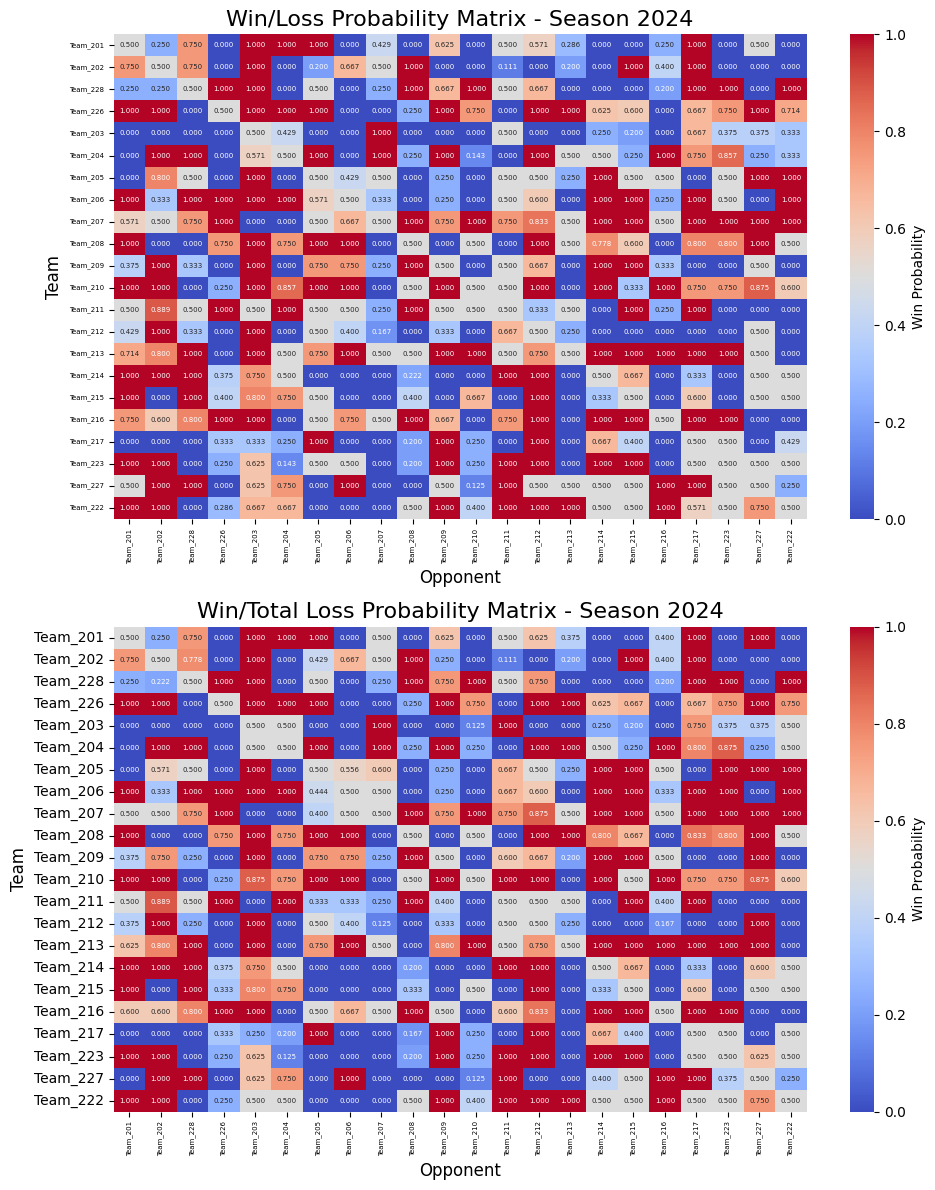

In [ ]:
season = 2024
plot_matrices(win_loss_matrix, win_total_loss_matrix, teams, season)

### 2.3.1: Generating All Head-to-Head Probability Matrices

In [ ]:
def calculate_all_season_matrices_n(head_to_head_dataframes, season_mapping):
    win_loss_matrices = []
    win_total_loss_matrices = []
    teams_list = []

    # Iterate over each season in the mapping
    for season_id in season_mapping:
        # Calculate the win-loss and win-total-loss matrices for the given season
        win_loss_matrix, win_total_loss_matrix, teams = calculate_probability_matrices(head_to_head_dataframes, season_id)

        win_loss_matrices.append(win_loss_matrix)
        win_total_loss_matrices.append(win_total_loss_matrix)
        teams_list.append(teams)

    # Convert the lists to 3D numpy arrays for easier indexing
    win_loss_3d = np.array(win_loss_matrices)
    win_total_loss_3d = np.array(win_total_loss_matrices)

    return win_loss_3d, win_total_loss_3d, teams_list

## 2.4: Introducing Randomness (for teams with 2 or fewer head-to-head-games that season)

First, a quick helper function that stabilizes the probabilities and corrects matchups that are too heavily weighted due to low sample size.

In [ ]:
def reweight_probabilities_to_range(win_loss_matrix, range_min=0.3, range_max=0.7):
    flattened = win_loss_matrix[np.triu_indices_from(win_loss_matrix, k=1)]

    # Normalize the values to the range [range_min, range_max]
    normalized = range_min + (flattened - flattened.min()) / (flattened.max() - flattened.min()) * (range_max - range_min)

    # Map the normalized values back into the matrix while keeping sum-to-1 constraint
    reweighted_matrix = np.zeros_like(win_loss_matrix)
    upper_triangle_indices = np.triu_indices_from(win_loss_matrix, k=1)
    reweighted_matrix[upper_triangle_indices] = normalized
    reweighted_matrix[(upper_triangle_indices[1], upper_triangle_indices[0])] = 1 - normalized

    return reweighted_matrix

In [ ]:
def calculate_probability_matrices_with_delta(head_to_head_dataframes, season_id, delta_factor=0.1, randomize=True):
    win_loss_matrix, win_total_loss_matrix, teams = calculate_probability_matrices(head_to_head_dataframes, season_id)

    team_record = {}
    for team_key, df in head_to_head_dataframes.items():
        df_season = df[df['Season_ID'] == season_id]
        total_wins = df_season['Wins'].sum()
        total_losses = df_season['Losses'].sum()
        ot_losses = df_season['OT_Losses'].sum()
        so_losses = df_season['SO_Loss'].sum()
        total_games = total_wins + total_losses + ot_losses + so_losses
        win_ratio = total_wins / total_games if total_games > 0 else 0.5
        team_record[team_key] = win_ratio

    # Adjust probabilities with delta and controlled randomness
    num_teams = len(teams)
    team_index = {teams[i]: i for i in range(num_teams)}

    for team_key, team_idx in team_index.items():
        df_season = head_to_head_dataframes[team_key][head_to_head_dataframes[team_key]['Season_ID'] == season_id]

        for _, row in df_season.iterrows():
            opponent_key = row['Opponent_ID']
            opponent_idx = team_index[opponent_key]

            # Count the number of games played between the team and the opponent
            games_played = row['Wins'] + row['Losses'] + row['OT_Losses'] + row['SO_Loss']

            # Calculate controlled randomness scale with reduced scale for fewer games
            randomness_scale = 0.5 / (np.sqrt(games_played + 1))

            p_team = win_loss_matrix[team_idx, opponent_idx]
            p_opponent = win_loss_matrix[opponent_idx, team_idx]

            delta_team = delta_factor * (1 - team_record[team_key]) if p_team == 1 else delta_factor * team_record[team_key]
            delta_opponent = delta_factor * (1 - team_record[opponent_key]) if p_opponent == 1 else delta_factor * team_record[opponent_key]

            # Apply a damping factor to reduce the influence of direct matchups
            direct_matchup_damping = 0.5
            delta_team *= direct_matchup_damping
            delta_opponent *= direct_matchup_damping

            if randomize:
                # Apply randomness differently if the probability is already extreme (> 0.8)
                if p_team > 0.8:
                    random_adjustment = np.random.uniform(0, 1) * randomness_scale
                    delta_team = -random_adjustment * p_team
                    delta_opponent = random_adjustment * (1 - p_opponent)
                elif p_opponent > 0.8:
                    random_adjustment = np.random.uniform(0, 1) * randomness_scale
                    delta_opponent = -random_adjustment * p_opponent
                    delta_team = random_adjustment * (1 - p_team)
                else:
                    random_adjustment = np.random.uniform(-1, 1) * randomness_scale
                    delta_team = delta_team * (1 + random_adjustment)
                    delta_opponent = -delta_team

            p_team_new = np.clip(p_team + delta_team, 0.01, 0.99)
            p_opponent_new = 1 - p_team_new

            win_loss_matrix[team_idx, opponent_idx] = p_team_new
            win_loss_matrix[opponent_idx, team_idx] = p_opponent_new

            # Adjust win_total_loss_matrix (using the same logic for sum-to-1 enforcement)
            p_total_team = win_total_loss_matrix[team_idx, opponent_idx]
            p_total_opponent = win_total_loss_matrix[opponent_idx, team_idx]

            delta_total_team = delta_factor * (1 - team_record[team_key]) if p_total_team == 1 else delta_factor * team_record[team_key]
            delta_total_opponent = delta_factor * (1 - team_record[opponent_key]) if p_total_opponent == 1 else delta_factor * team_record[opponent_key]

            delta_total_team *= direct_matchup_damping
            delta_total_opponent *= direct_matchup_damping

            if randomize:
                if p_total_team > 0.8:
                    random_adjustment_total = np.random.uniform(0, 1) * randomness_scale
                    delta_total_team = -random_adjustment_total * p_total_team
                    delta_total_opponent = random_adjustment_total * (1 - p_total_opponent)
                elif p_total_opponent > 0.8:
                    random_adjustment_total = np.random.uniform(0, 1) * randomness_scale
                    delta_total_opponent = -random_adjustment_total * p_total_opponent
                    delta_total_team = random_adjustment_total * (1 - p_total_team)
                else:
                    random_adjustment_total = np.random.uniform(-1, 1) * randomness_scale
                    delta_total_team = delta_total_team * (1 + random_adjustment_total)
                    delta_total_opponent = -delta_total_team

            p_total_team_new = np.clip(p_total_team + delta_total_team, 0.01, 0.99)
            p_total_opponent_new = 1 - p_total_team_new

            win_total_loss_matrix[team_idx, opponent_idx] = p_total_team_new
            win_total_loss_matrix[opponent_idx, team_idx] = p_total_opponent_new

    # Reweight probabilities to [0.25, 0.75] range evenly
    win_loss_matrix = reweight_probabilities_to_range(win_loss_matrix, range_min=0.25, range_max=0.75)
    win_total_loss_matrix = reweight_probabilities_to_range(win_total_loss_matrix, range_min=0.25, range_max=0.75)

    # Ensure diagonal values (team vs. itself) are set to 0.5
    np.fill_diagonal(win_loss_matrix, 0.5)
    np.fill_diagonal(win_total_loss_matrix, 0.5)

    return win_loss_matrix, win_total_loss_matrix, teams

In [ ]:
win_loss_3d, win_total_loss_3d, teams_list = calculate_all_season_matrices_n(head_to_head_dataframes, season_mapping)

print("Win-Loss 3D Matrix:", win_loss_3d.shape)
print("Win-Total Loss 3D Matrix:", win_total_loss_3d.shape)

Win-Loss 3D Matrix: (10, 22, 22)
Win-Total Loss 3D Matrix: (10, 22, 22)


## 2.5: Generating All (Slightly Randomized) Head-to-Head Probability Matrices

In [ ]:
def calculate_matrices_for_all_seasons_r(head_to_head_dataframes, season_mapping, delta_factor=0.2, randomize=True):
    # Initialize lists to hold the matrices for all seasons
    win_loss_matrices = []
    win_total_loss_matrices = []
    teams_list = None

    # Iterate over each season in the mapping
    for season_id in season_mapping:
        # Calculate the win-loss and win-total-loss matrices with delta adjustments for the season
        win_loss_matrix, win_total_loss_matrix, teams = calculate_probability_matrices_with_delta(
            head_to_head_dataframes, season_id, delta_factor=delta_factor, randomize=randomize
        )

        win_loss_matrices.append(win_loss_matrix)
        win_total_loss_matrices.append(win_total_loss_matrix)

        if teams_list is None:
            teams_list = teams

    # Convert the lists to 3D numpy arrays for easier indexing
    win_loss_3d = np.array(win_loss_matrices)
    win_total_loss_3d = np.array(win_total_loss_matrices)

    return win_loss_3d, win_total_loss_3d, teams_list


win_loss_3d, win_total_loss_3d, teams = calculate_matrices_for_all_seasons_r(head_to_head_dataframes, season_mapping, delta_factor=0.2, randomize=True)

print("Win-Loss Matrix Shape:", win_loss_3d.shape)
print("Win-Total Loss Matrix Shape:", win_total_loss_3d.shape)

Win-Loss Matrix Shape: (10, 22, 22)
Win-Total Loss Matrix Shape: (10, 22, 22)


# 2.6: Generate Full Head-to-Head Record Heatmaps for P Matrices with Randomness

[NO, the 2022 heatmap is not wrong...a lot of teams just didn't play each other because of COVID]

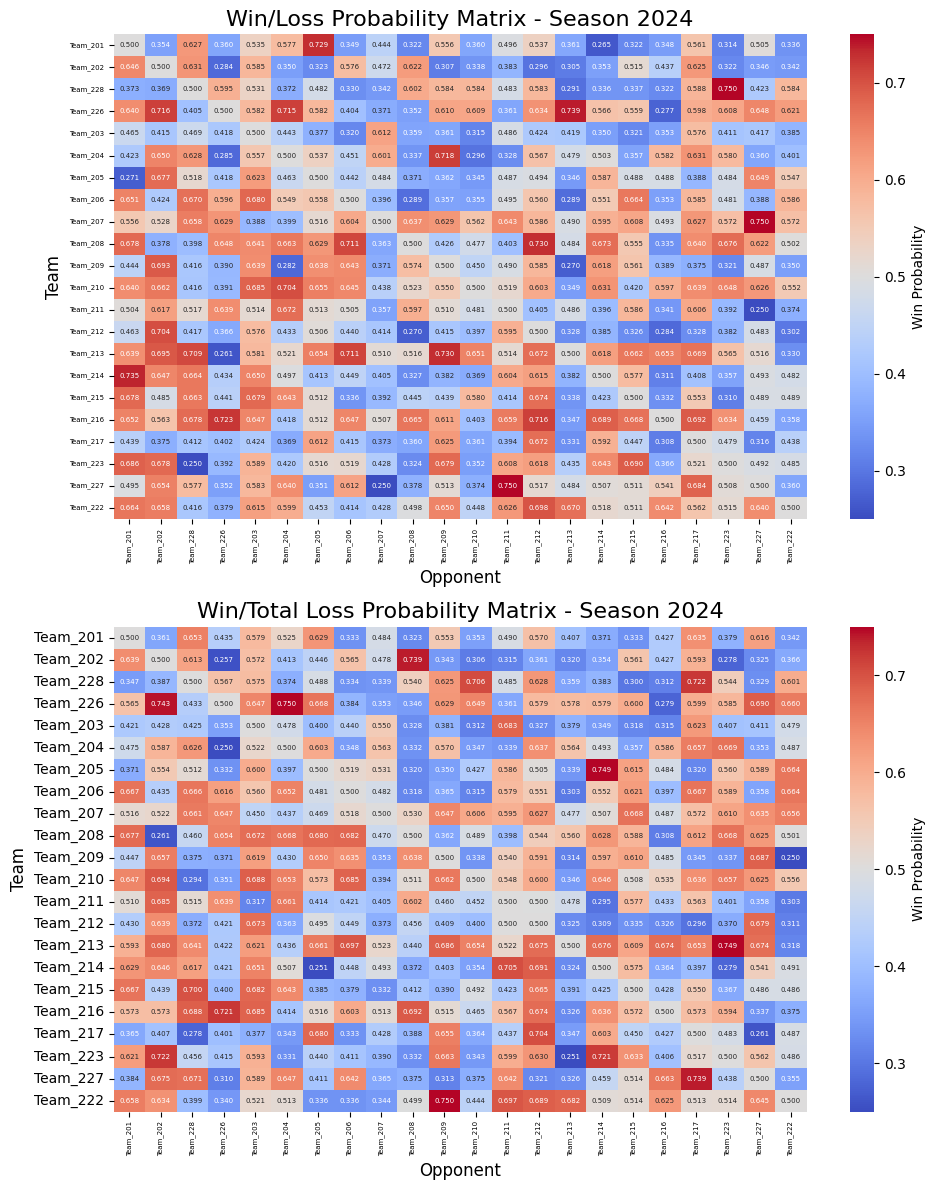

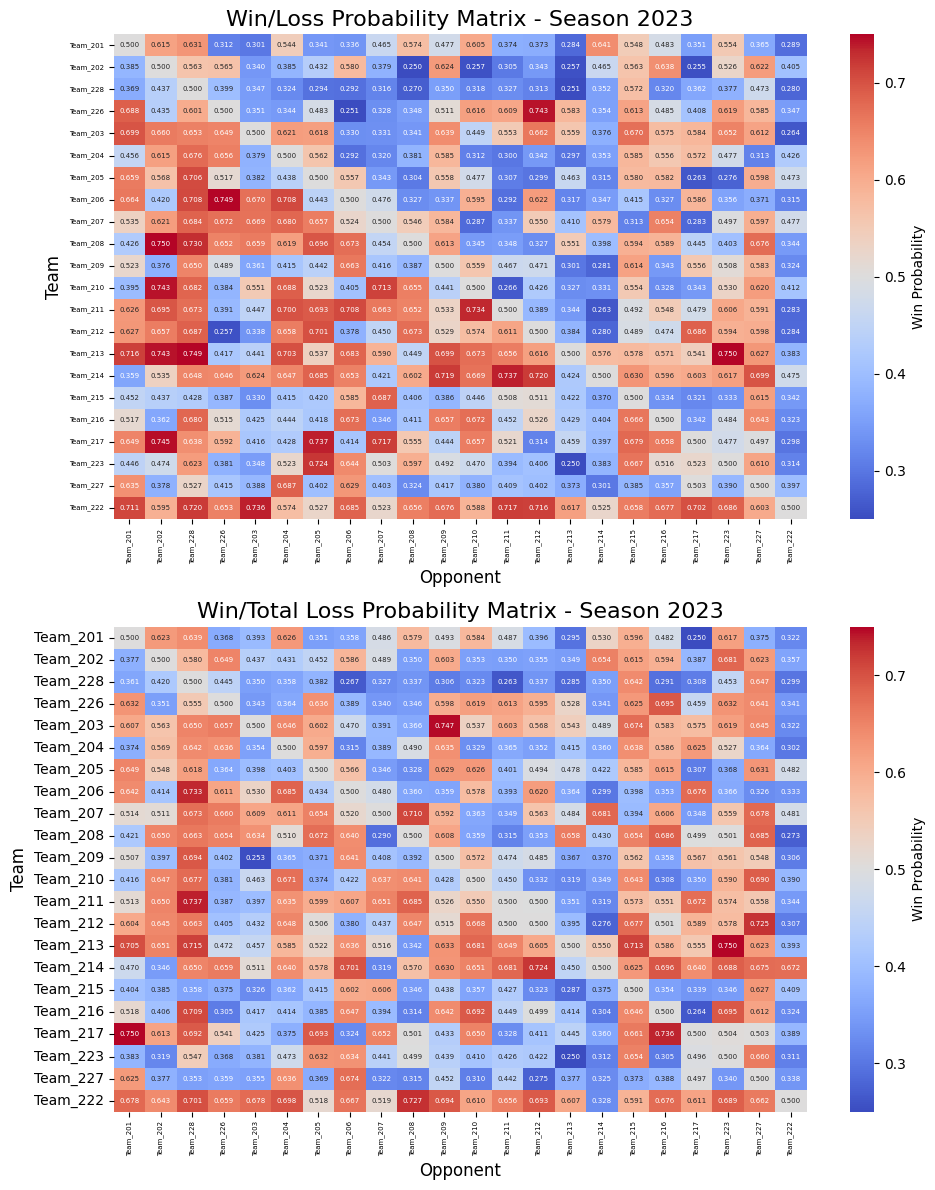

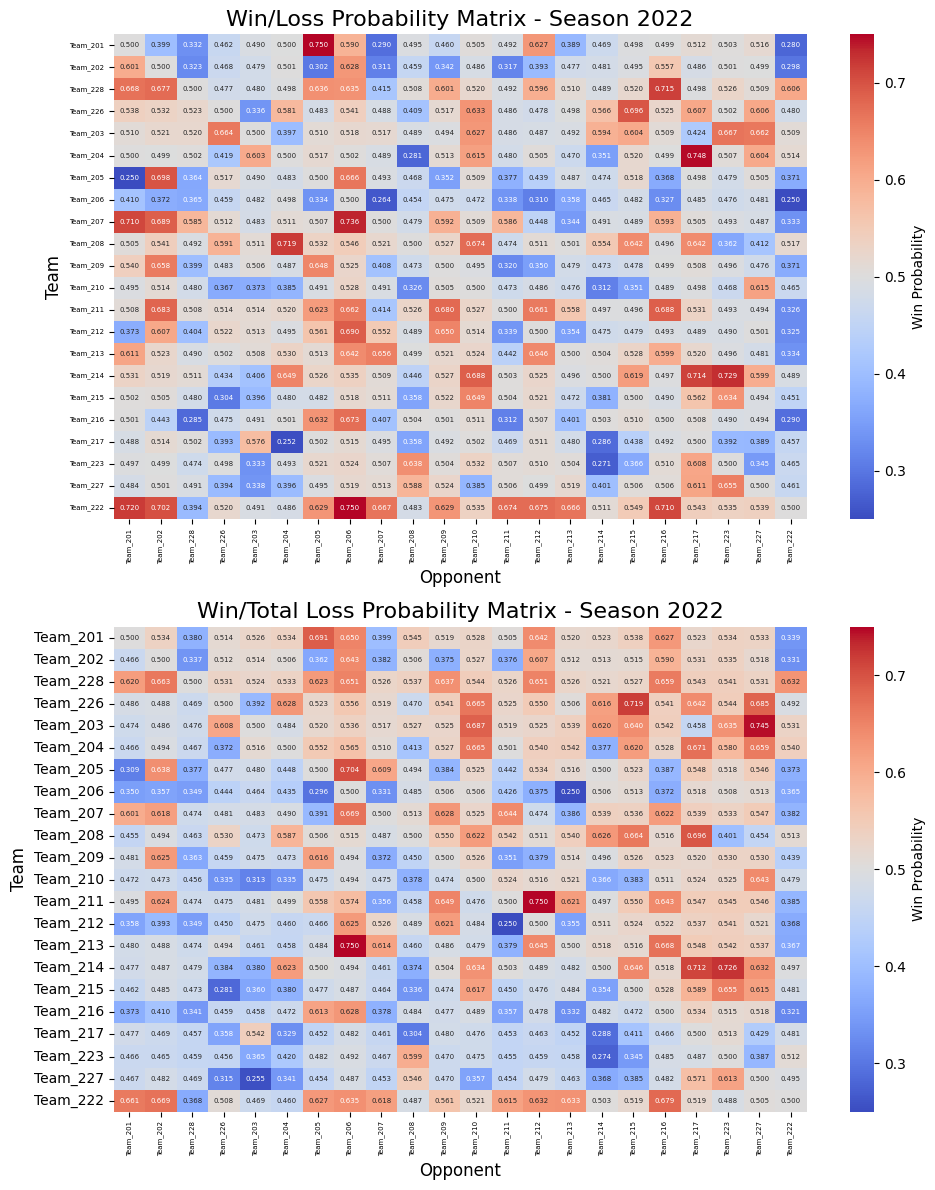

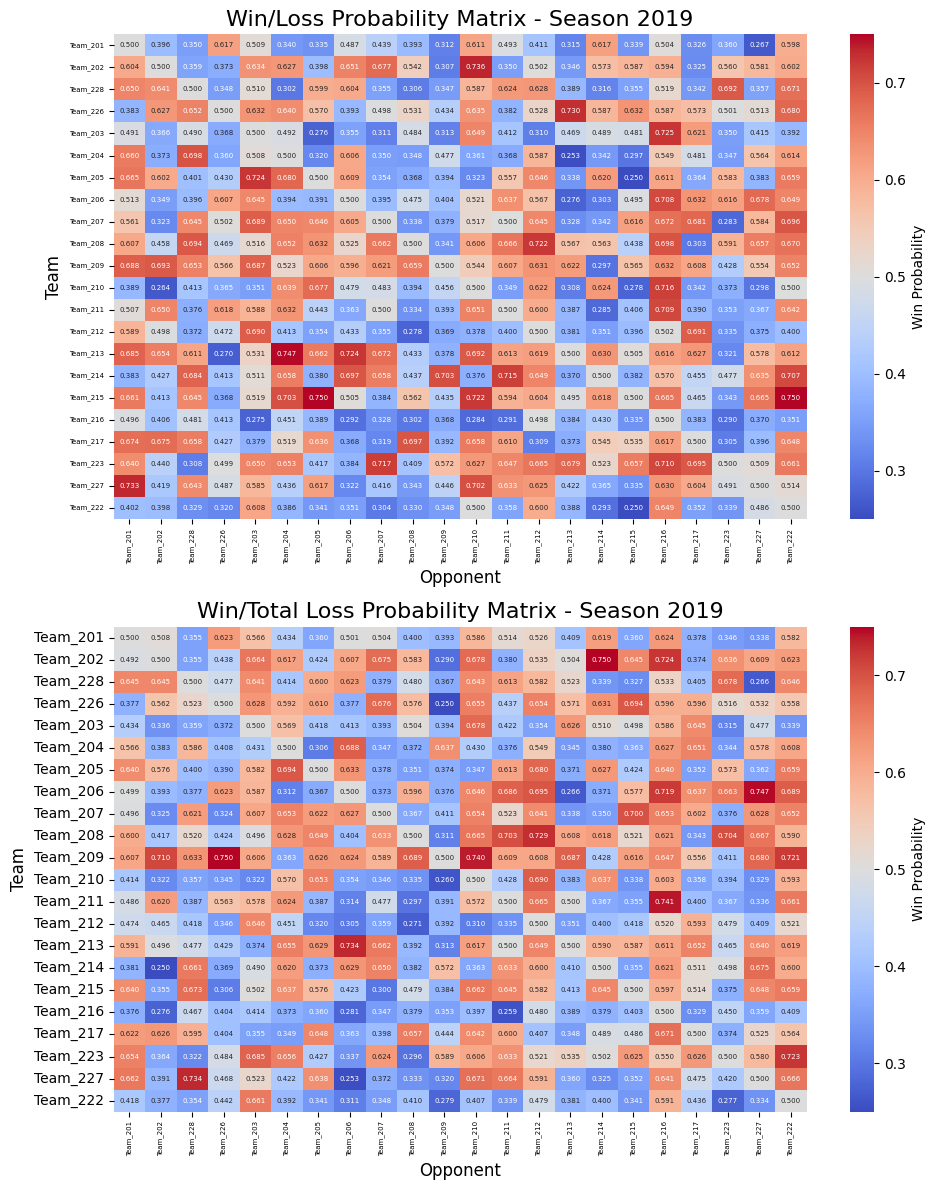

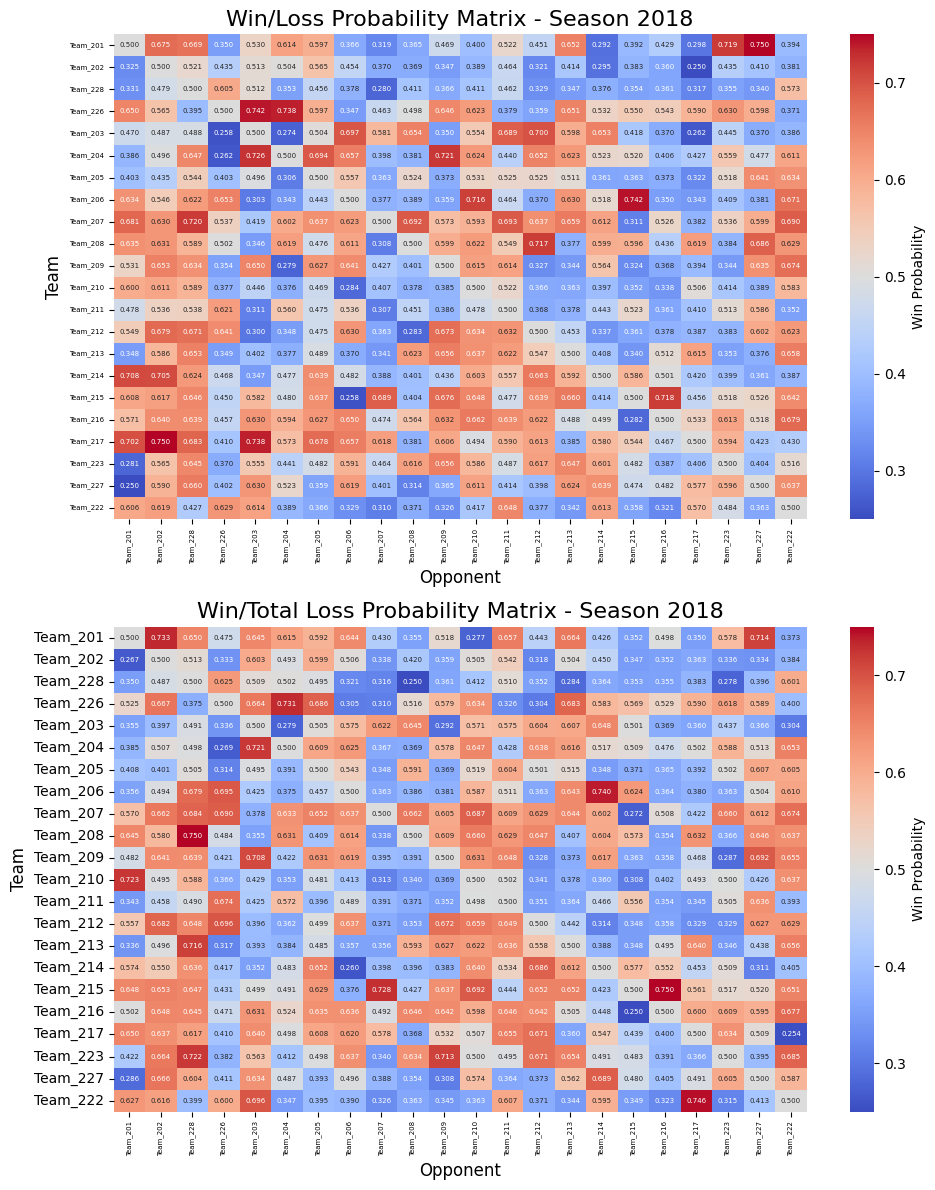

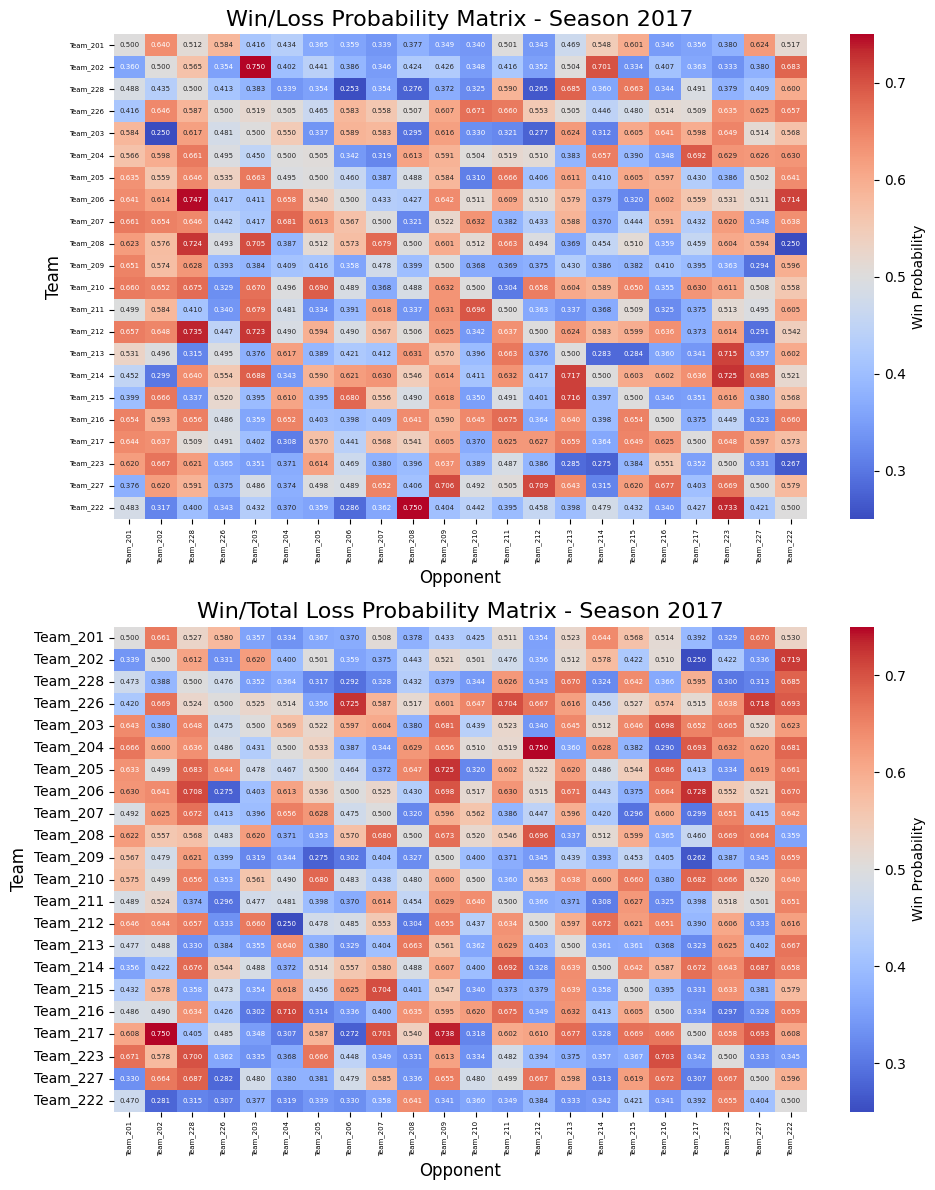

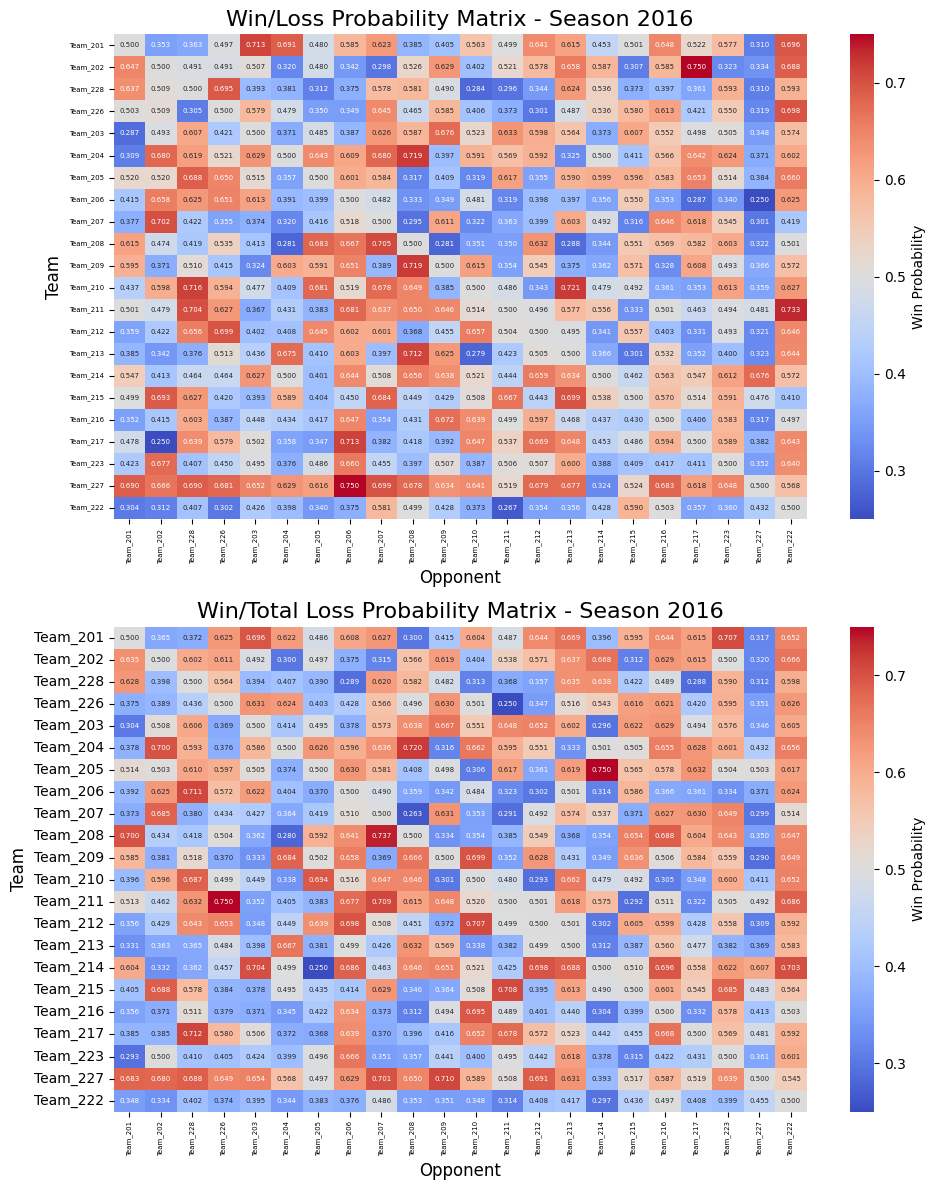

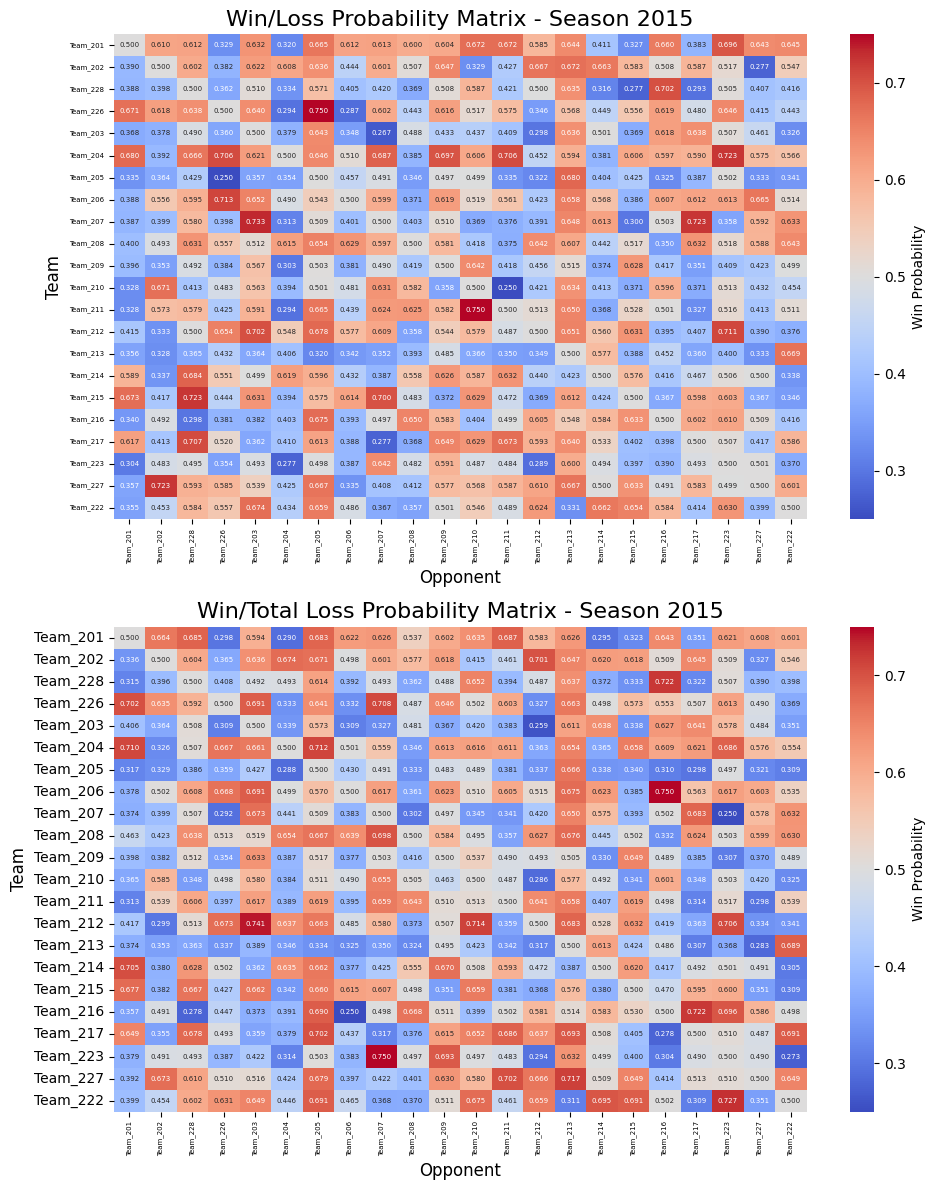

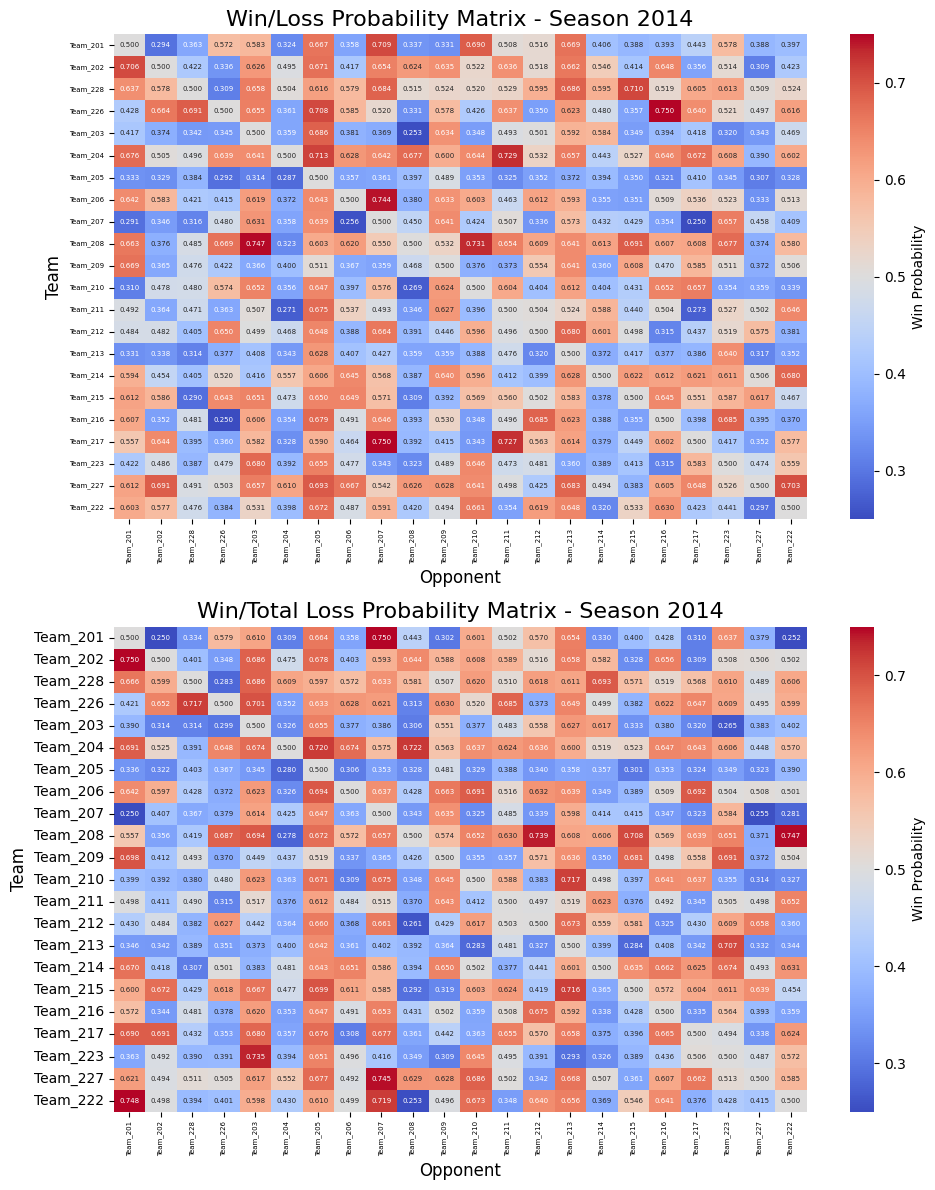

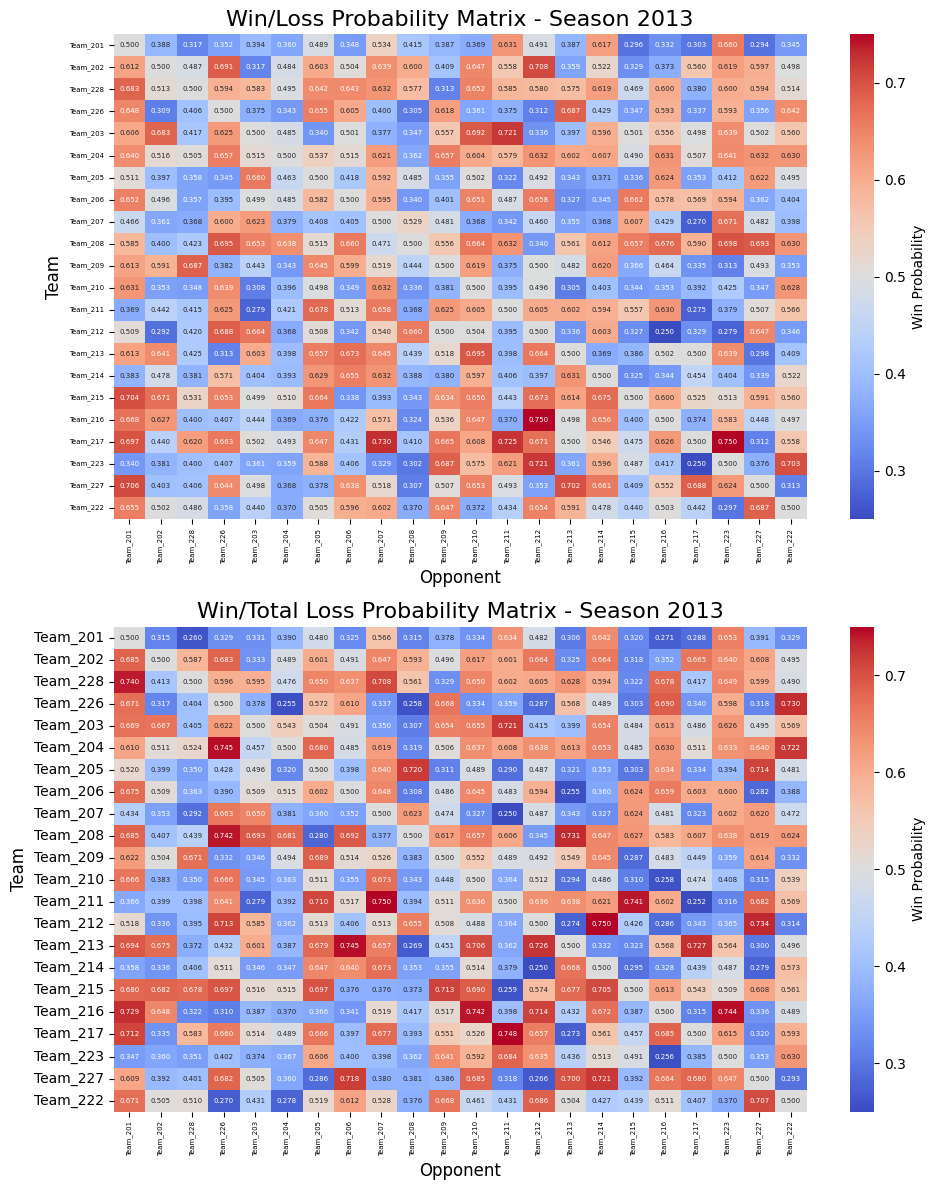

In [ ]:
for i, season_id in enumerate(season_mapping.keys()):
    season = season_mapping[season_id]
    plot_matrices(win_loss_3d[i], win_total_loss_3d[i], teams_list[i], season)

# Part 3: Running a Tournament Simulation for the Head-to-Head Probability Matrices

In [ ]:
win_loss_3d = win_loss_3d.copy()
win_total_loss_3d = win_total_loss_3d.copy()

## 3.1: Helpful Functions

In [ ]:
# Function to map team names to team IDs and their indices
def get_team_id_and_idx(team_name):
    return team_id_mapping.get(team_name, (None, None))

# Simulate a match between two teams based on their win-loss probability
def simulate_match(team_1, team_2, win_loss_matrix):
    team_1_idx, team_2_idx = get_team_id_and_idx(team_1)[1], get_team_id_and_idx(team_2)[1]

    win_prob = win_loss_matrix[team_1_idx, team_2_idx]
    return team_1 if random.random() < win_prob else team_2

# Simulate a best-of-7 series
def simulate_series(team_1, team_2, win_loss_matrix):
    team_1_wins = team_2_wins = 0
    while team_1_wins < 4 and team_2_wins < 4:
        winner = simulate_match(team_1, team_2, win_loss_matrix)
        team_1_wins += (winner == team_1)
        team_2_wins += (winner == team_2)
    return winner

# Run a single tournament and track round appearances
def run_tournament(year, draws, win_loss_matrix, round_tracker):
    tournament_teams = [team for match in draws['Eastern'] + draws['Western'] for team in match]
    round_number = 1

    while len(tournament_teams) > 1:
        next_round_teams = []
        for i in range(0, len(tournament_teams), 2):
            team_1 = tournament_teams[i]
            team_2 = tournament_teams[i + 1]
            winner = simulate_series(team_1, team_2, win_loss_matrix)
            next_round_teams.append(winner)

            # Tracks round appearance for both teams
            round_tracker[team_1][round_number] += 1
            round_tracker[team_2][round_number] += 1

        tournament_teams = next_round_teams
        round_number += 1

    # Tracks championship win for the final team
    winner = tournament_teams[0]
    round_tracker[winner][round_number] += 1

# Run multiple tournaments for a given year and track results
# The function that we are going to use in our simulations going forward,
# which calls the other functions above...
def run_multiple_tournaments(num_simulations, year, draws, win_loss_matrix):
    round_tracker = defaultdict(lambda: defaultdict(int))
    for _ in range(num_simulations):
        run_tournament(year, draws, win_loss_matrix, round_tracker)

    # Calculate probabilities for each team
    probabilities = {}
    for team, rounds in round_tracker.items():
        total_simulations = num_simulations
        probabilities[team] = {
            "Semifinals": rounds[3] / total_simulations if total_simulations > 0 else 0,
            "Conference Finals": rounds[4] / total_simulations if total_simulations > 0 else 0,
            "Championship": rounds[5] / total_simulations if total_simulations > 0 else 0,
        }
    return probabilities

## 3.2: Running the Simulation

In [ ]:
# Iterate over the seasons and run the tournaments
season_results = {}
for idx, (season_id, year) in enumerate(season_mapping.items()):
    year = int(year)
    draws_for_year = draws[year]
    win_loss_matrix = win_total_loss_3d[idx]

    print(f"Simulating for year {year}...")
    probabilities = run_multiple_tournaments(10000, year, draws_for_year, win_loss_matrix)
    season_results[year] = probabilities

# Access results for a specific year
print("Probabilities for 2024 season:")
for team, probs in season_results[2024].items():
    print(f"{team}: {probs}")

Simulating for year 2024...
Simulating for year 2023...
Simulating for year 2022...
Simulating for year 2019...
Simulating for year 2018...
Simulating for year 2017...
Simulating for year 2016...
Simulating for year 2015...
Simulating for year 2014...
Simulating for year 2013...
Probabilities for 2024 season:
Saskatoon: {'Semifinals': 0.0392, 'Conference Finals': 0.023, 'Championship': 0.011}
Prince Albert: {'Semifinals': 0.3429, 'Conference Finals': 0.1739, 'Championship': 0.0945}
Swift Current: {'Semifinals': 0.4783, 'Conference Finals': 0.2629, 'Championship': 0.0651}
Lethbridge: {'Semifinals': 0.1396, 'Conference Finals': 0.0497, 'Championship': 0.0108}
Moose Jaw: {'Semifinals': 0.0611, 'Conference Finals': 0.0464, 'Championship': 0.0166}
Brandon: {'Semifinals': 0.4333, 'Conference Finals': 0.1659, 'Championship': 0.0581}
Medicine Hat: {'Semifinals': 0.3344, 'Conference Finals': 0.1838, 'Championship': 0.0899}
Red Deer: {'Semifinals': 0.1712, 'Conference Finals': 0.0944, 'Champions

In [ ]:
# Winners and runners-up dictionaries
winners_dict = {
    2013: "Portland",
    2014: "Edmonton",
    2015: "Kelowna",
    2016: "Brandon",
    2017: "Seattle",
    2018: "Swift Current",
    2019: "Prince Albert",
    2022: "Edmonton",
    2023: "Seattle",
    2024: "Moose Jaw"
}

runners_up_dict = {
    2013: "Edmonton",
    2014: "Portland",
    2015: "Brandon",
    2016: "Seattle",
    2017: "Regina",
    2018: "Everett",
    2019: "Vancouver",
    2022: "Seattle",
    2023: "Winnipeg",
    2024: "Portland"
}

def plot_season_probabilities(season_results, year, winners_dict, runners_up_dict):
    probabilities = season_results[year]
    teams = list(probabilities.keys())
    rounds = ["Semifinals", "Conference Finals", "Championship"]

    # Get probabilities for each round
    round_probs = {round_name: [probabilities[team][round_name] for team in teams] for round_name in rounds}

    # Get the winner and runner-up for the year
    winner = winners_dict.get(year, None)
    runner_up = runners_up_dict.get(year, None)

    # Set up the plot
    fig, axs = plt.subplots(1, 3, figsize=(22, 10))
    fig.suptitle(f"Playoff Probabilities for {year} Season", fontsize=20)

    # Plot probabilities for each round
    for i, round_name in enumerate(rounds):
        colors = ["skyblue"] * len(teams)
        if winner in teams:
            colors[teams.index(winner)] = "gold"
        if runner_up in teams:
            colors[teams.index(runner_up)] = "silver"

        axs[i].barh(teams, round_probs[round_name], color=colors, edgecolor="black", height=0.4)
        axs[i].set_title(f"H2H {year} {round_name}", fontsize=16)
        axs[i].set_xlabel("Probability", fontsize=14)
        axs[i].set_xlim(0, 1)
        axs[i].invert_yaxis()
        axs[i].tick_params(axis='y', labelsize=12, pad=0)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color="gold", label="Winner"),
        plt.Rectangle((0, 0), 1, 1, color="silver", label="Runner-Up"),
        plt.Rectangle((0, 0), 1, 1, color="skyblue", label="Other Teams"),
    ]
    axs[-1].legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=12)

    plt.tight_layout(rect=[0, 0.05, 1, 0.75])
    plt.show()

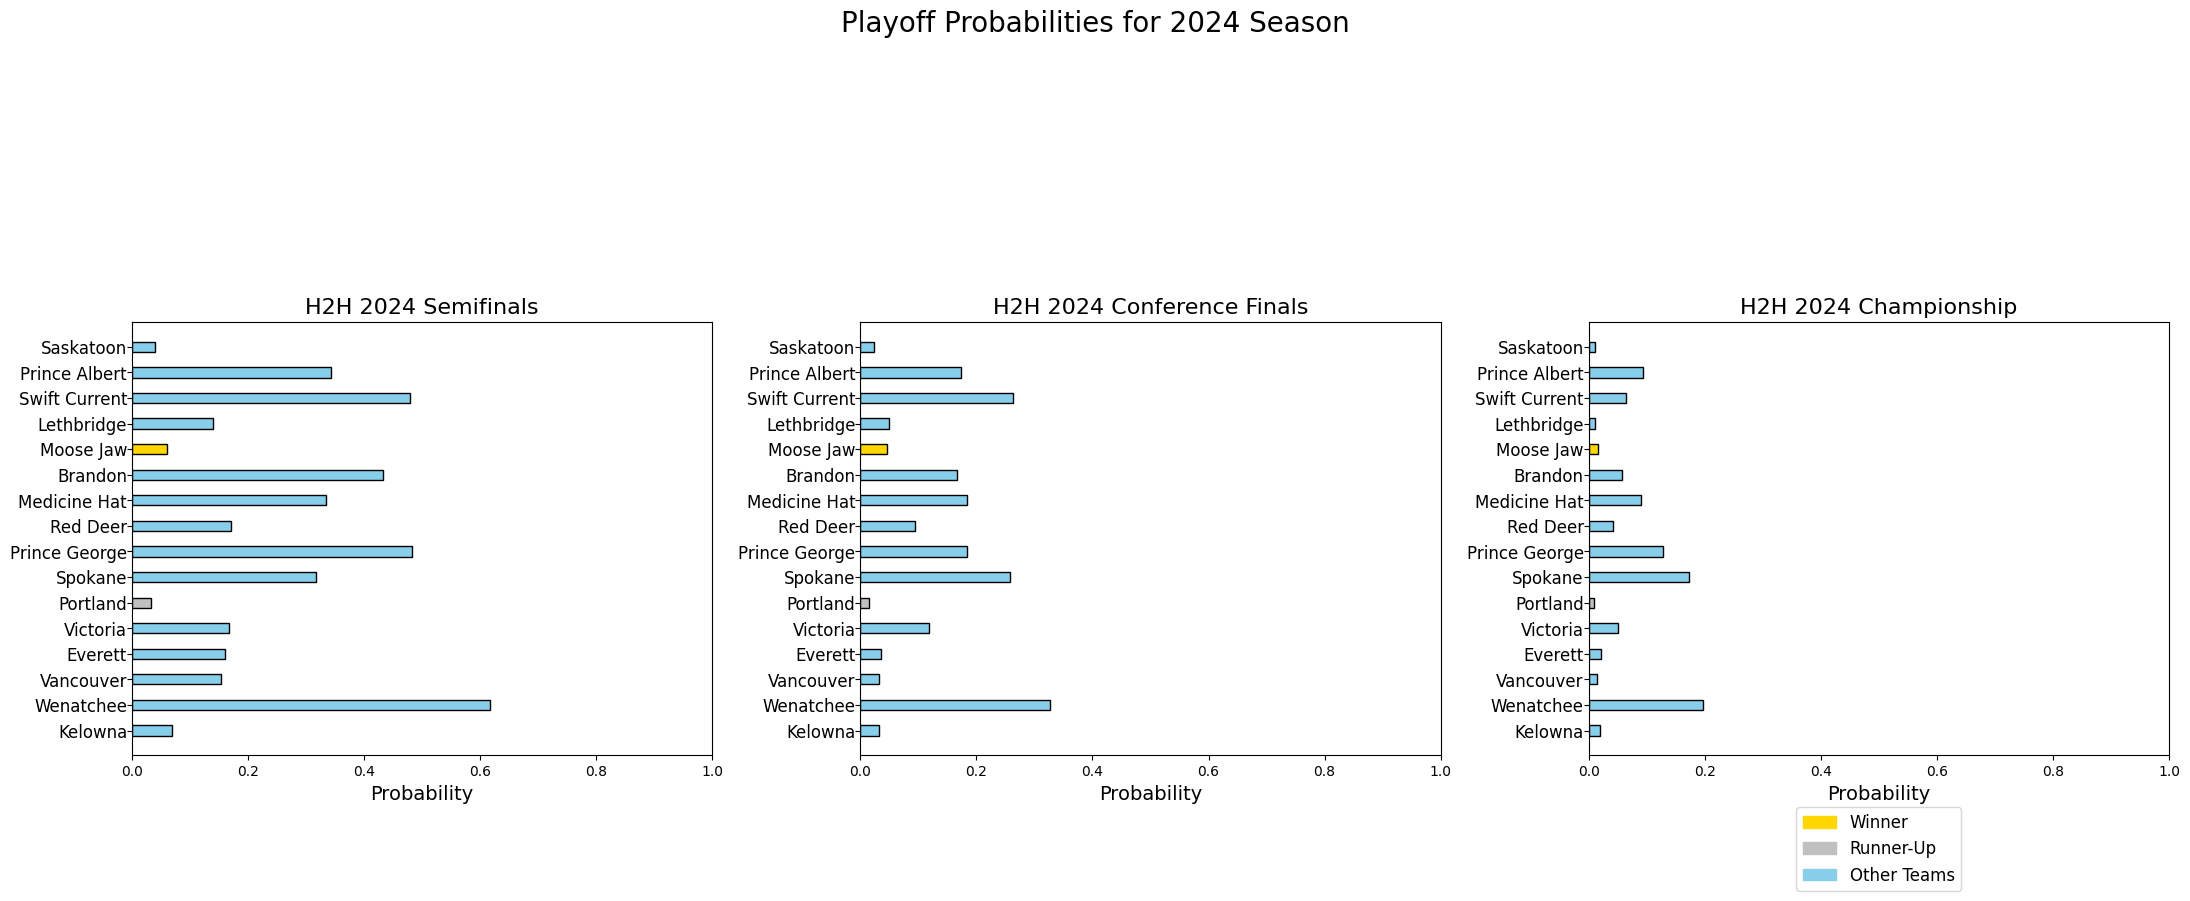

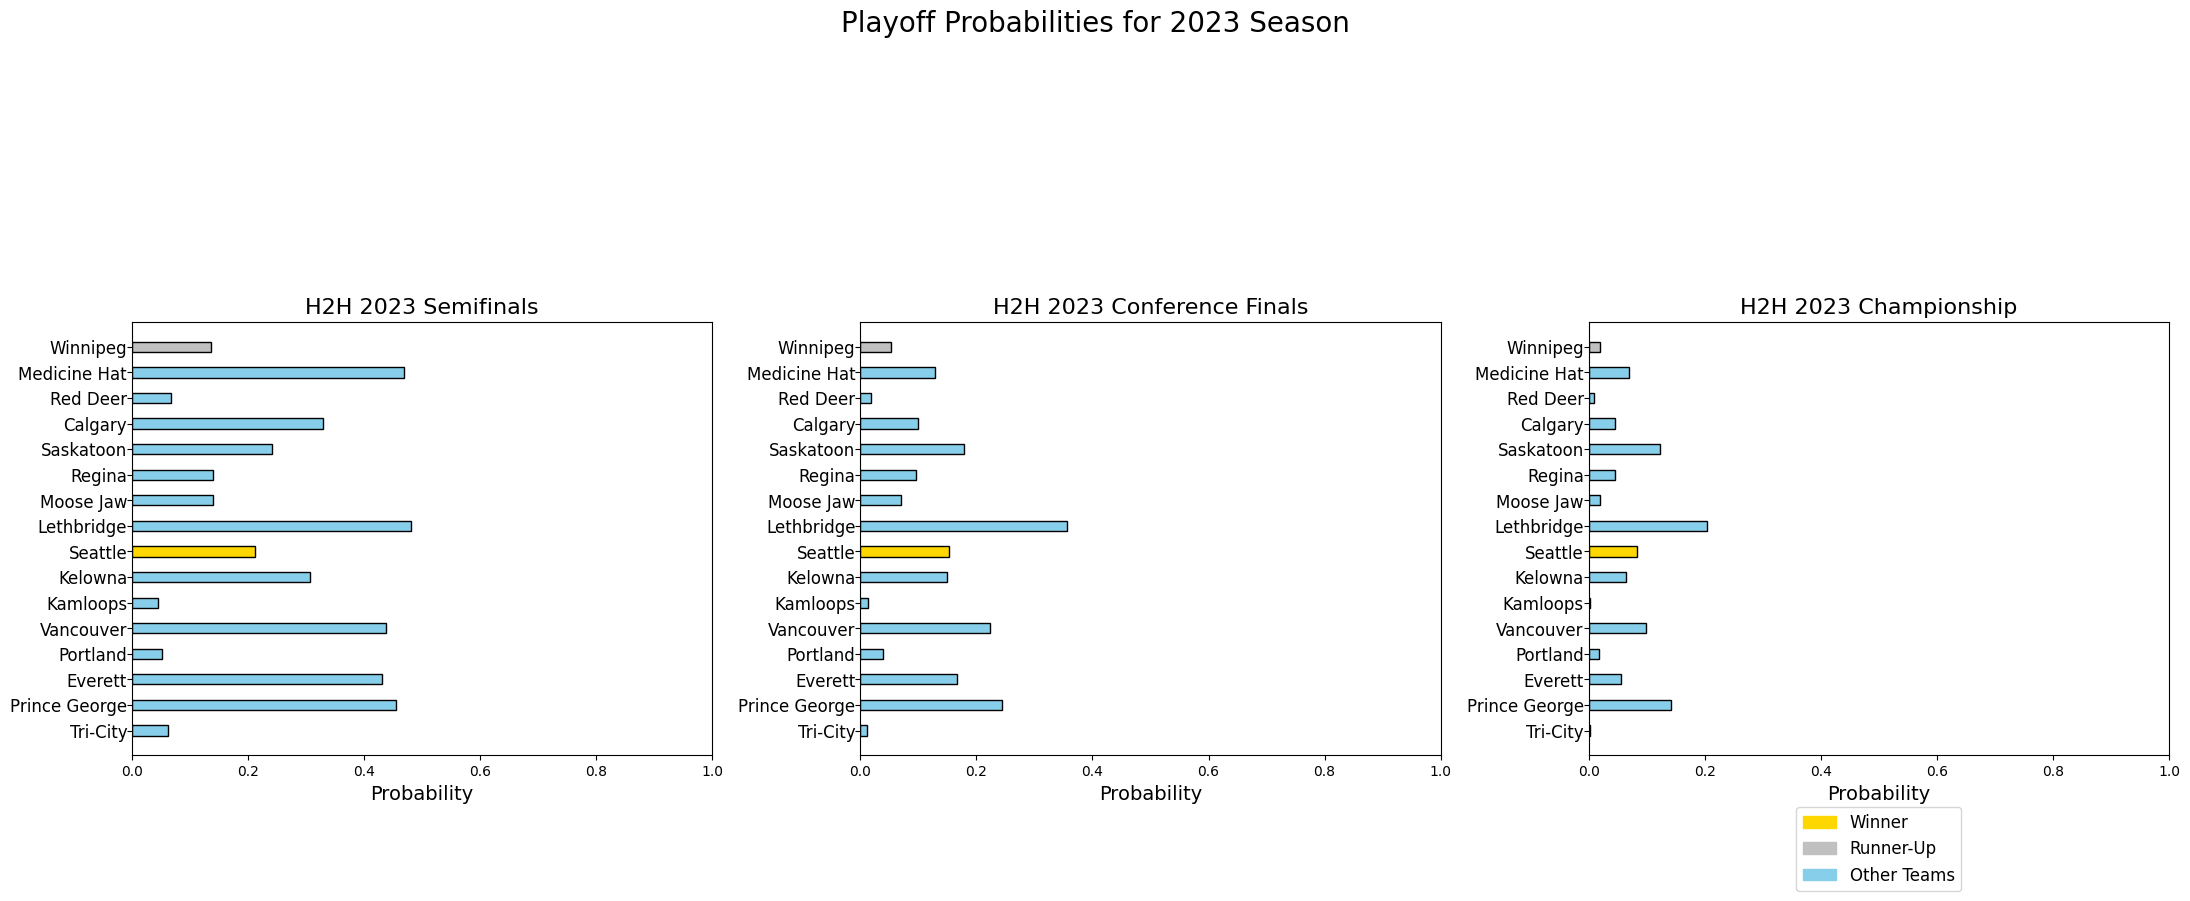

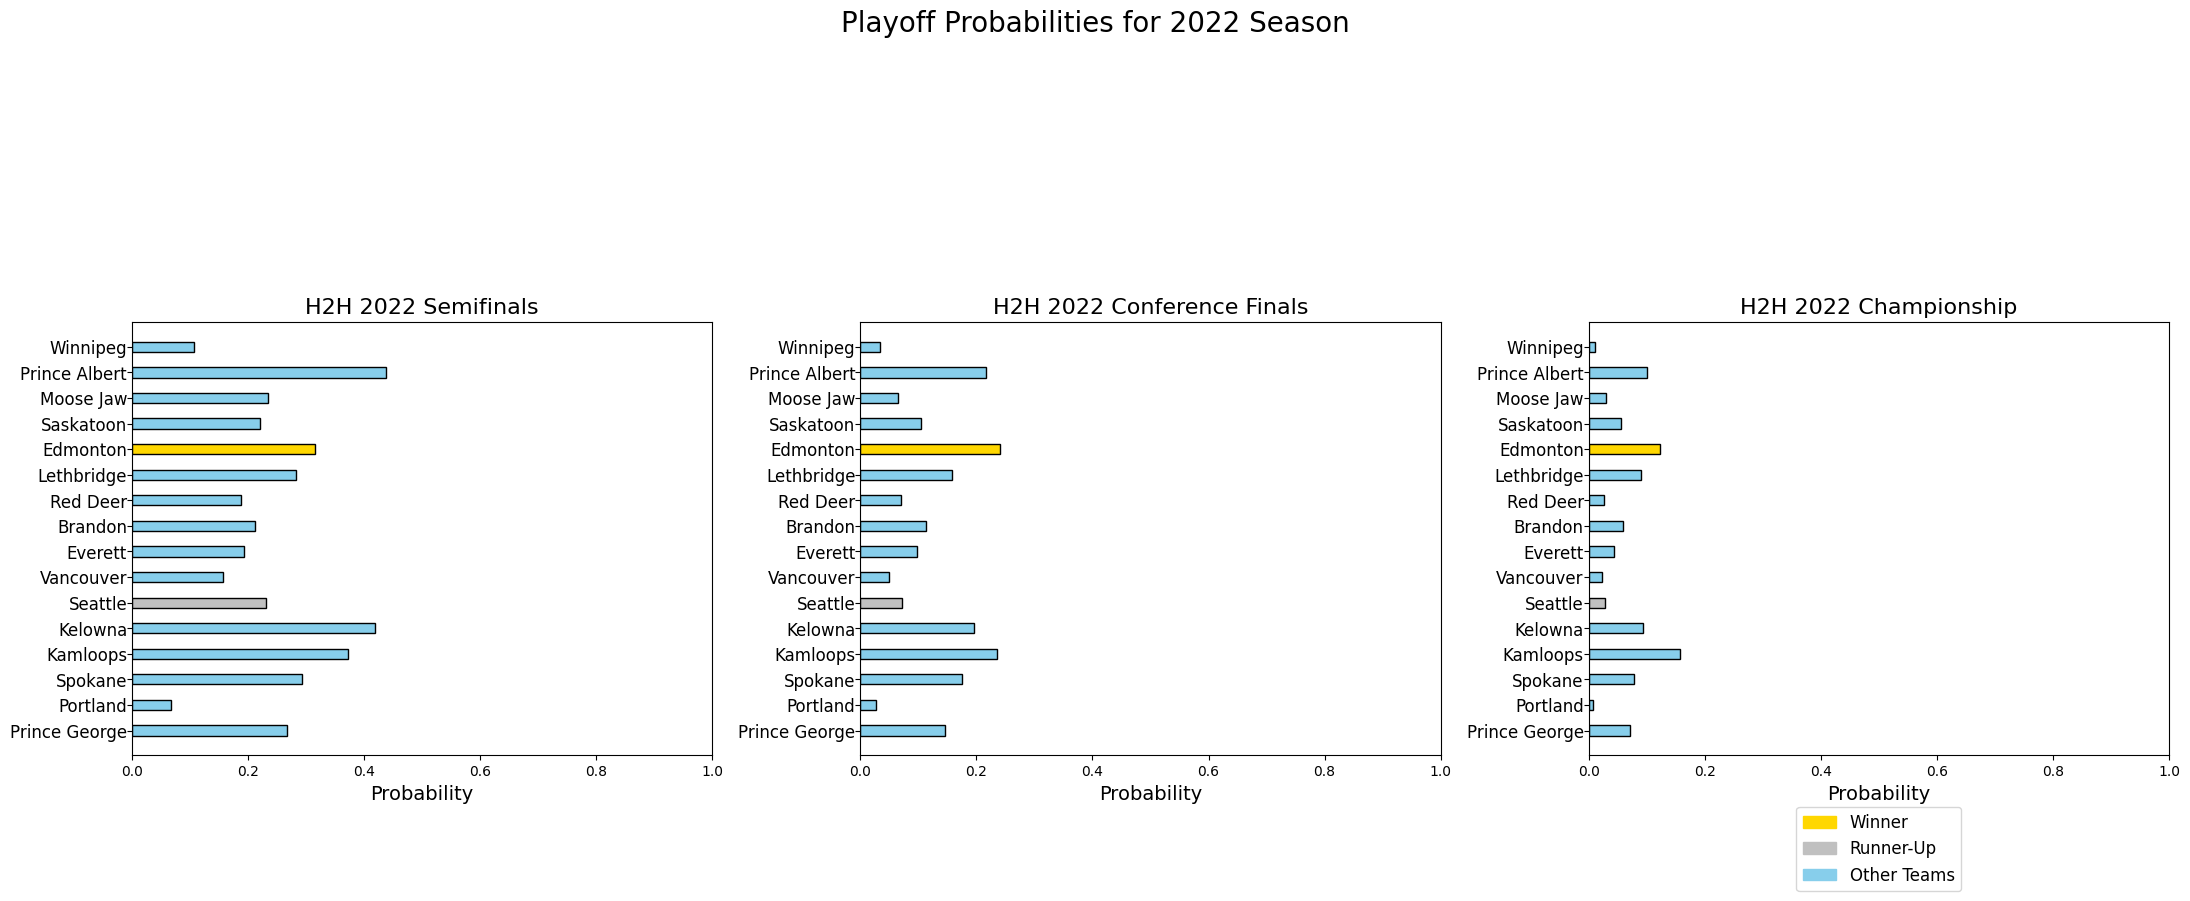

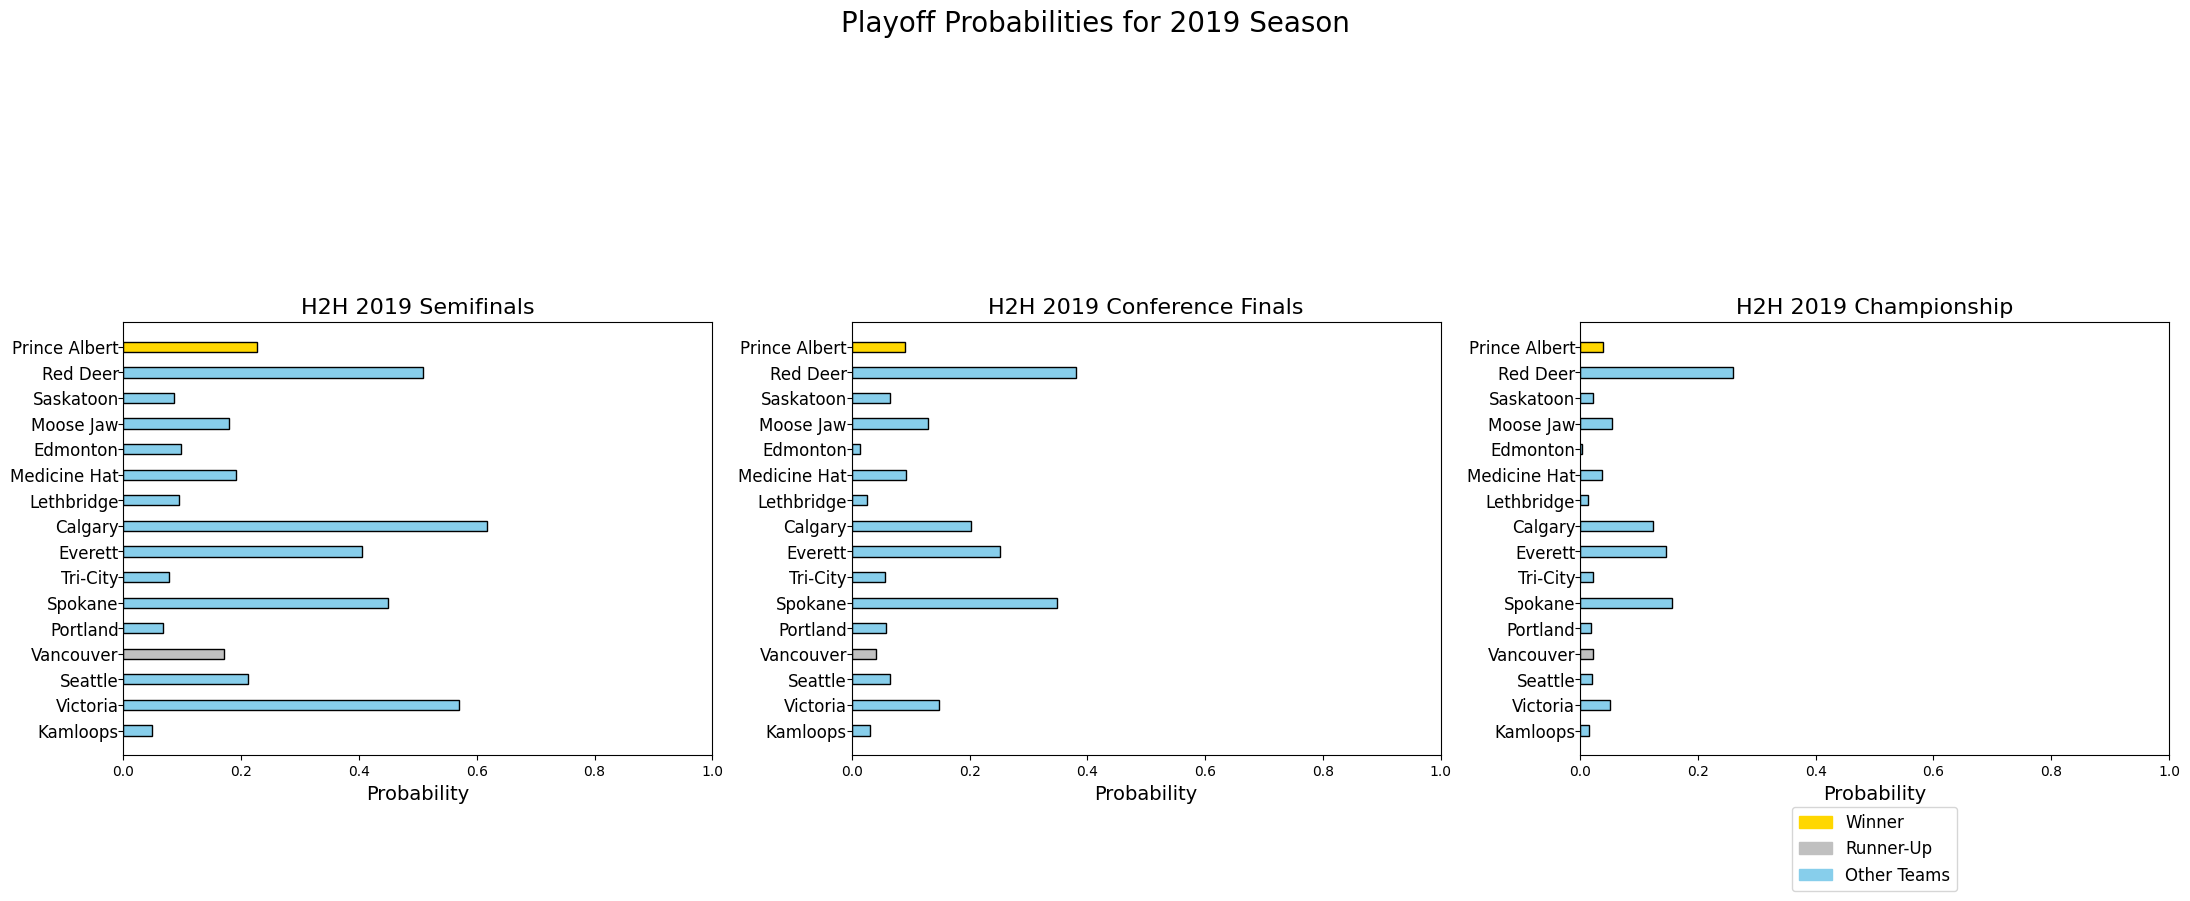

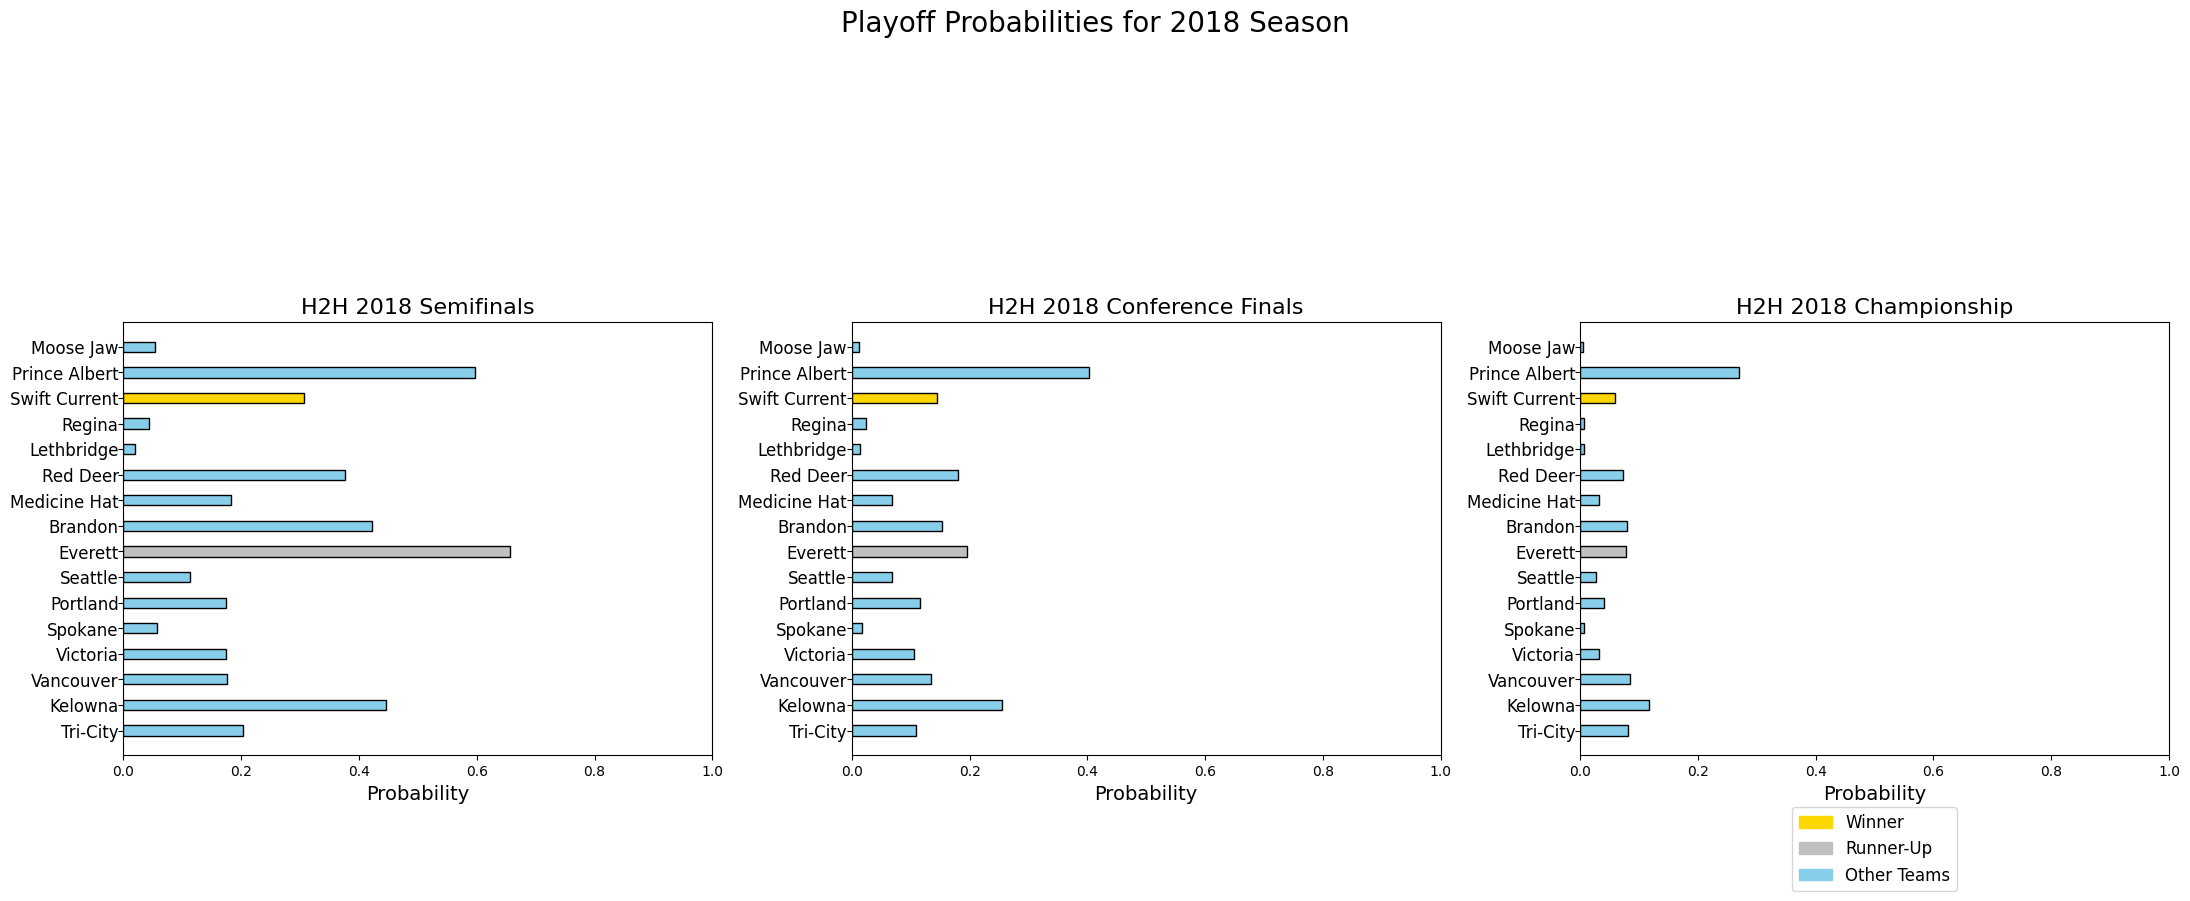

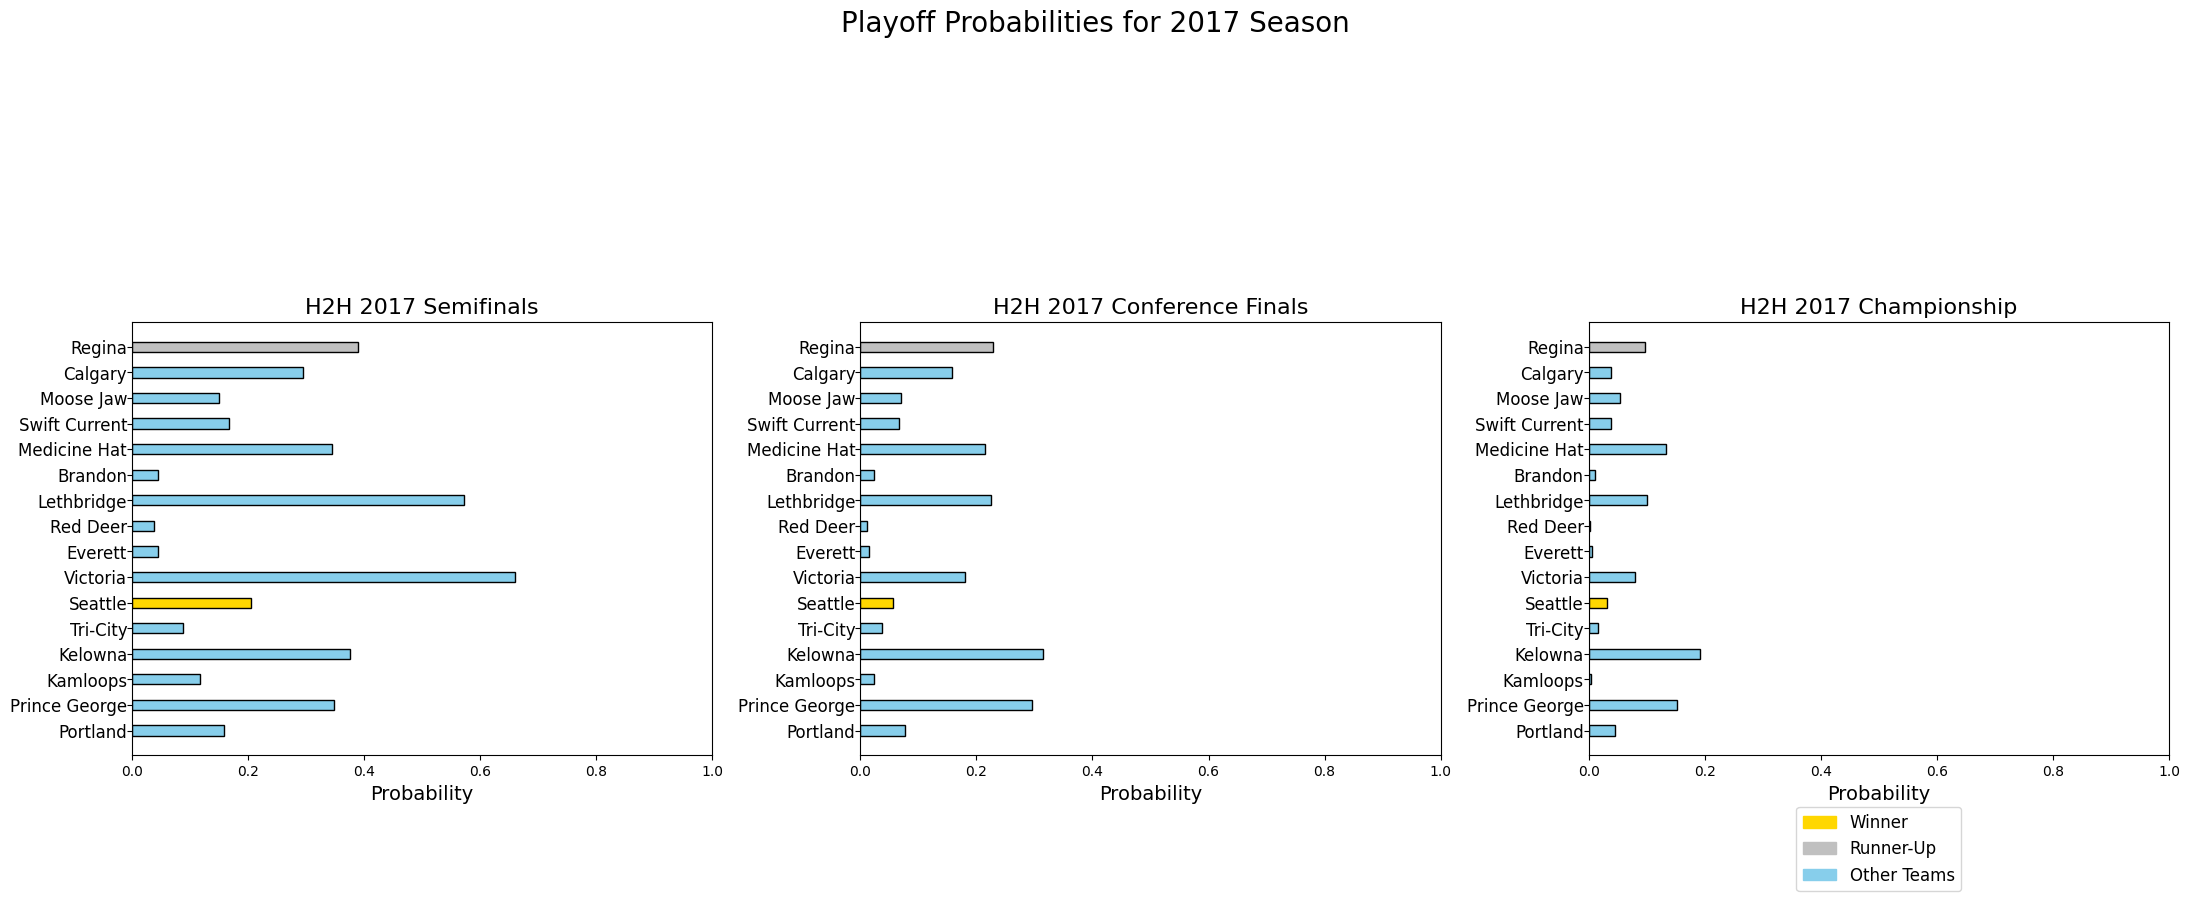

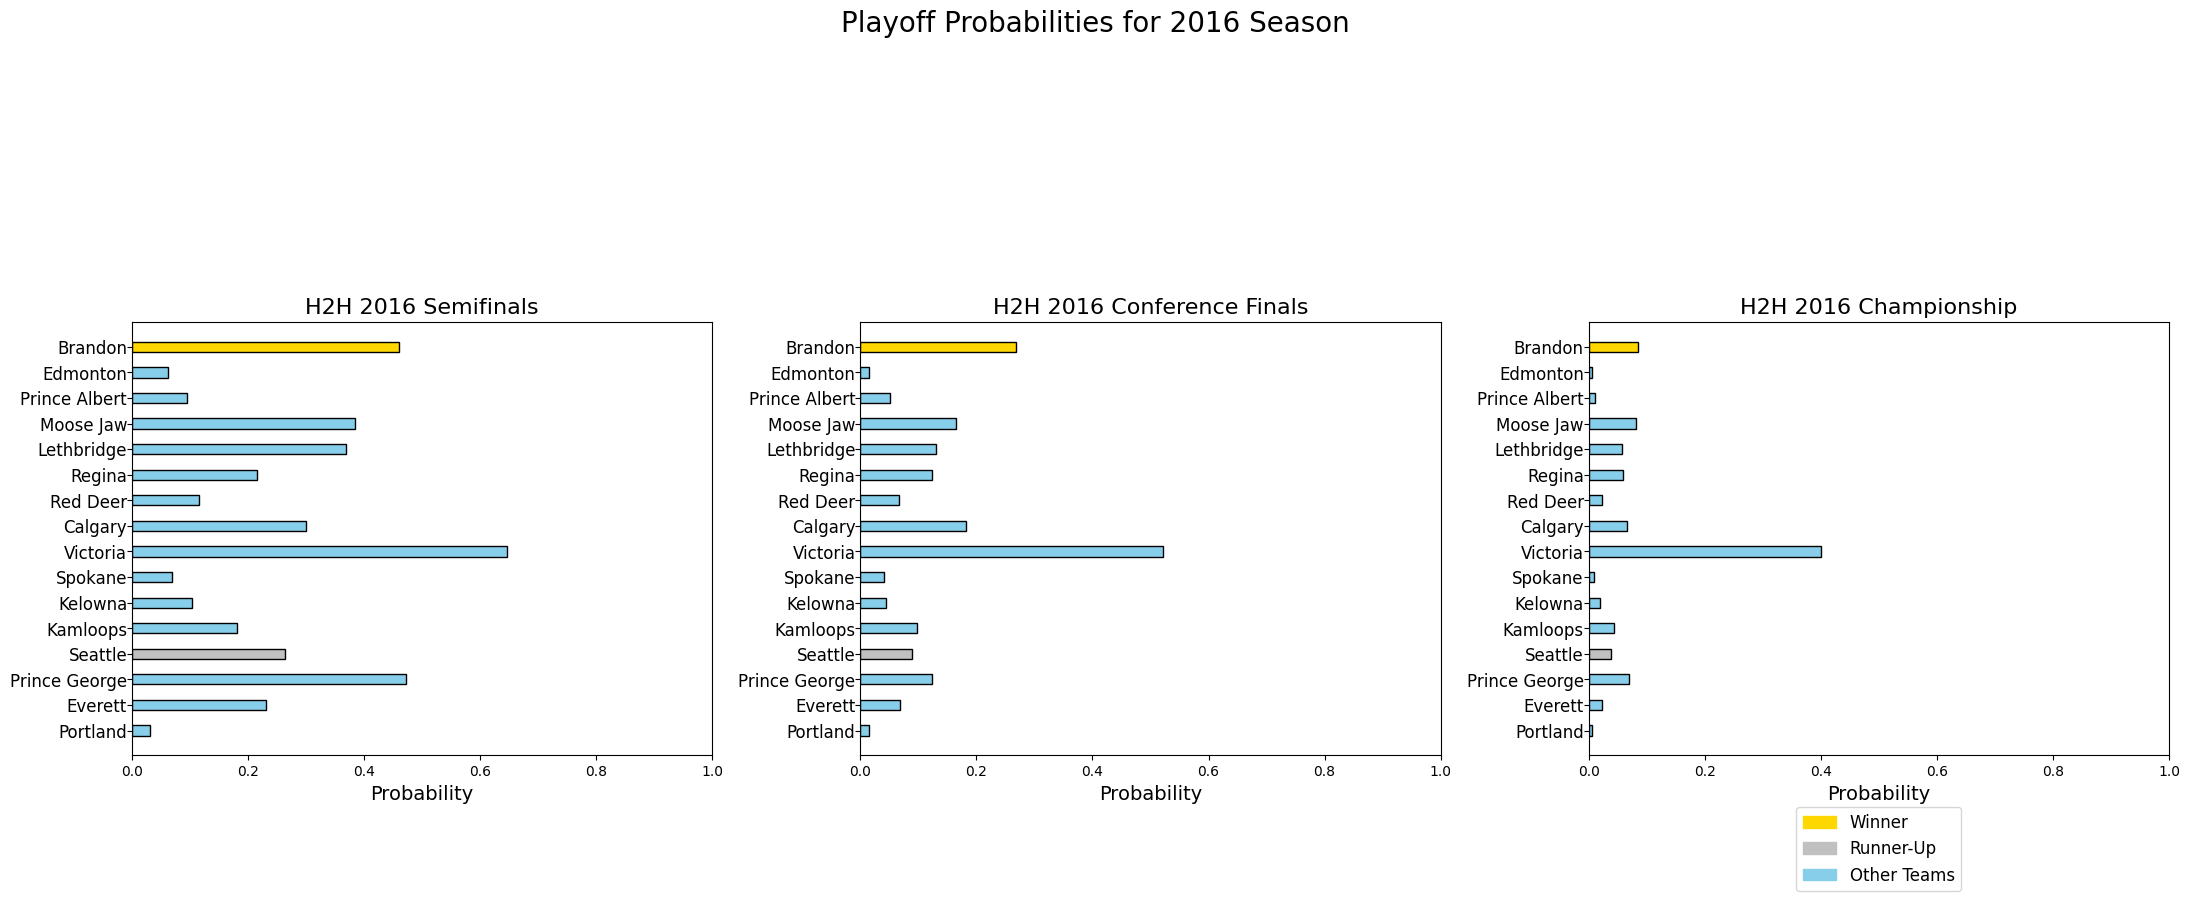

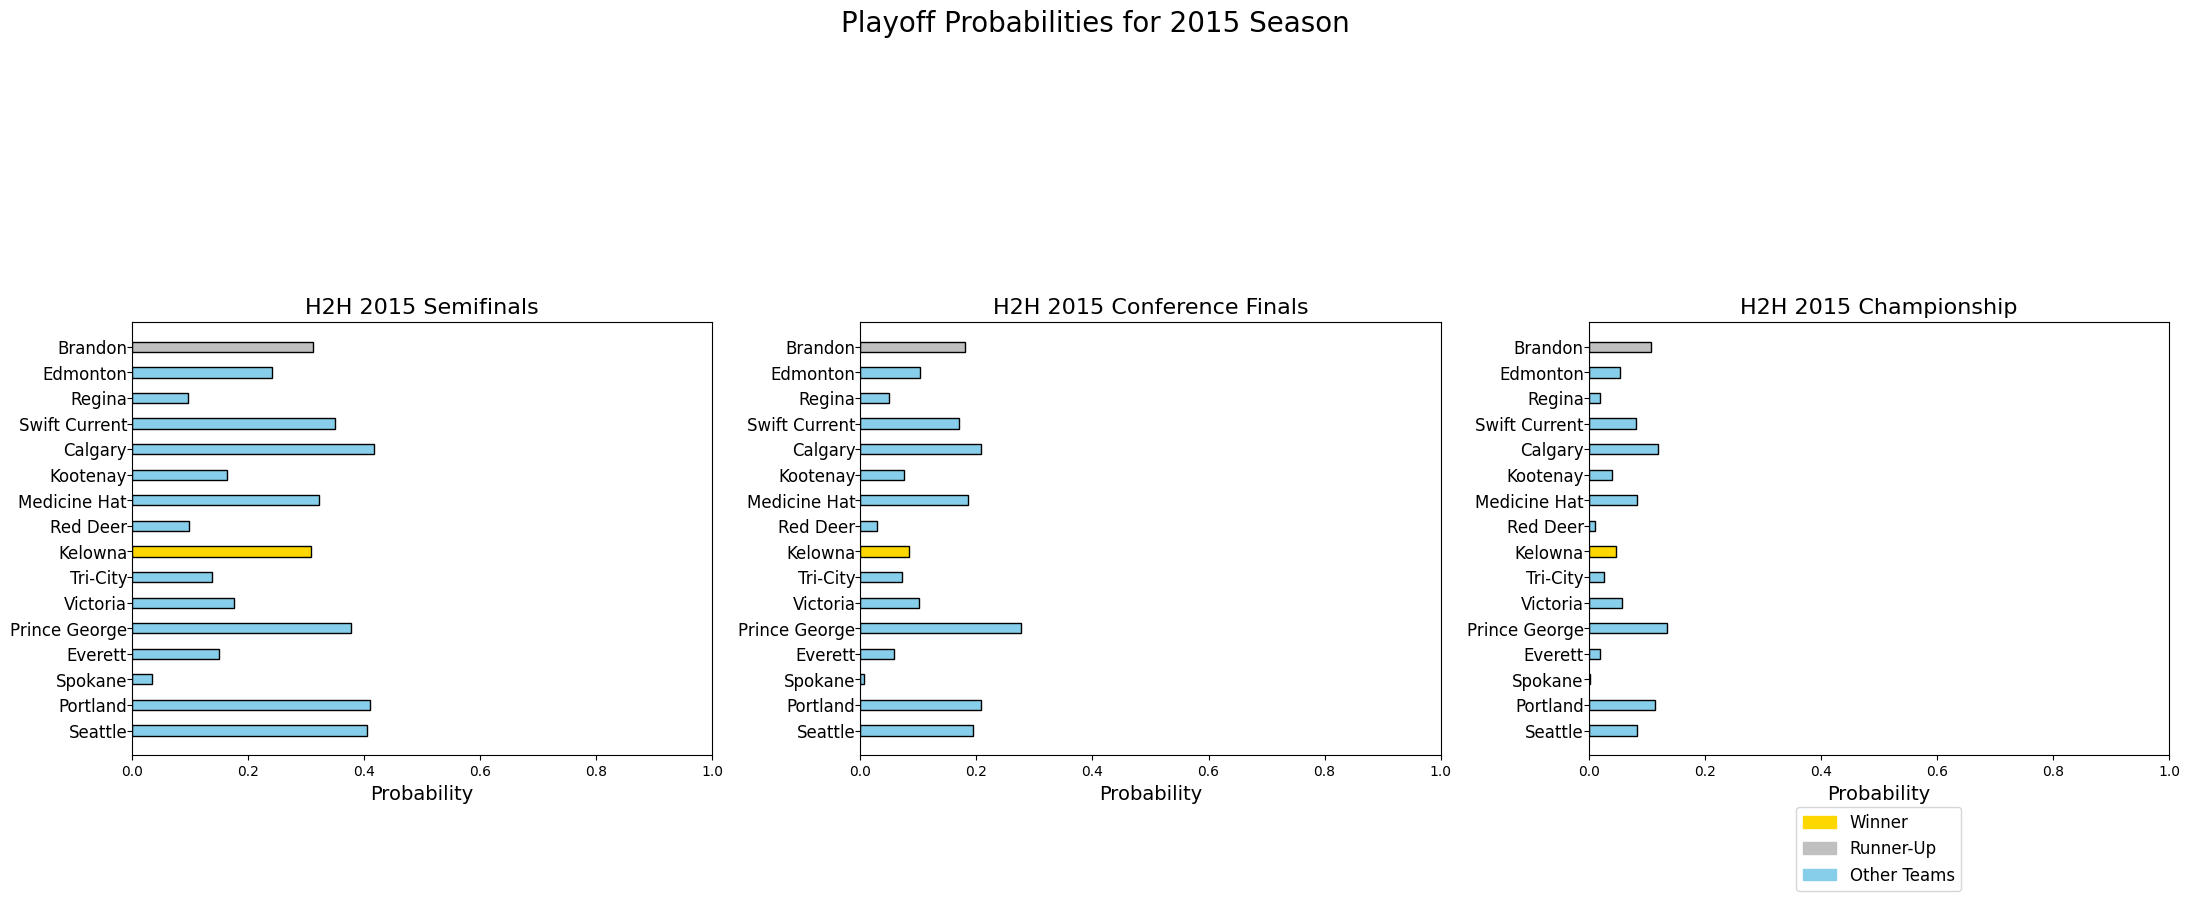

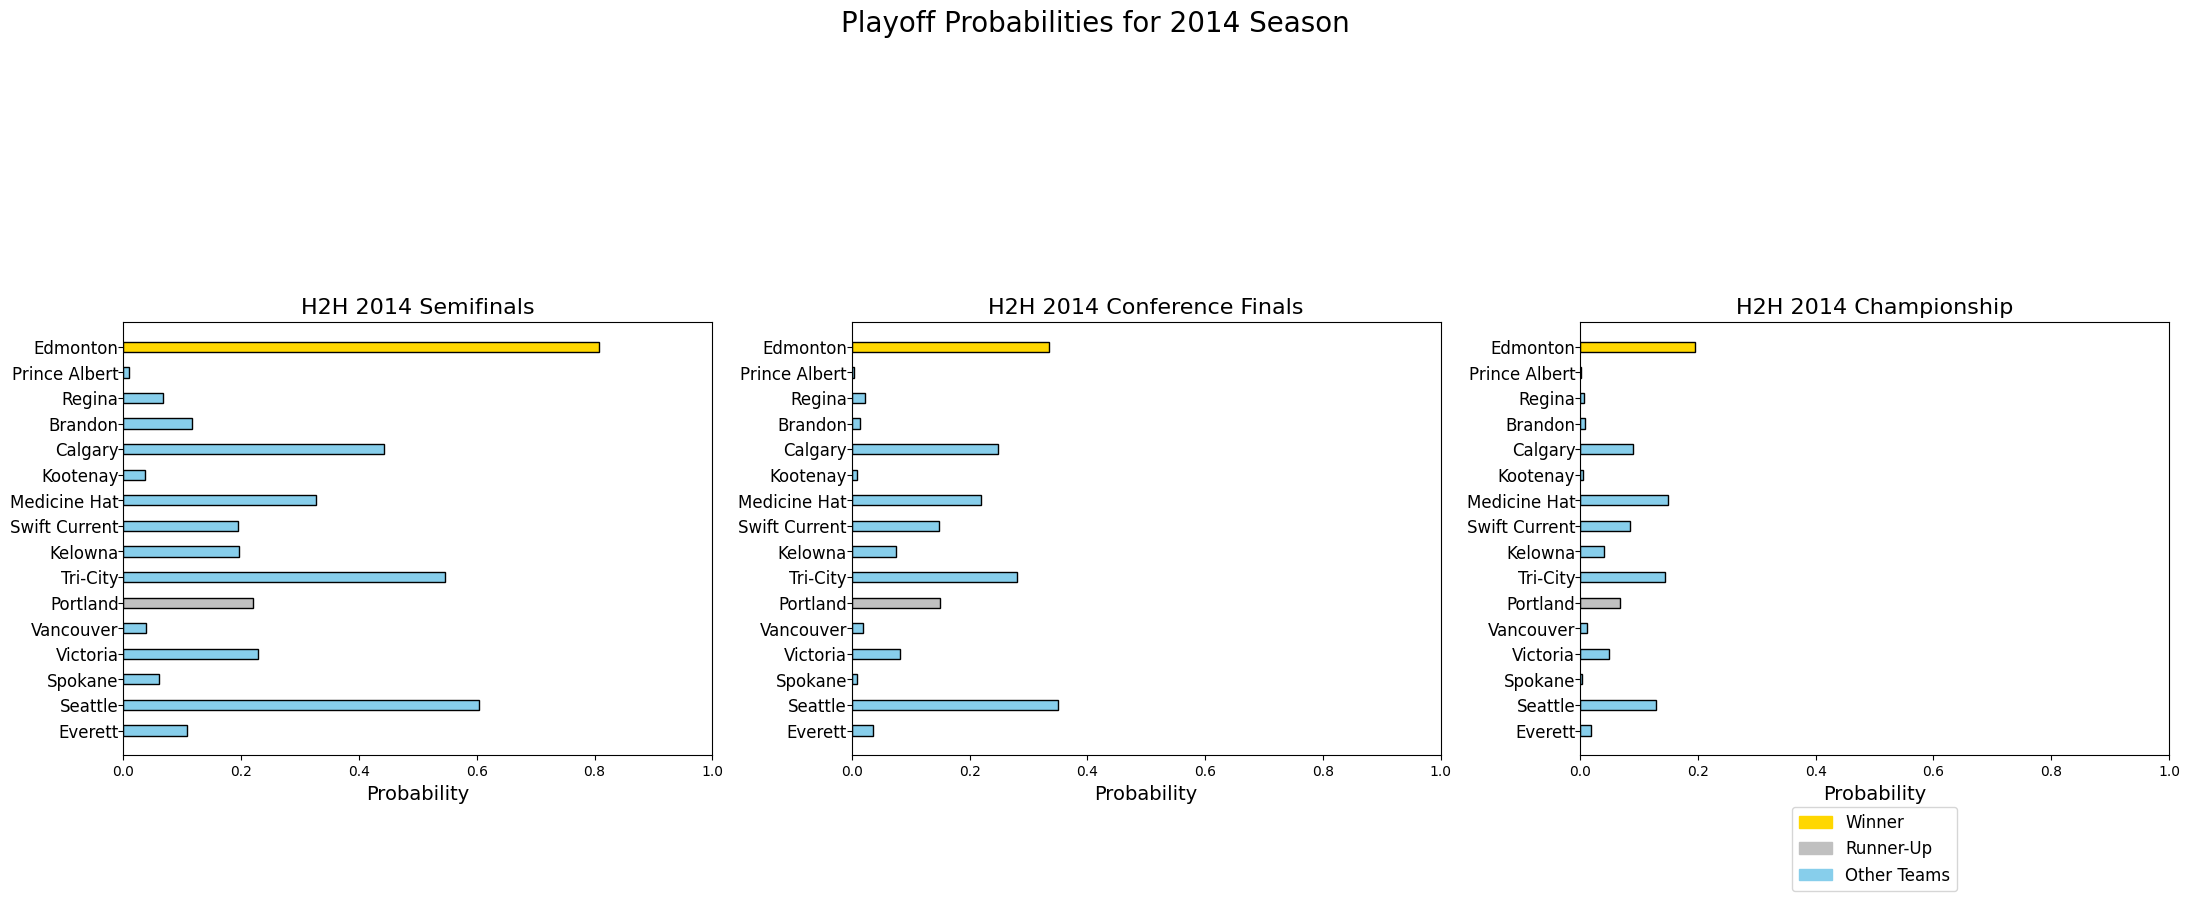

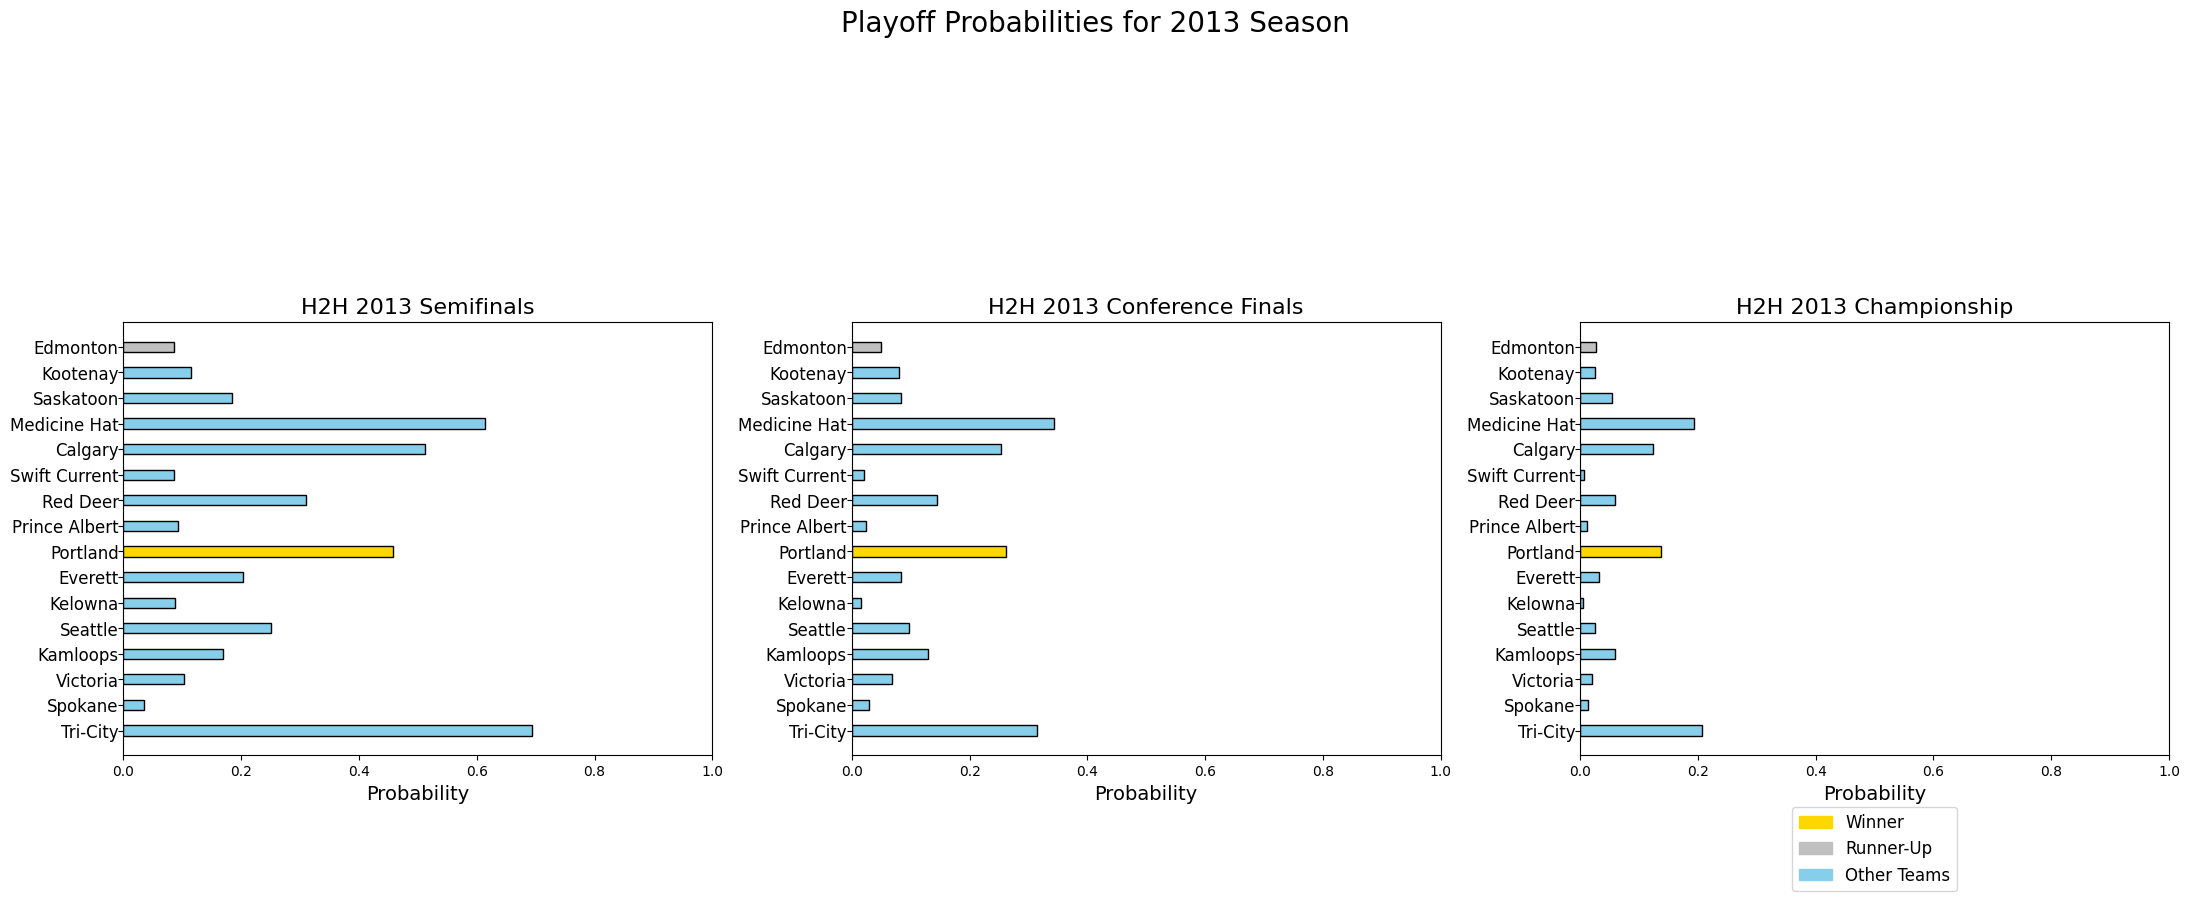

In [ ]:
for year in season_results.keys():
    plot_season_probabilities(season_results, year, winners_dict, runners_up_dict)

# Part 4: Generating Elo Scores based on Team Statistics

Below, we generate modified Elo scores for each team. These scores do not take head-to-head records into account.

## 4.1: Random Forest Regressor Function

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def analyze_random_forest(df, predictors, target):
    # Ensure column names are clean by removing leading/trailing spaces
    df.columns = df.columns.str.strip()

    X = df[predictors]
    y = df[target]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Initialize and fit the Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Get the feature importances from the Random Forest model
    rf_feature_importances = rf_model.feature_importances_
    sorted_rf_idx = np.argsort(rf_feature_importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(predictors)), rf_feature_importances[sorted_rf_idx], align='center')
    plt.yticks(range(len(predictors)), np.array(predictors)[sorted_rf_idx])
    plt.xlabel('Feature Importance (Random Forest)')
    plt.title('Feature Importance for Random Forest')
    plt.show()

    feature_importances = pd.DataFrame({
        'Feature': np.array(predictors)[sorted_rf_idx],
        'Importance': rf_feature_importances[sorted_rf_idx]
    })

    return rf_model, feature_importances


## 4.2: Analyzing Feature Performance for Total Statistics

We are choosing to use the first seven years of data as training for our Random Forest Model. These coefficients will then be used to test against both the 2023 and 2024 seasons. Note: we are excluding the 2022 season, even though we have data for it, as this season was heavily influenced by scheudling limitations that were holding since the COVID pandemic.

In [ ]:
final_merged_data['Season'] = final_merged_data['Season'].astype(str)

train_merged_data = final_merged_data[final_merged_data['Season'].isin(["2013", "2014", "2015", "2016", "2017", "2018", "2019"])]
test_merged_data = final_merged_data[final_merged_data['Season'].isin(["2023", "2024"])]

print(f"Training Data Shape: {train_merged_data.shape}")
print(f"Test Data Shape: {test_merged_data.shape}")

print("Training Data Sample:")
print(train_merged_data.head())

print("Test Data Sample:")
print(test_merged_data.head())

Training Data Shape: (154, 37)
Test Data Shape: (44, 37)
Training Data Sample:
                  Team   Team_ID  ... Percent_Games_to_OT Season_Year
0  Brandon Wheat Kings  Team_201  ...            0.111111         NaN
1  Brandon Wheat Kings  Team_201  ...            0.125000         NaN
2  Brandon Wheat Kings  Team_201  ...            0.111111         NaN
3  Brandon Wheat Kings  Team_201  ...            0.083333         NaN
4  Brandon Wheat Kings  Team_201  ...            0.138889         NaN

[5 rows x 37 columns]
Test Data Sample:
                   Team   Team_ID  ... Percent_Games_to_OT Season_Year
8   Brandon Wheat Kings  Team_201  ...            0.132353         NaN
9   Brandon Wheat Kings  Team_201  ...            0.102941         NaN
18       Calgary Hitmen  Team_202  ...            0.117647         NaN
19       Calgary Hitmen  Team_202  ...            0.132353         NaN
28   Edmonton Oil Kings  Team_228  ...            0.058824         NaN

[5 rows x 37 columns]


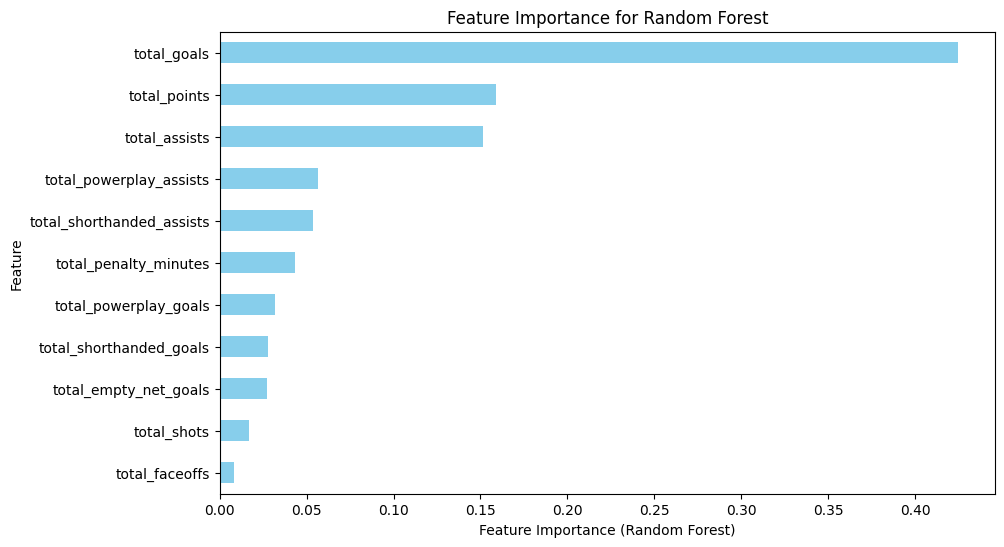

total_goals                  0.424680
total_assists                0.151276
total_points                 0.158895
total_penalty_minutes        0.043491
total_powerplay_goals        0.031554
total_powerplay_assists      0.056381
total_shorthanded_goals      0.027552
total_shorthanded_assists    0.053876
total_empty_net_goals        0.027387
total_shots                  0.016889
total_faceoffs               0.008017
dtype: float64


In [ ]:
predictors = ['total_goals', 'total_assists', 'total_points', 'total_penalty_minutes',
              'total_powerplay_goals', 'total_powerplay_assists',
              'total_shorthanded_goals', 'total_shorthanded_assists',
              'total_empty_net_goals', 'total_shots',
              'total_faceoffs']

target = 'Ranking_Points_Per_Game'

model_total_stats, feature_importances_total_stats = analyze_random_forest(train_merged_data, predictors, target)

print(feature_importances_total_stats)

A point in hockey is either a goal or an assist. For example, if a player has 10 goals and 5 assists on the season, then they finish with 15 points. Therefore, it seems redundant to have both point totals as well as goal and assists totals. We do want to examine the effects of goals and assists separately, however. Therefore, we will remove the effect of the point statistics while leaving the other two.

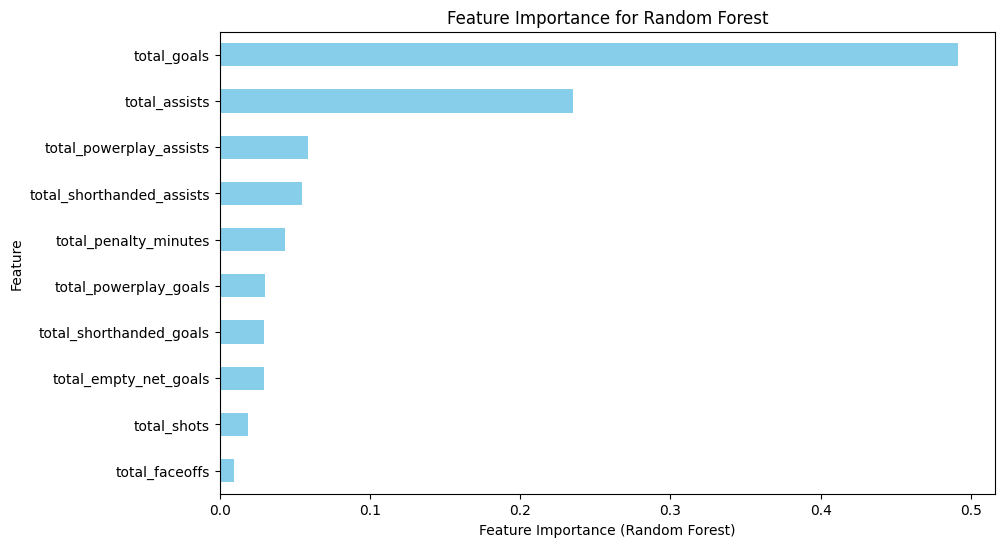

total_goals                  0.491285
total_assists                0.234959
total_penalty_minutes        0.043378
total_powerplay_goals        0.030292
total_powerplay_assists      0.058724
total_shorthanded_goals      0.029324
total_shorthanded_assists    0.054735
total_empty_net_goals        0.029249
total_shots                  0.018614
total_faceoffs               0.009439
dtype: float64


In [ ]:
predictors_no_pt = ['total_goals', 'total_assists', 'total_penalty_minutes',
              'total_powerplay_goals', 'total_powerplay_assists',
              'total_shorthanded_goals', 'total_shorthanded_assists',
              'total_empty_net_goals', 'total_shots',
              'total_faceoffs']

target = 'Ranking_Points_Per_Game'

model_selected_stats, feature_importances_selected_stats = analyze_random_forest(train_merged_data, predictors_no_pt, target)

print(feature_importances_selected_stats)

### 4.2.1: Calculating Elo Scores based on Cumulative Statistics

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def calculate_modified_elo(df, feature_importances):
    # Ensure feature_importances is in the correct format
    if isinstance(feature_importances, pd.Series):
        feature_importances = feature_importances.reset_index()
        feature_importances.columns = ['Feature', 'Importance']

    # Normalize feature importances
    feature_importances['Normalized_Importance'] = (
        np.abs(feature_importances['Importance']) /
        np.sum(np.abs(feature_importances['Importance']))
    )
    selected_features = feature_importances['Feature'].tolist()

    team_data = df.groupby(['Team', 'Season_ID']).agg(
        {feature: 'mean' for feature in selected_features}
    ).reset_index()

    team_scores = team_data.copy()
    for feature in selected_features:
        importance = feature_importances.loc[
            feature_importances['Feature'] == feature, 'Normalized_Importance'
        ].values[0]
        team_scores[f'Weighted_{feature}'] = team_scores[feature] * importance

    team_scores['Modified_Elo'] = team_scores[
        [f'Weighted_{f}' for f in selected_features]
    ].sum(axis=1)

    # Rescale to standard ELO range (1100 to 1800)
    scaler = MinMaxScaler(feature_range=(1100, 1800))
    team_scores['Rescaled_Elo'] = scaler.fit_transform(
        team_scores[['Modified_Elo']]
    )

    return team_scores[['Team', 'Season_ID', 'Rescaled_Elo']]

In [ ]:
train_team_elo_scores_selected_stats = calculate_modified_elo(train_merged_data, feature_importances_selected_stats)
print(train_team_elo_scores_selected_stats)

                    Team Season_ID  Rescaled_Elo
0    Brandon Wheat Kings       242   1190.120007
1    Brandon Wheat Kings       245   1374.460493
2    Brandon Wheat Kings       249   1552.863186
3    Brandon Wheat Kings       251   1492.042565
4    Brandon Wheat Kings       257   1283.203592
..                   ...       ...           ...
149      Victoria Royals       249   1418.820814
150      Victoria Royals       251   1426.496936
151      Victoria Royals       257   1315.464168
152      Victoria Royals       262   1800.000000
153      Victoria Royals       266   1410.320237

[154 rows x 3 columns]


In [ ]:
test_team_elo_scores_selected_stats = calculate_modified_elo(test_merged_data, feature_importances_selected_stats)
print(test_team_elo_scores_selected_stats)

                     Team Season_ID  Rescaled_Elo
0     Brandon Wheat Kings       279   1424.094707
1     Brandon Wheat Kings       281   1395.934945
2          Calgary Hitmen       279   1397.396531
3          Calgary Hitmen       281   1504.411705
4      Edmonton Oil Kings       279   1100.000000
5      Edmonton Oil Kings       281   1380.128679
6      Everett Silvertips       279   1398.571966
7      Everett Silvertips       281   1639.646625
8        Kamloops Blazers       279   1800.000000
9        Kamloops Blazers       281   1238.280150
10        Kelowna Rockets       279   1383.643300
11        Kelowna Rockets       281   1478.132316
12  Lethbridge Hurricanes       279   1331.634581
13  Lethbridge Hurricanes       281   1480.663764
14    Medicine Hat Tigers       279   1399.566656
15    Medicine Hat Tigers       281   1545.167614
16     Moose Jaw Warriors       279   1395.393269
17     Moose Jaw Warriors       281   1618.262882
18   Portland Winterhawks       279   1406.495735


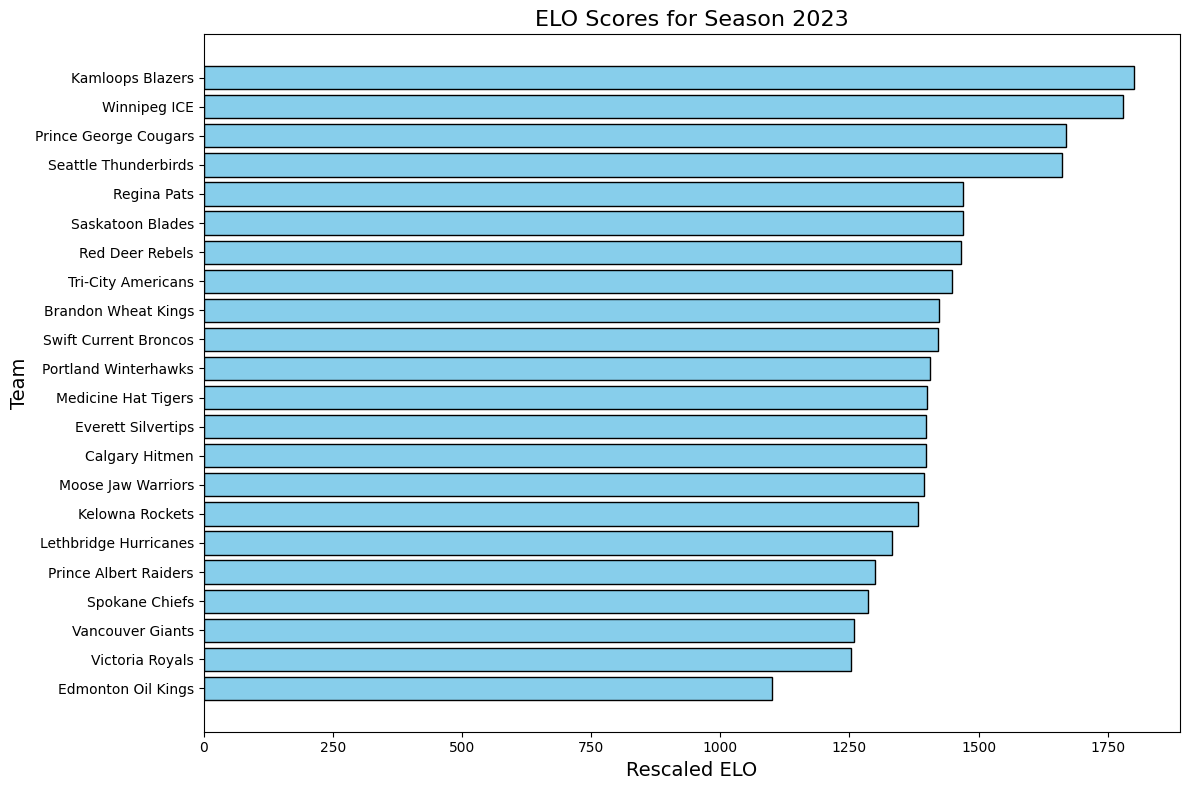

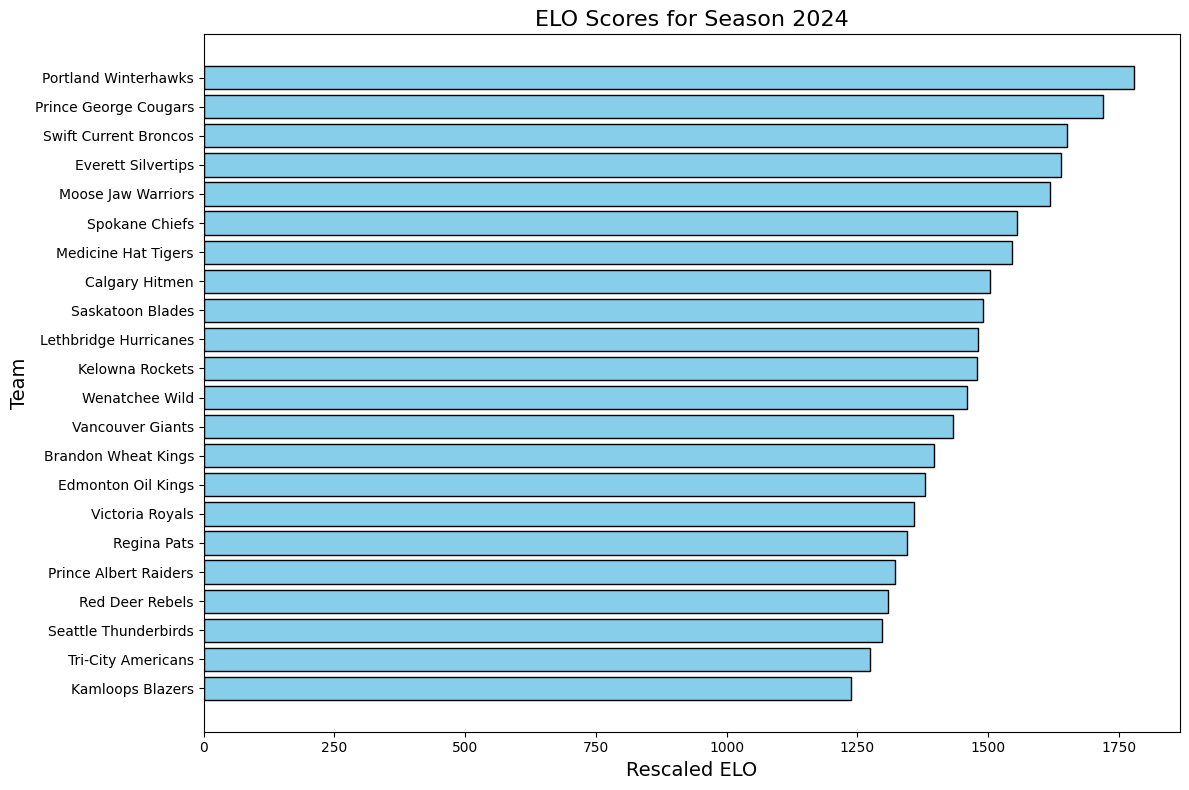

In [ ]:
# Helper function to map Season_ID to Year
def map_season_id_to_year(season_id):
    if season_id == "279":
        return "2023"
    elif season_id == "281":
        return "2024"
    else:
        return str(season_id)

def visualize_test_elo_scores(test_elo_scores):
    # Group by season and sort by ELO scores
    grouped = test_elo_scores.groupby('Season_ID')

    for season_id, group in grouped:
        sorted_group = group.sort_values('Rescaled_Elo', ascending=False)

        season_year = map_season_id_to_year(season_id)

        plt.figure(figsize=(12, 8))
        plt.barh(sorted_group['Team'], sorted_group['Rescaled_Elo'], color='skyblue', edgecolor='black')
        plt.title(f"ELO Scores for Season {season_year}", fontsize=16)
        plt.xlabel("Rescaled ELO", fontsize=14)
        plt.ylabel("Team", fontsize=14)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

visualize_test_elo_scores(test_team_elo_scores_selected_stats)

### 4.2.2: Generating Probability Matrices for Elo Scores

In [ ]:
def calculate_head_to_head_probabilities_seasonwise(team_elo_scores):
    season_probabilities = {}

    for season_id, season_data in team_elo_scores.groupby('Season_ID'):
        probabilities = []

        for i, team_a in season_data.iterrows():
            for j, team_b in season_data.iterrows():
                # If a team plays against itself, set both probabilities to 0.5
                if team_a['Team'] == team_b['Team']:
                    p_a_beats_b = 0.5
                    p_b_beats_a = 0.5
                else:
                    elo_a = team_a['Rescaled_Elo']
                    elo_b = team_b['Rescaled_Elo']

                    # Calculate the initial probability using the Elo formula
                    raw_p_a_beats_b = 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

                    # Scale game probabilities to fall within [0.25, 0.75]
                    p_a_beats_b = 0.25 + 0.5 * raw_p_a_beats_b

                    # Adjust to ensure sum-to-1 rule holds
                    p_b_beats_a = 1 - p_a_beats_b

                probabilities.append({
                    'Team_A': team_a['Team'],
                    'Team_B': team_b['Team'],
                    'P_A_beats_B': p_a_beats_b,
                    'P_B_beats_A': p_b_beats_a
                })

        # Convert the list of probabilities to a DataFrame for the season
        prob_df = pd.DataFrame(probabilities)
        prob_matrix = prob_df.pivot(index='Team_A', columns='Team_B', values='P_A_beats_B')

        season_probabilities[season_id] = prob_matrix

    return season_probabilities

In [ ]:
train_p_matrix_total_stats = calculate_head_to_head_probabilities_seasonwise(train_team_elo_scores_selected_stats)
test_p_matrix_total_stats = calculate_head_to_head_probabilities_seasonwise(test_team_elo_scores_selected_stats)

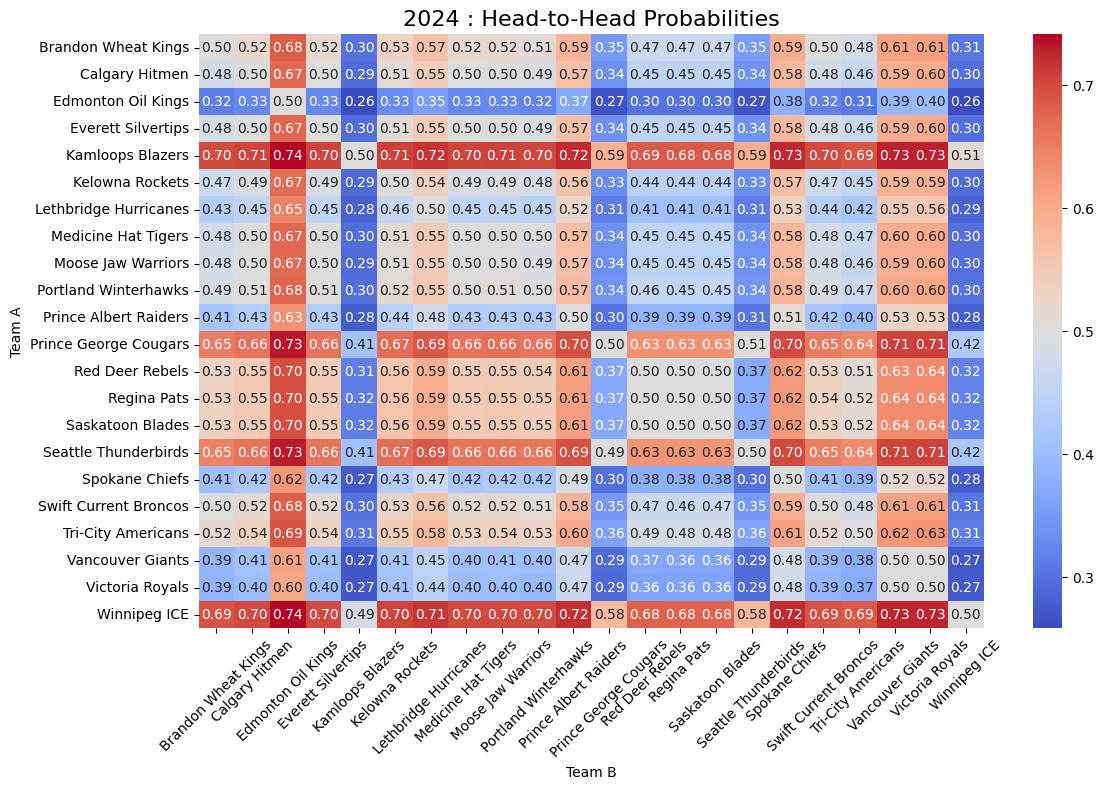

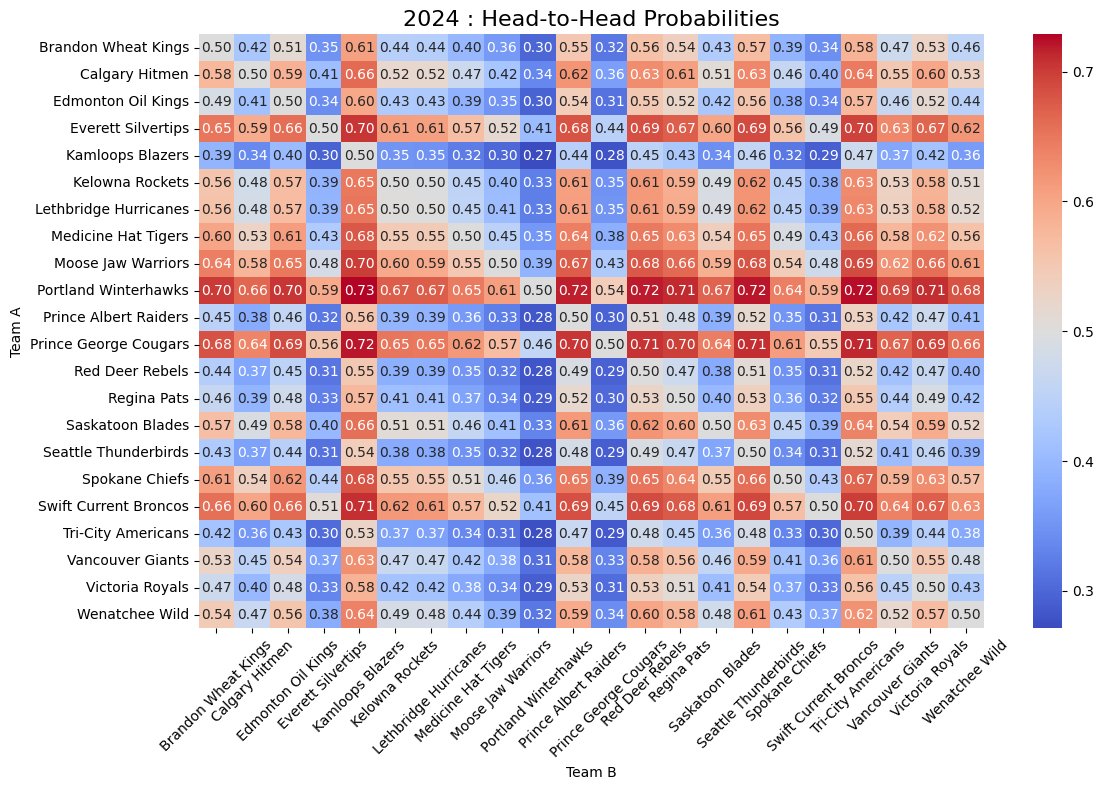

In [ ]:
def plot_head_to_head_heatmap(prob_matrix, title="Head-to-Head Probabilities Heatmap"):

    # Plot the heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(prob_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(title, fontsize=16)
    plt.xlabel("Team B")
    plt.ylabel("Team A")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

for season_id, prob_matrix in test_p_matrix_total_stats.items():
    plot_head_to_head_heatmap(prob_matrix, title=f"2024 : Head-to-Head Probabilities")

In [ ]:
def recast_team_names_as_3d_matrix(p_matrix_total_stats, team_id_mapping):

    def get_matching_team_name(team_name):
        for mapped_name in team_id_mapping.keys():
            if mapped_name in team_name:
                return mapped_name
        return team_name

    team_names = list(team_id_mapping.keys())

    season_probabilities = []

    # Recast team names in the index and columns and build 3D matrix
    for season_id, prob_matrix in p_matrix_total_stats.items():
        updated_prob_matrix = prob_matrix.copy()

        updated_prob_matrix.index = [get_matching_team_name(name) for name in prob_matrix.index]
        updated_prob_matrix.columns = [get_matching_team_name(name) for name in prob_matrix.columns]

        season_matrix = updated_prob_matrix.values
        season_probabilities.append(season_matrix)

    return np.array(season_probabilities)

### 4.2.3: Re-initialization for Team Mapping for Clarity

In [ ]:
team_id_mapping = {
    'Brandon': ('Team_201', 0), 'Calgary': ('Team_202', 1), 'Kamloops': ('Team_203', 2), 'Kelowna': ('Team_204', 3), 'Lethbridge': ('Team_205', 4),
    'Medicine Hat': ('Team_206', 5), 'Moose Jaw': ('Team_207', 6), 'Portland': ('Team_208', 7), 'Prince Albert': ('Team_209', 8), 'Prince George': ('Team_210', 9),
    'Red Deer': ('Team_211', 10), 'Regina': ('Team_212', 11), 'Saskatoon': ('Team_213', 12), 'Seattle': ('Team_214', 13), 'Spokane': ('Team_215', 14),
    'Swift Current': ('Team_216', 15), 'Tri-City': ('Team_217', 16), 'Wenatchee': ('Team_222', 17), 'Winnipeg': ('Team_222', 17), 'Kootenay': ('Team_222', 17),
    'Vancouver': ('Team_223', 18), 'Everett': ('Team_226', 19), 'Victoria': ('Team_227', 20), 'Edmonton': ('Team_228', 21)
}

### 4.3.4: Running Tournament Simulation for Cumulative Stats Elo Scores

In [ ]:
train_probability_3d_matrix_total_stats = recast_team_names_as_3d_matrix(train_p_matrix_total_stats, team_id_mapping)
test_probability_3d_matrix_total_stats = recast_team_names_as_3d_matrix(test_p_matrix_total_stats, team_id_mapping)

train_probability_3d_matrix_total_stats.shape
test_probability_3d_matrix_total_stats.shape

(2, 22, 22)

In [ ]:
# Define training and testing seasons
training_seasons = ["2013", "2014", "2015", "2016", "2017", "2018", "2019"]
testing_seasons = ["2023", "2024"]

# Create a mapping for training and testing season indices
train_season_indices = {year: i for i, year in enumerate(training_seasons)}
test_season_indices = {year: i for i, year in enumerate(testing_seasons)}

# Iterate over the seasons and run the tournaments
season_results_total_stats = {}
for season_id, year in season_mapping.items():
    year = str(year)
    draws_for_year = draws[int(year)]

    # Determine if the year belongs to training or testing
    if year in training_seasons:
        idx = train_season_indices[year]
        win_loss_matrix = train_probability_3d_matrix_total_stats[idx]
    elif year in testing_seasons:
        idx = test_season_indices[year]
        win_loss_matrix = test_probability_3d_matrix_total_stats[idx]
    else:
        continue

    print(f"Simulating for year {year}...")
    probabilities = run_multiple_tournaments(10000, int(year), draws_for_year, win_loss_matrix)
    season_results_total_stats[year] = probabilities

Simulating for year 2024...
Simulating for year 2023...
Simulating for year 2019...
Simulating for year 2018...
Simulating for year 2017...
Simulating for year 2016...
Simulating for year 2015...
Simulating for year 2014...
Simulating for year 2013...


Processing year 2024...


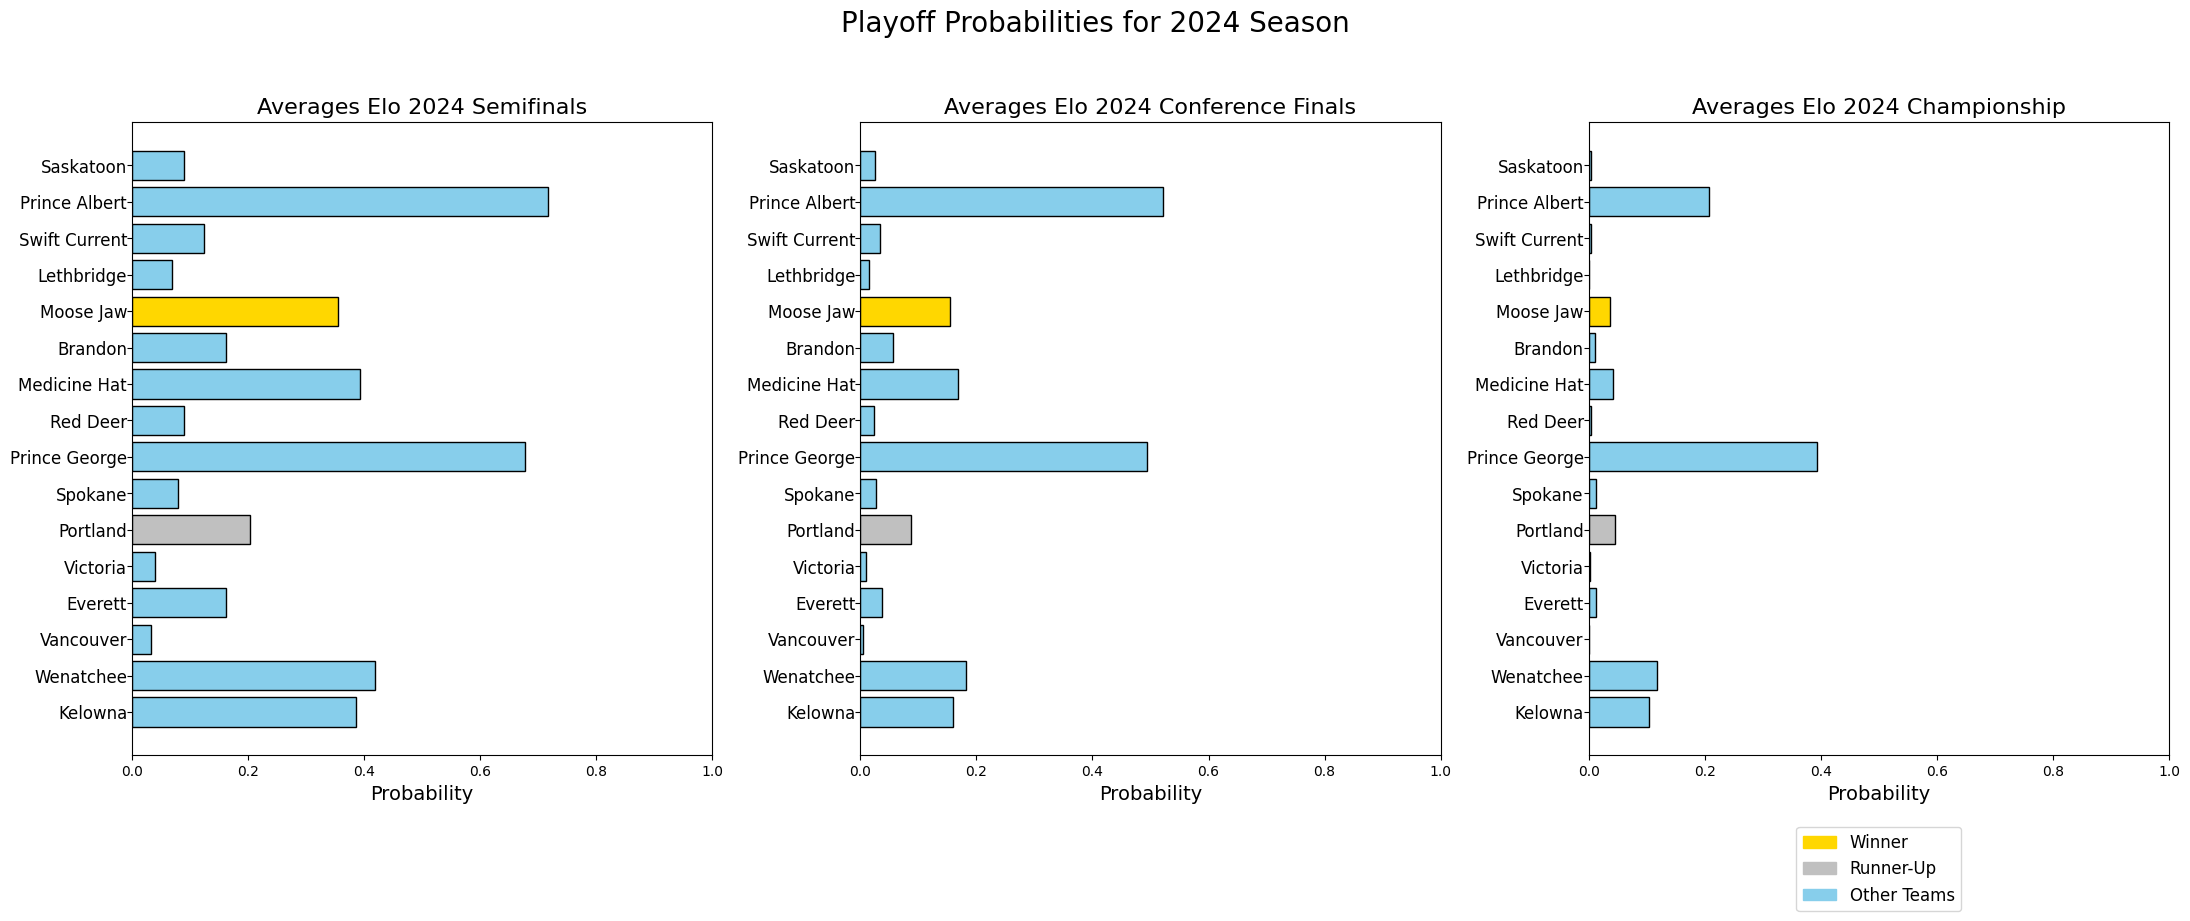

Processing year 2023...


KeyboardInterrupt: 

In [ ]:
# Function to plot playoff probabilities for each season
def plot_playoff_probabilities(season_results, winners_dict, runners_up_dict):
    for year, results in season_results.items():
        print(f"Processing year {year}...")

        if int(year) not in winners_dict and int(year) not in runners_up_dict:
            print(f"Year {year} skipped due to missing winner/runner-up data.")
            continue

        teams = list(results.keys())
        rounds = ["Semifinals", "Conference Finals", "Championship"]

        round_probs = {
            round_name: [results[team].get(round_name, 0) for team in teams]
            for round_name in rounds
        }

        winner = winners_dict.get(int(year), None)
        runner_up = runners_up_dict.get(int(year), None)

        fig, axs = plt.subplots(1, 3, figsize=(22, 10))
        fig.suptitle(f"Playoff Probabilities for {year} Season", fontsize=20)

        for i, round_name in enumerate(rounds):
            colors = ["skyblue"] * len(teams)

            # Highlight winner and runner-up
            if winner in teams:
                colors[teams.index(winner)] = "gold"
            if runner_up in teams:
                colors[teams.index(runner_up)] = "silver"

            axs[i].barh(teams, round_probs[round_name], color=colors, edgecolor="black")
            axs[i].set_title(f"Averages Elo {year} {round_name}", fontsize=16)
            axs[i].set_xlabel("Probability", fontsize=14)
            axs[i].set_xlim(0, 1)
            axs[i].invert_yaxis()
            axs[i].tick_params(axis="y", labelsize=12, pad=0)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color="gold", label="Winner"),
            plt.Rectangle((0, 0), 1, 1, color="silver", label="Runner-Up"),
            plt.Rectangle((0, 0), 1, 1, color="skyblue", label="Other Teams"),
        ]
        axs[-1].legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=12)

        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()

        if int(year) == 2013:
            break

plot_playoff_probabilities(season_results_total_stats, winners_dict, runners_up_dict)

## 4.3: Analyzing Feature Performance for Per-Player Statistics

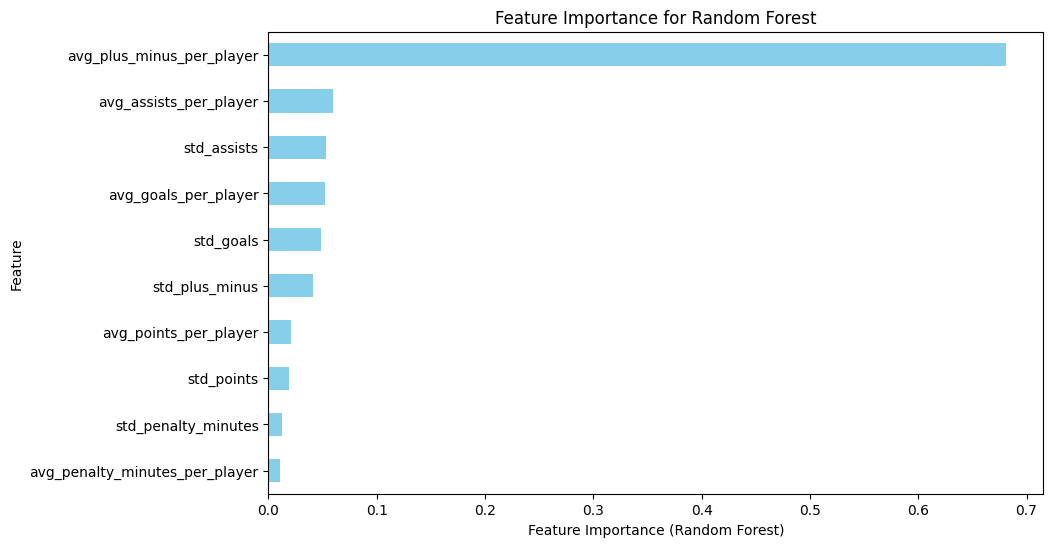

avg_plus_minus_per_player         0.681526
std_plus_minus                    0.041537
avg_goals_per_player              0.052498
std_goals                         0.048867
avg_assists_per_player            0.059222
std_assists                       0.053027
avg_points_per_player             0.021159
std_points                        0.019465
avg_penalty_minutes_per_player    0.010418
std_penalty_minutes               0.012282
dtype: float64


In [ ]:
# Now, we are looking at per player average statistics...
predictors = ['avg_plus_minus_per_player', 'std_plus_minus',
              'avg_goals_per_player', 'std_goals', 'avg_assists_per_player',
              'std_assists', 'avg_points_per_player', 'std_points',
              'avg_penalty_minutes_per_player', 'std_penalty_minutes']

target = 'Ranking_Points_Per_Game'

model_all_stats, feature_importances_all_stats = analyze_random_forest(train_merged_data, predictors, target)

print(feature_importances_all_stats)

This gave us an entirely convincing but also an entirely unhelpful result. The thing most important to regular season success was indeed the average (+/-) for a player on the team. The (+/-) metric indicates how many goals net the player is on the ice for. For example, if a player's team scores 23 goals while he is on the ice across the whole season and the other team scores 13 goals, then his (+/-) would be 10.

Therefore, it entirely makes sense that this metric is the leading indicator for season success is how successful the players are when they are on the ice, on average. As a result of this, we want to take more of a systematic approach of players' stats leading to team success.

Further, a point in hockey is either a goal or an assist. For example, if a player has 10 goals and 5 assists on the season, then they finish with 15 points. Therefore, it seems redundant to have both point totals as well as goal and assists totals. We do want to examine the effects of goals and assists separately, however. Therefore, we will remove the effect of the point statistics while leaving the other two.

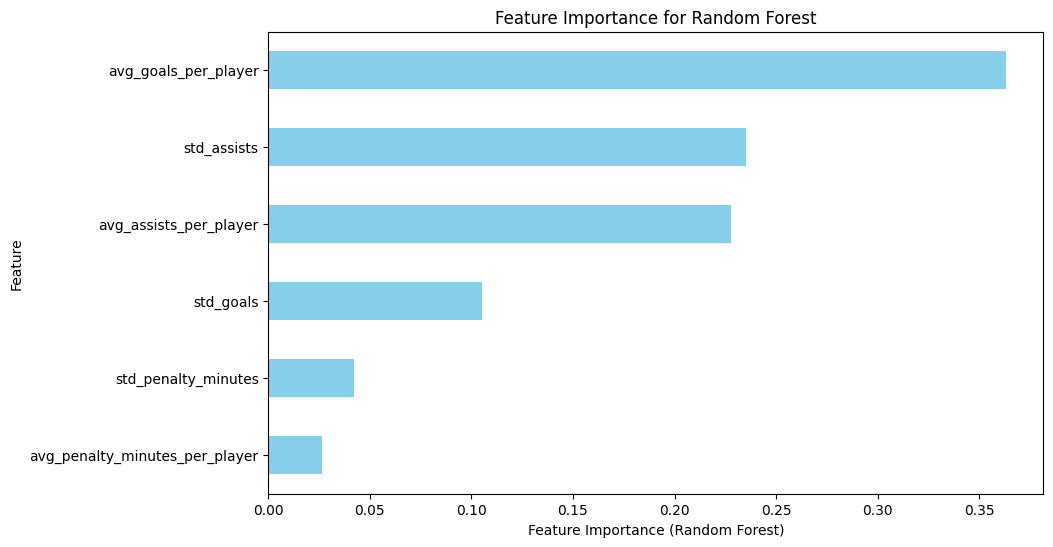

avg_goals_per_player              0.363485
std_goals                         0.105051
avg_assists_per_player            0.228049
std_assists                       0.235043
avg_penalty_minutes_per_player    0.026217
std_penalty_minutes               0.042155
dtype: float64


In [ ]:
# We have removed all stats to do with:
# Plus_Minus (for the reason we discussed above)
# Points (reason above)
new_predictors = ['avg_goals_per_player', 'std_goals', 'avg_assists_per_player',
              'std_assists', 'avg_penalty_minutes_per_player', 'std_penalty_minutes']

model_avg_std_stats, feature_importances_avg_std_stats = analyze_random_forest(train_merged_data, new_predictors, target)

print(feature_importances_avg_std_stats)

### 4.3.1: Calculting Elo Scores, Generating Probability Matrix, and Running Tournament Simulation for the Per-Player Elo Score Model

In [ ]:
trained_team_elo_scores_avg_std_stats = calculate_modified_elo(train_merged_data, feature_importances_avg_std_stats)
tested_team_elo_scores_avg_std_stats = calculate_modified_elo(test_merged_data, feature_importances_avg_std_stats)

trained_p_avg_std_stats = calculate_head_to_head_probabilities_seasonwise(trained_team_elo_scores_avg_std_stats)
tested_p_avg_std_stats = calculate_head_to_head_probabilities_seasonwise(tested_team_elo_scores_avg_std_stats)

trained_probability_3d_matrix_avg_std_stats = recast_team_names_as_3d_matrix(trained_p_avg_std_stats, team_id_mapping)
tested_probability_3d_matrix_avg_std_stats = recast_team_names_as_3d_matrix(tested_p_avg_std_stats, team_id_mapping)

training_seasons = ["2013", "2014", "2015", "2016", "2017", "2018", "2019"]
testing_seasons = ["2023", "2024"]

# Create a mapping for training and testing season indices
train_season_indices = {year: i for i, year in enumerate(training_seasons)}
test_season_indices = {year: i for i, year in enumerate(testing_seasons)}

# Iterate over the seasons and run the tournaments
season_results_avg_std_stats = {}
for season_id, year in season_mapping.items():
    year = str(year)
    draws_for_year = draws[int(year)]

    # Determine if the year belongs to training or testing
    if year in training_seasons:
        idx = train_season_indices[year]
        win_loss_matrix = trained_probability_3d_matrix_avg_std_stats[idx]
    elif year in testing_seasons:
        idx = test_season_indices[year]
        win_loss_matrix = tested_probability_3d_matrix_avg_std_stats[idx]
    else:
        continue

    print(f"Simulating for year {year}...")
    probabilities = run_multiple_tournaments(10000, int(year), draws_for_year, win_loss_matrix)
    season_results_avg_std_stats[year] = probabilities

Simulating for year 2024...
Simulating for year 2023...
Simulating for year 2019...
Simulating for year 2018...
Simulating for year 2017...
Simulating for year 2016...
Simulating for year 2015...
Simulating for year 2014...
Simulating for year 2013...


Processing year 2024...


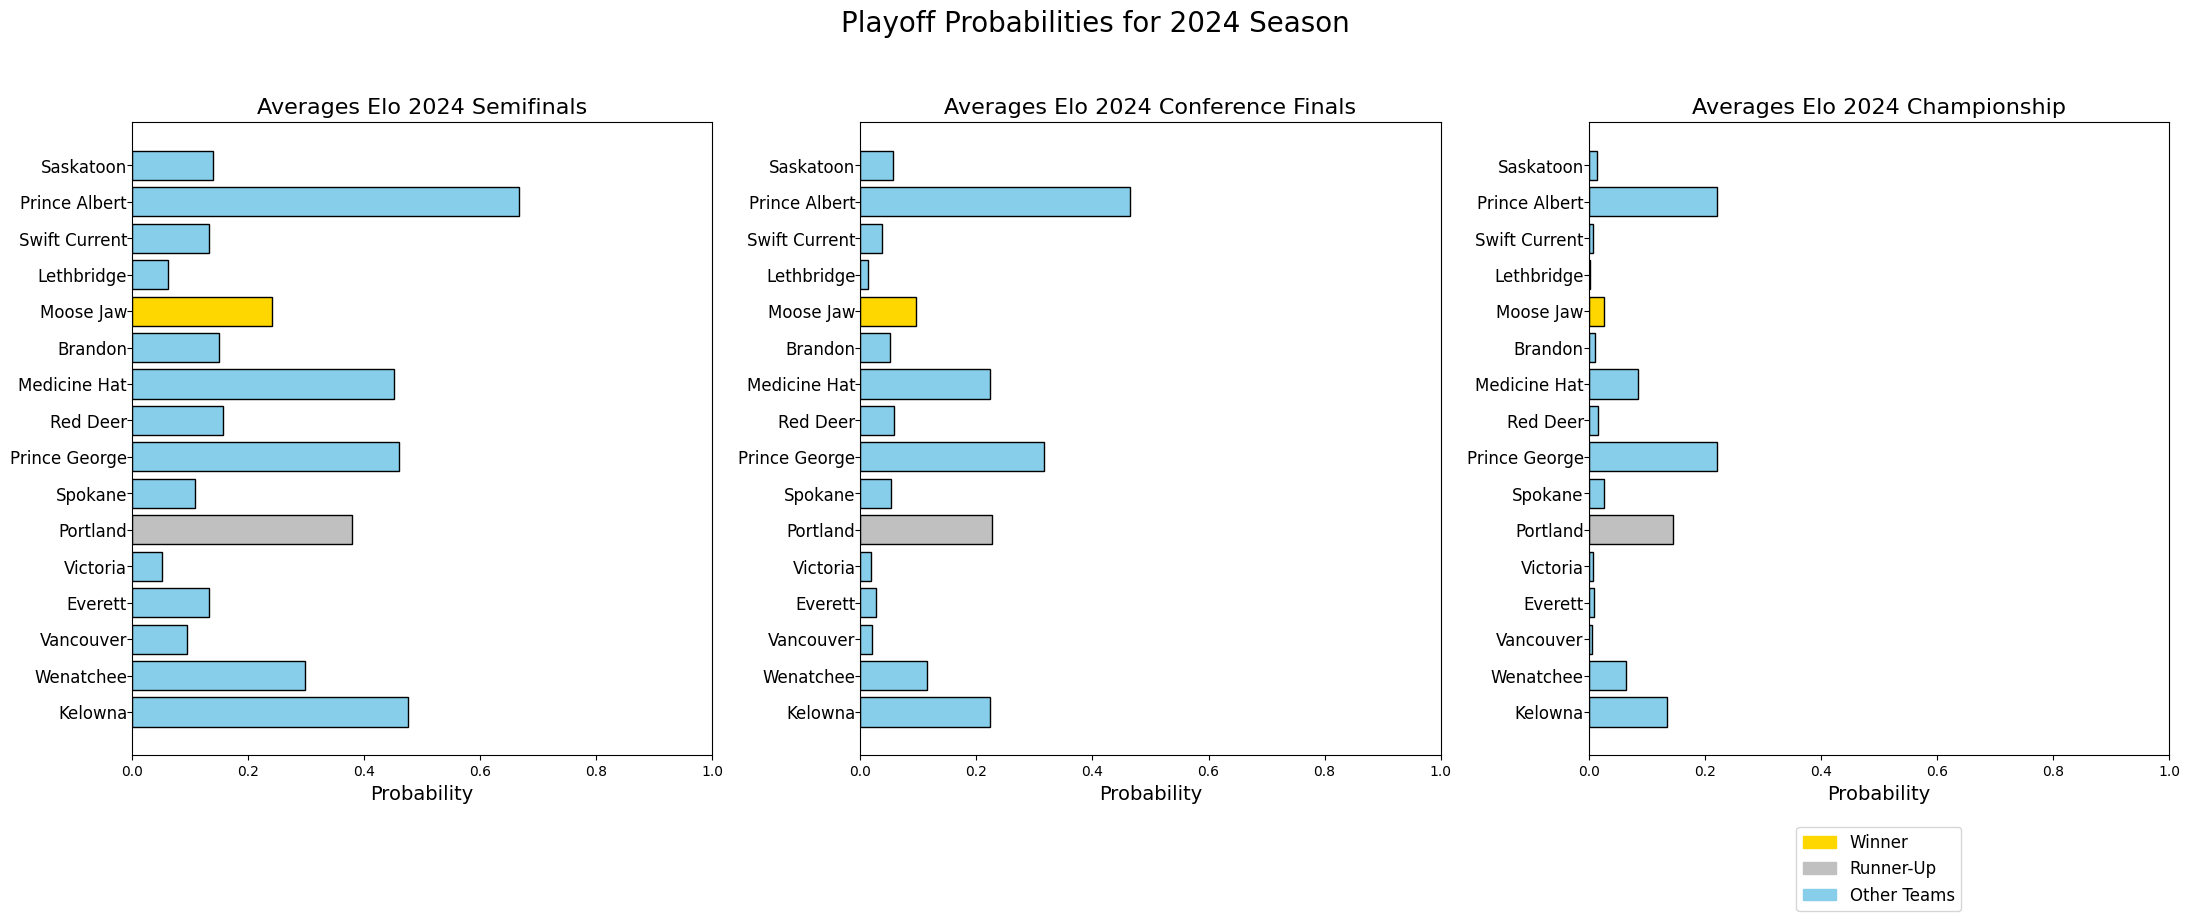

Processing year 2023...


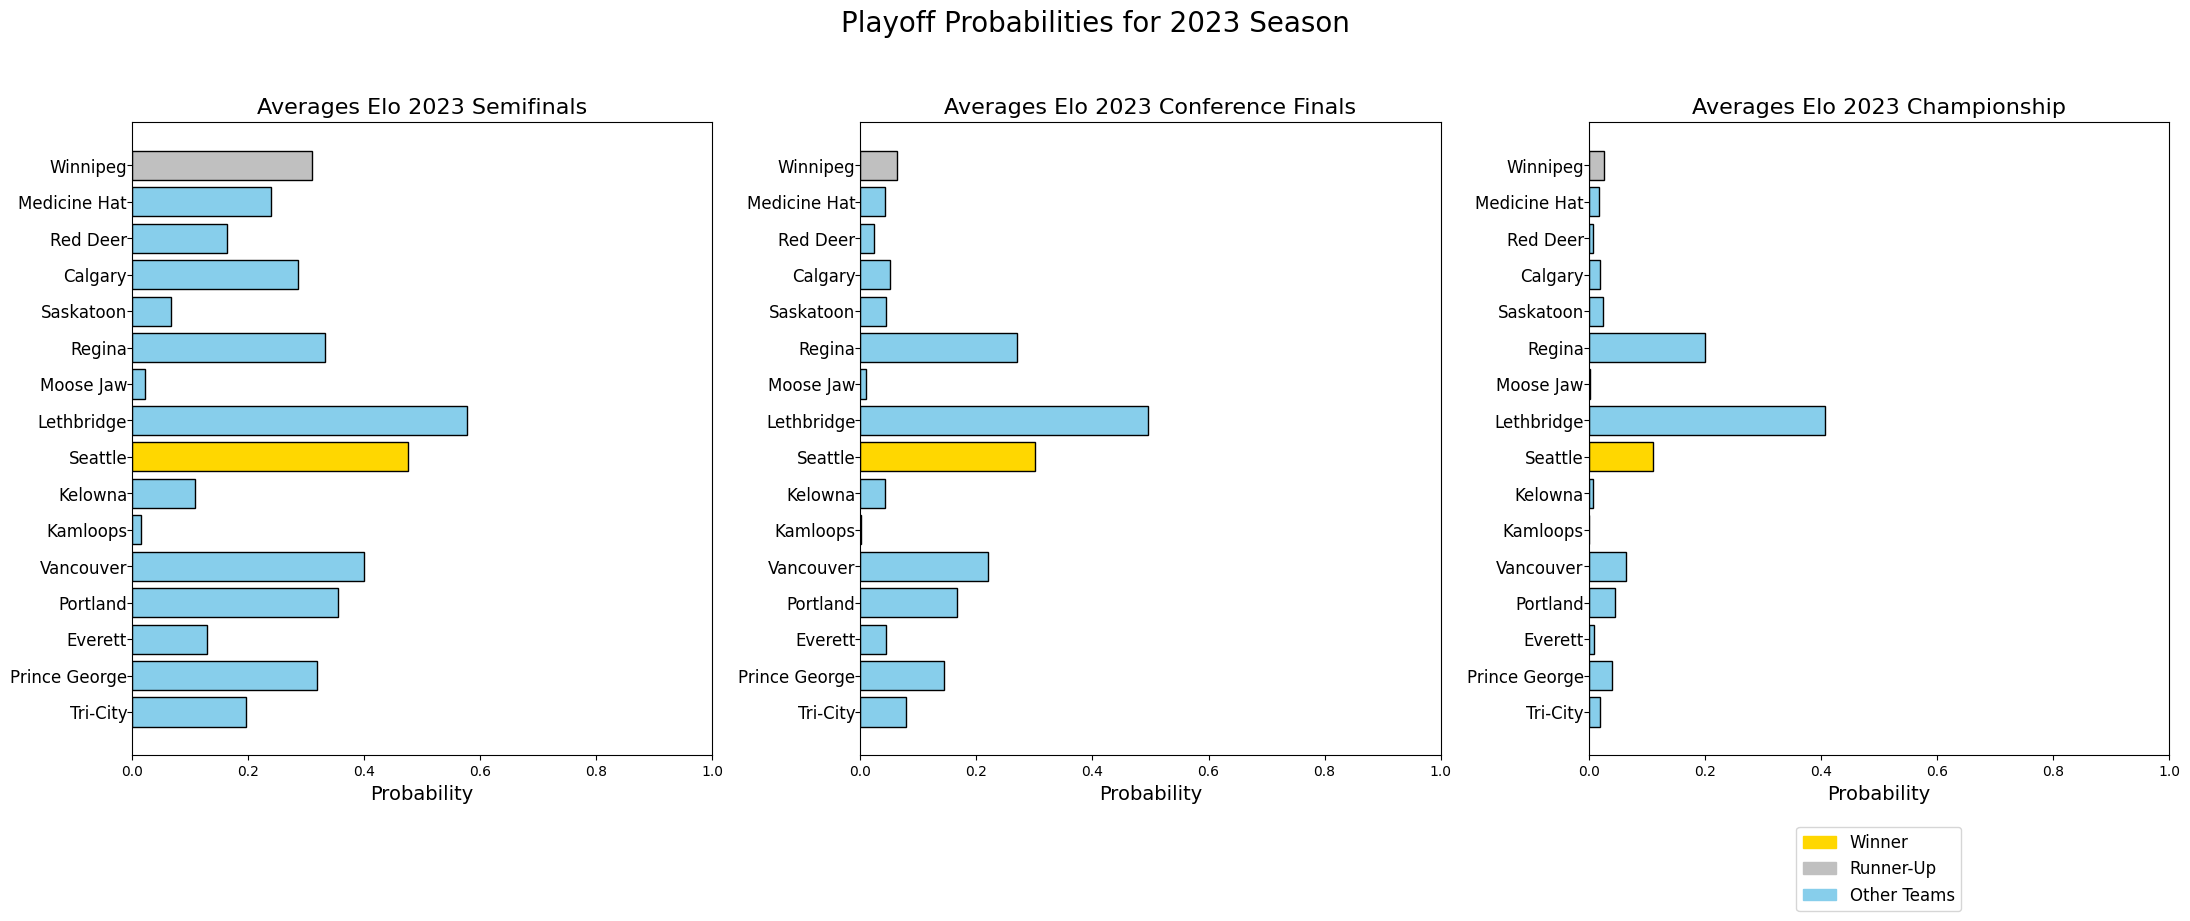

Processing year 2019...


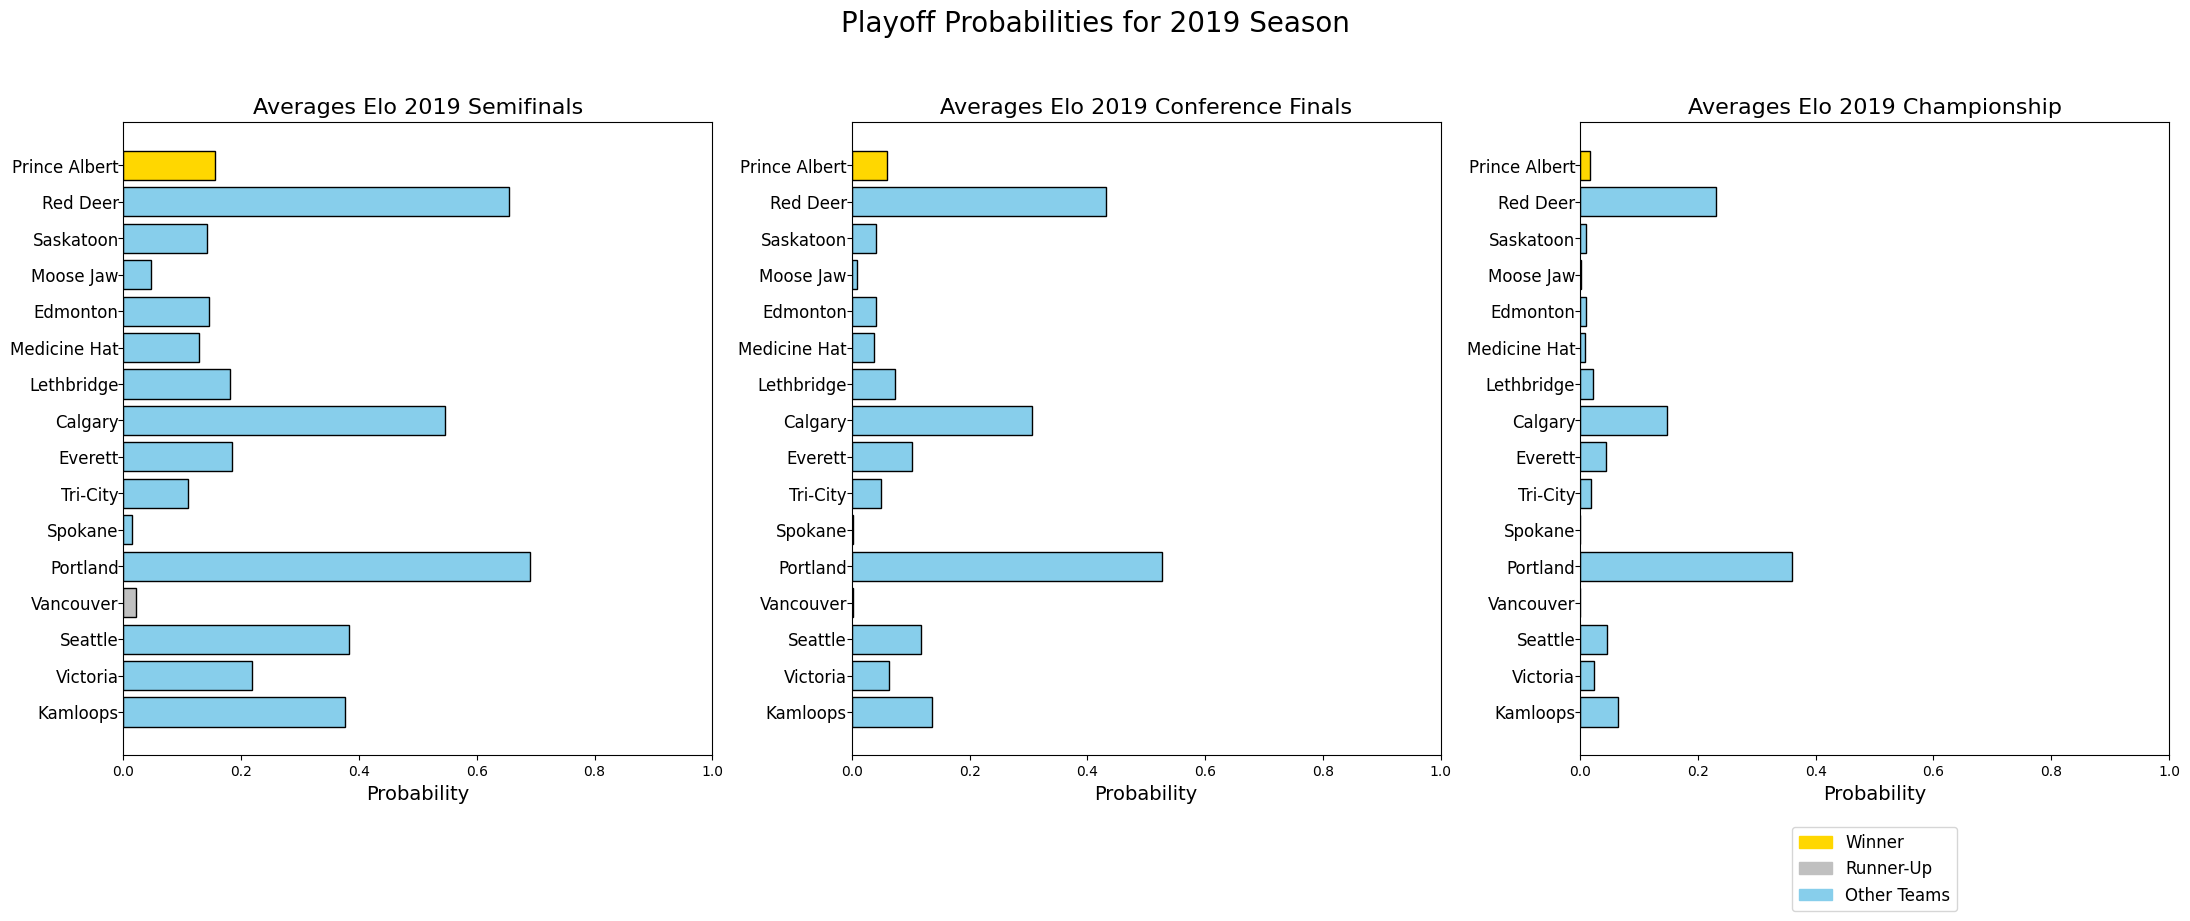

Processing year 2018...


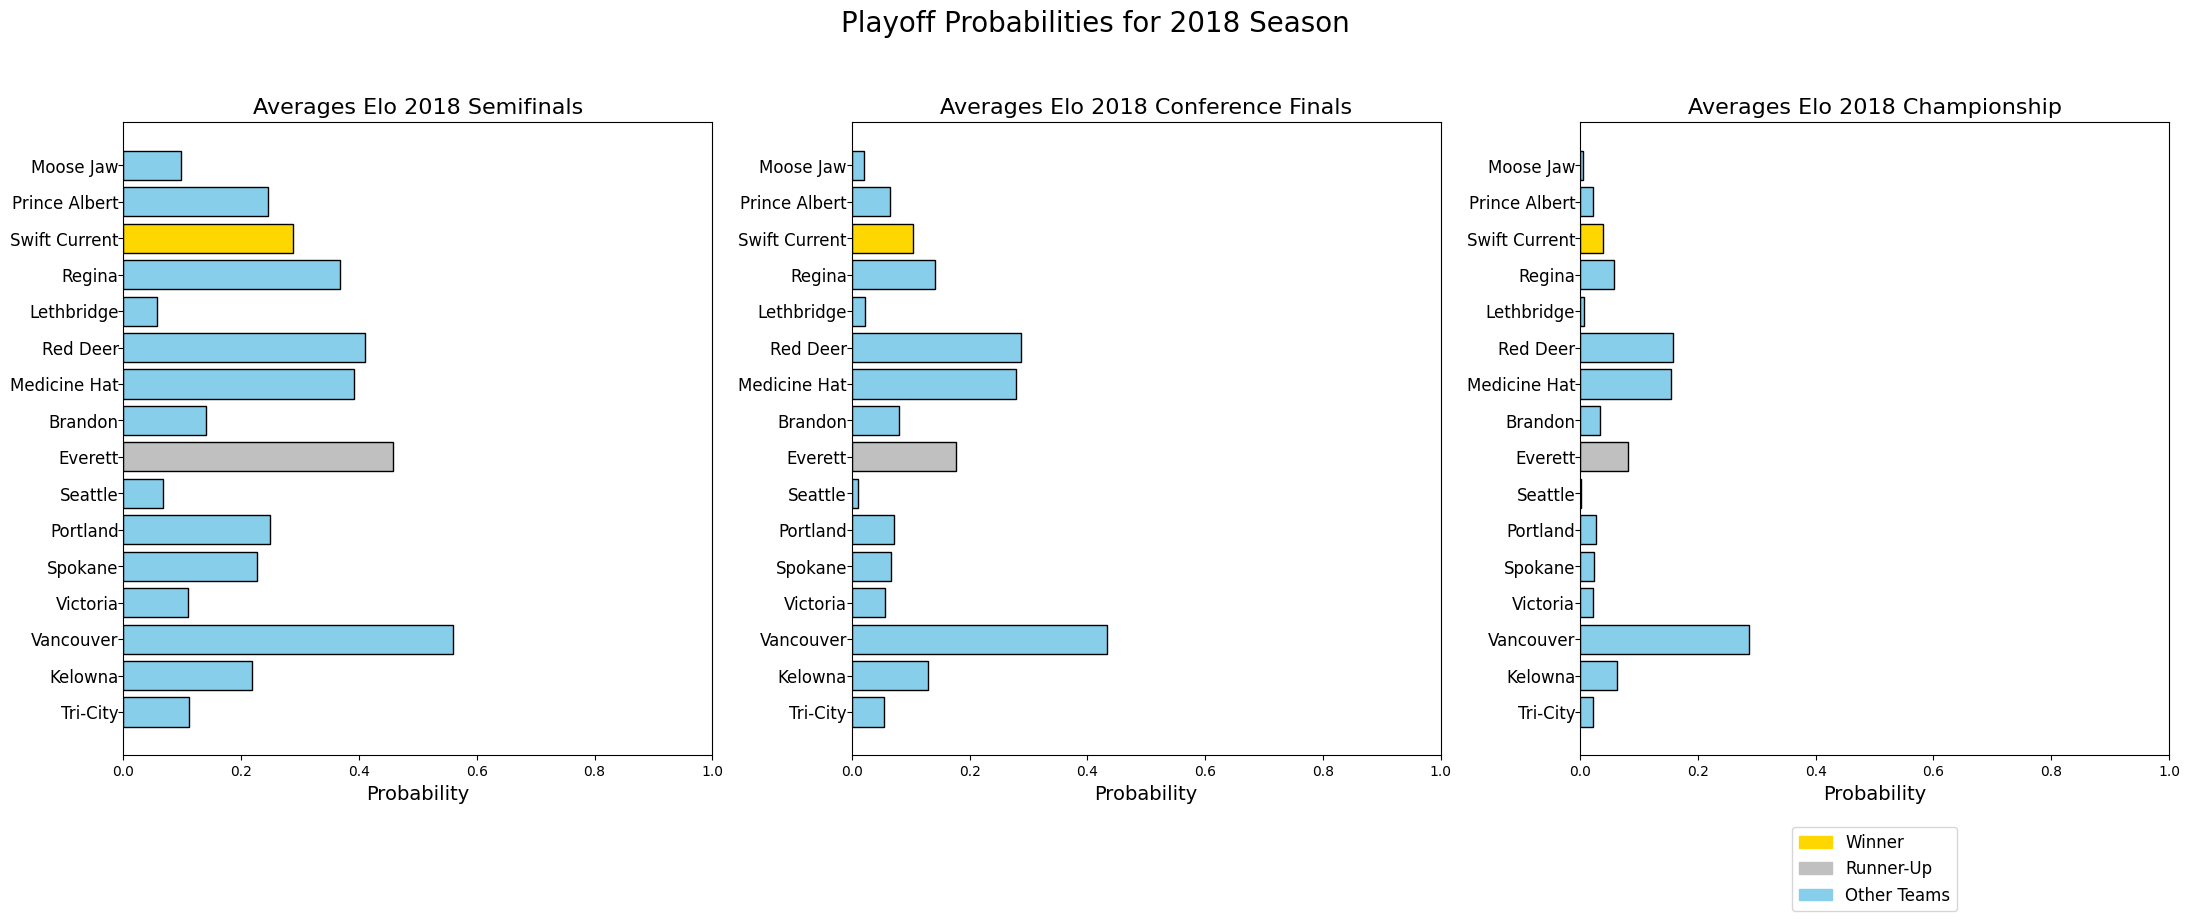

Processing year 2017...


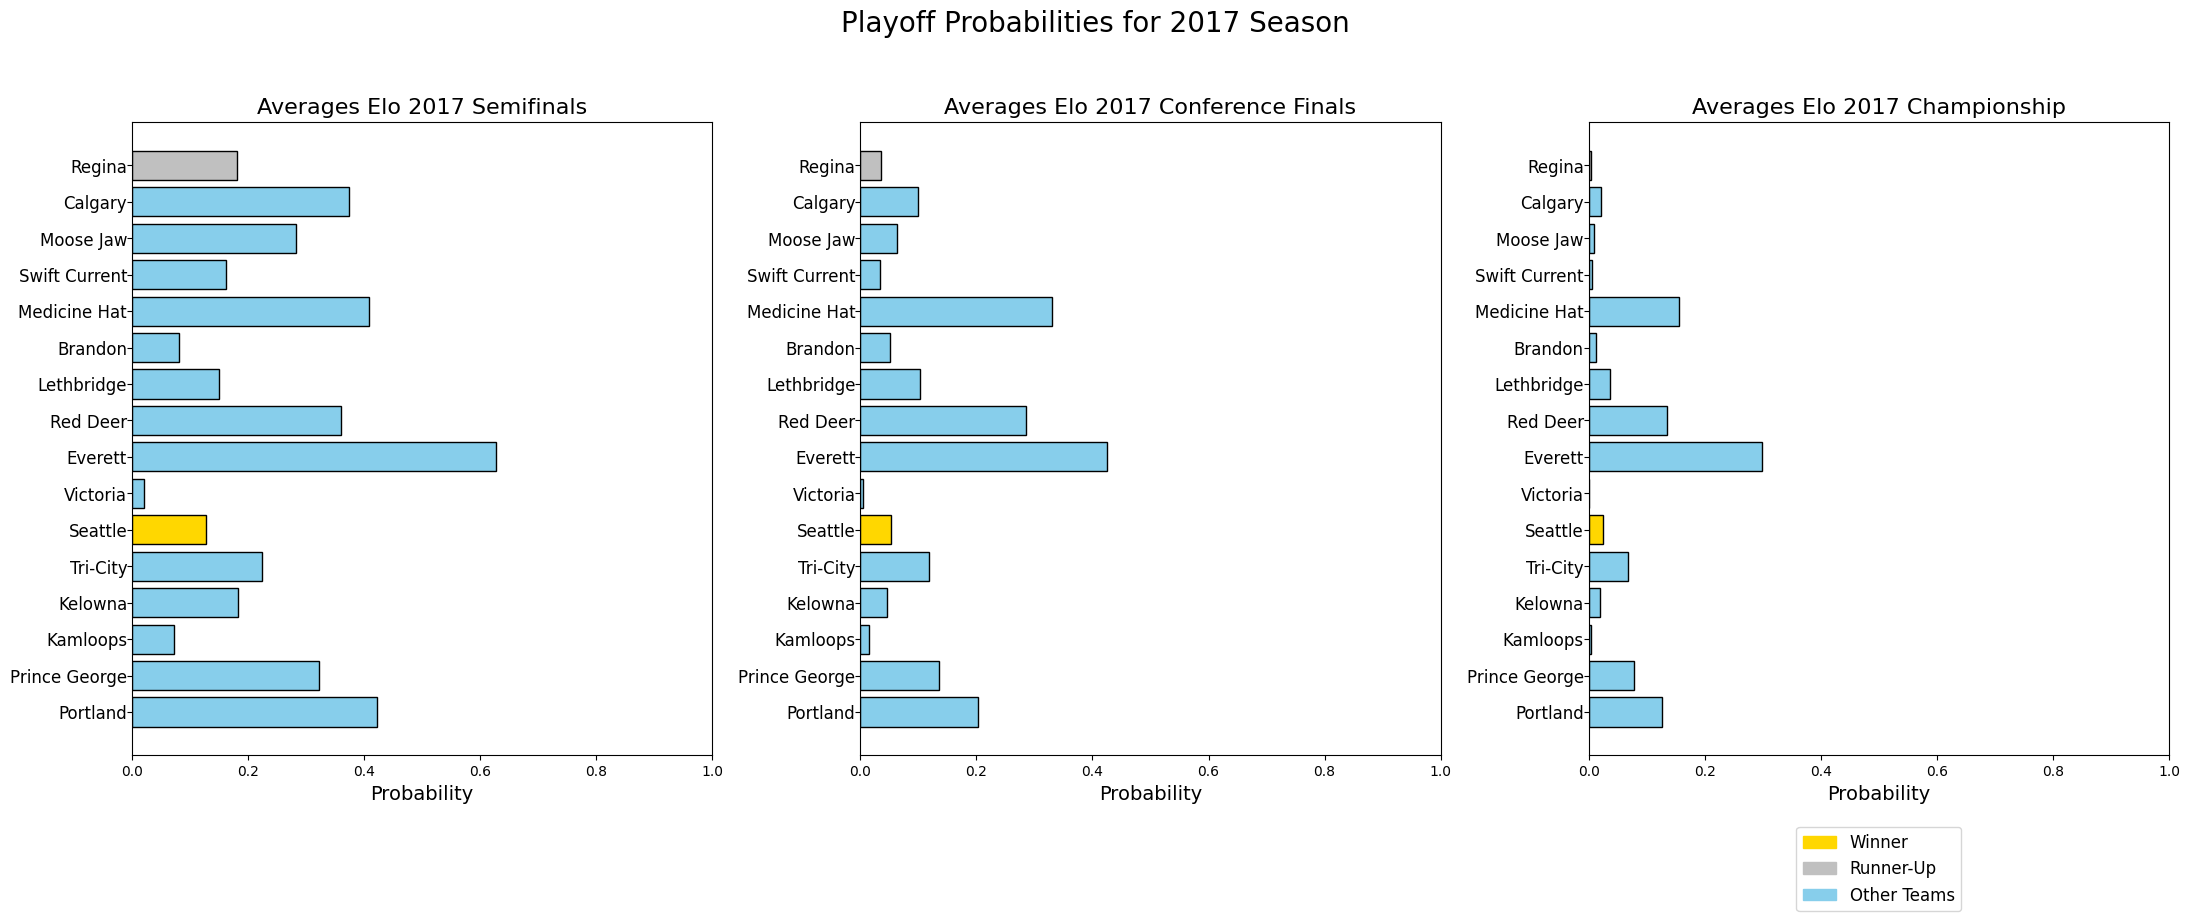

Processing year 2016...


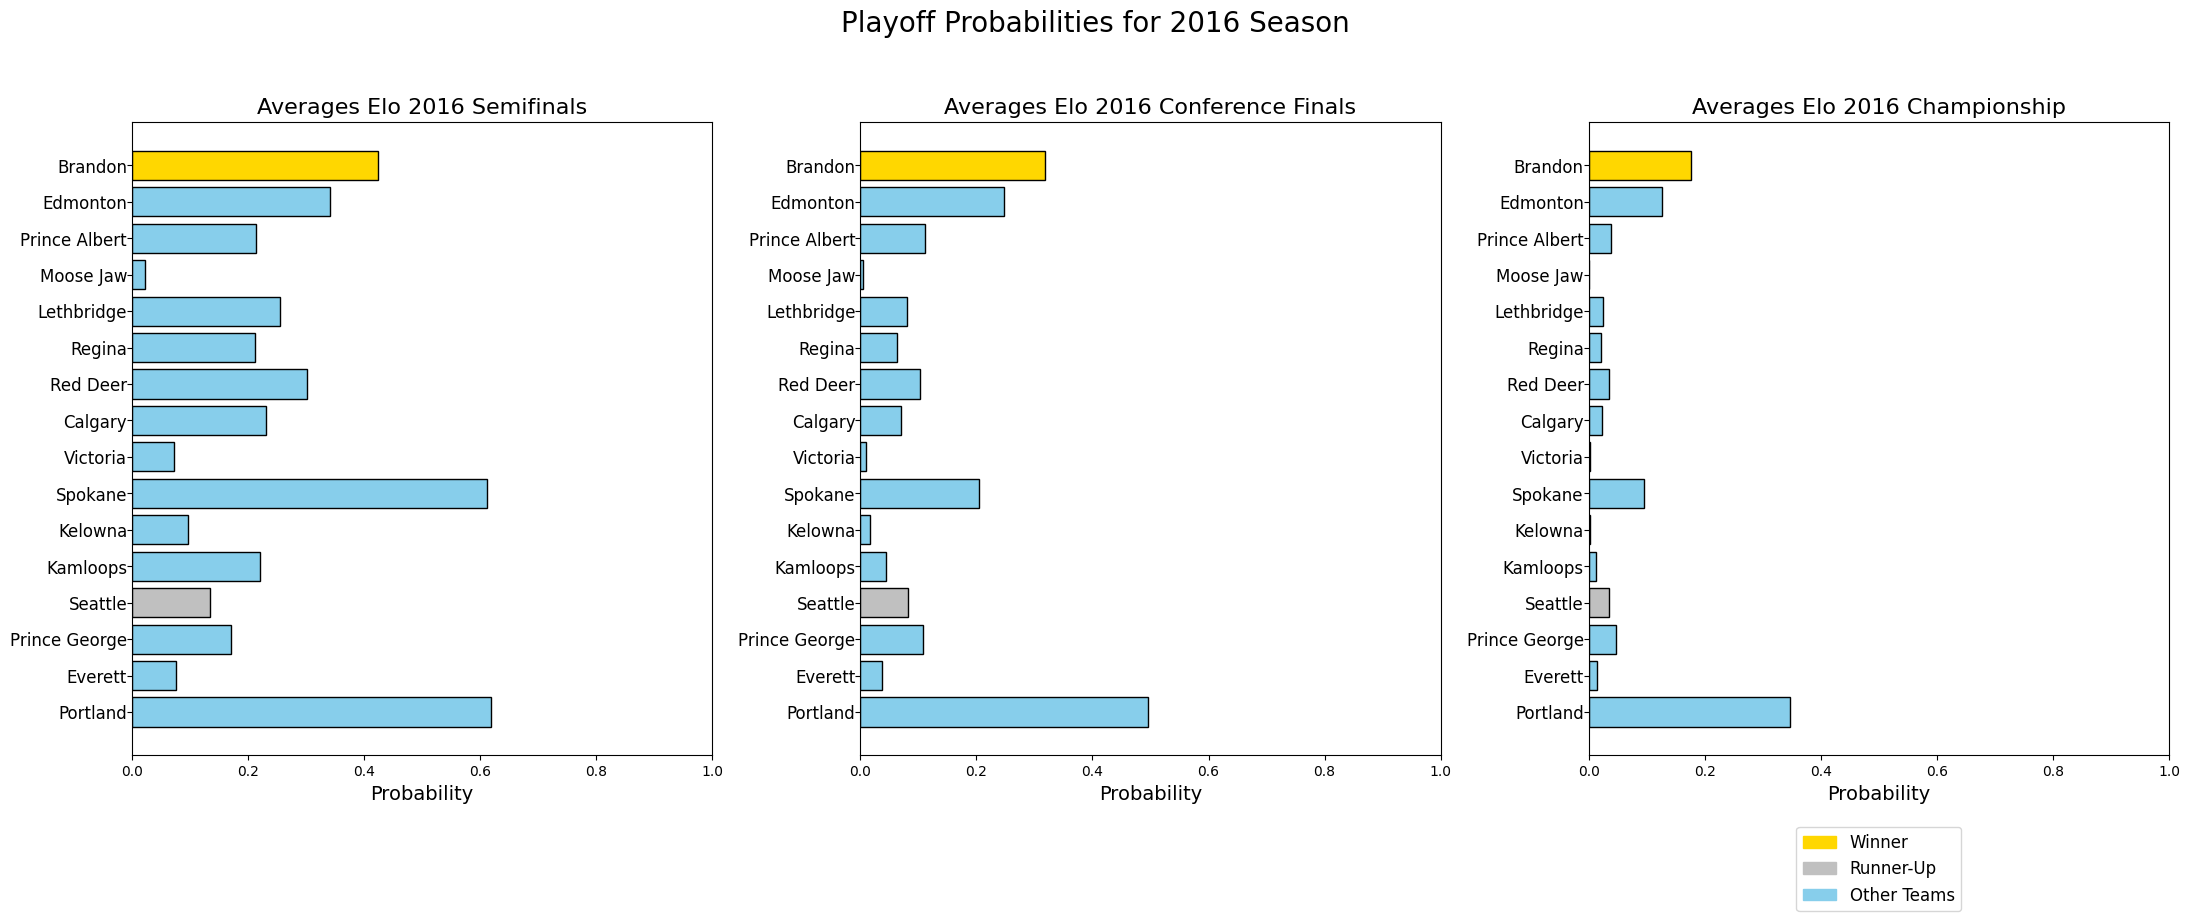

Processing year 2015...


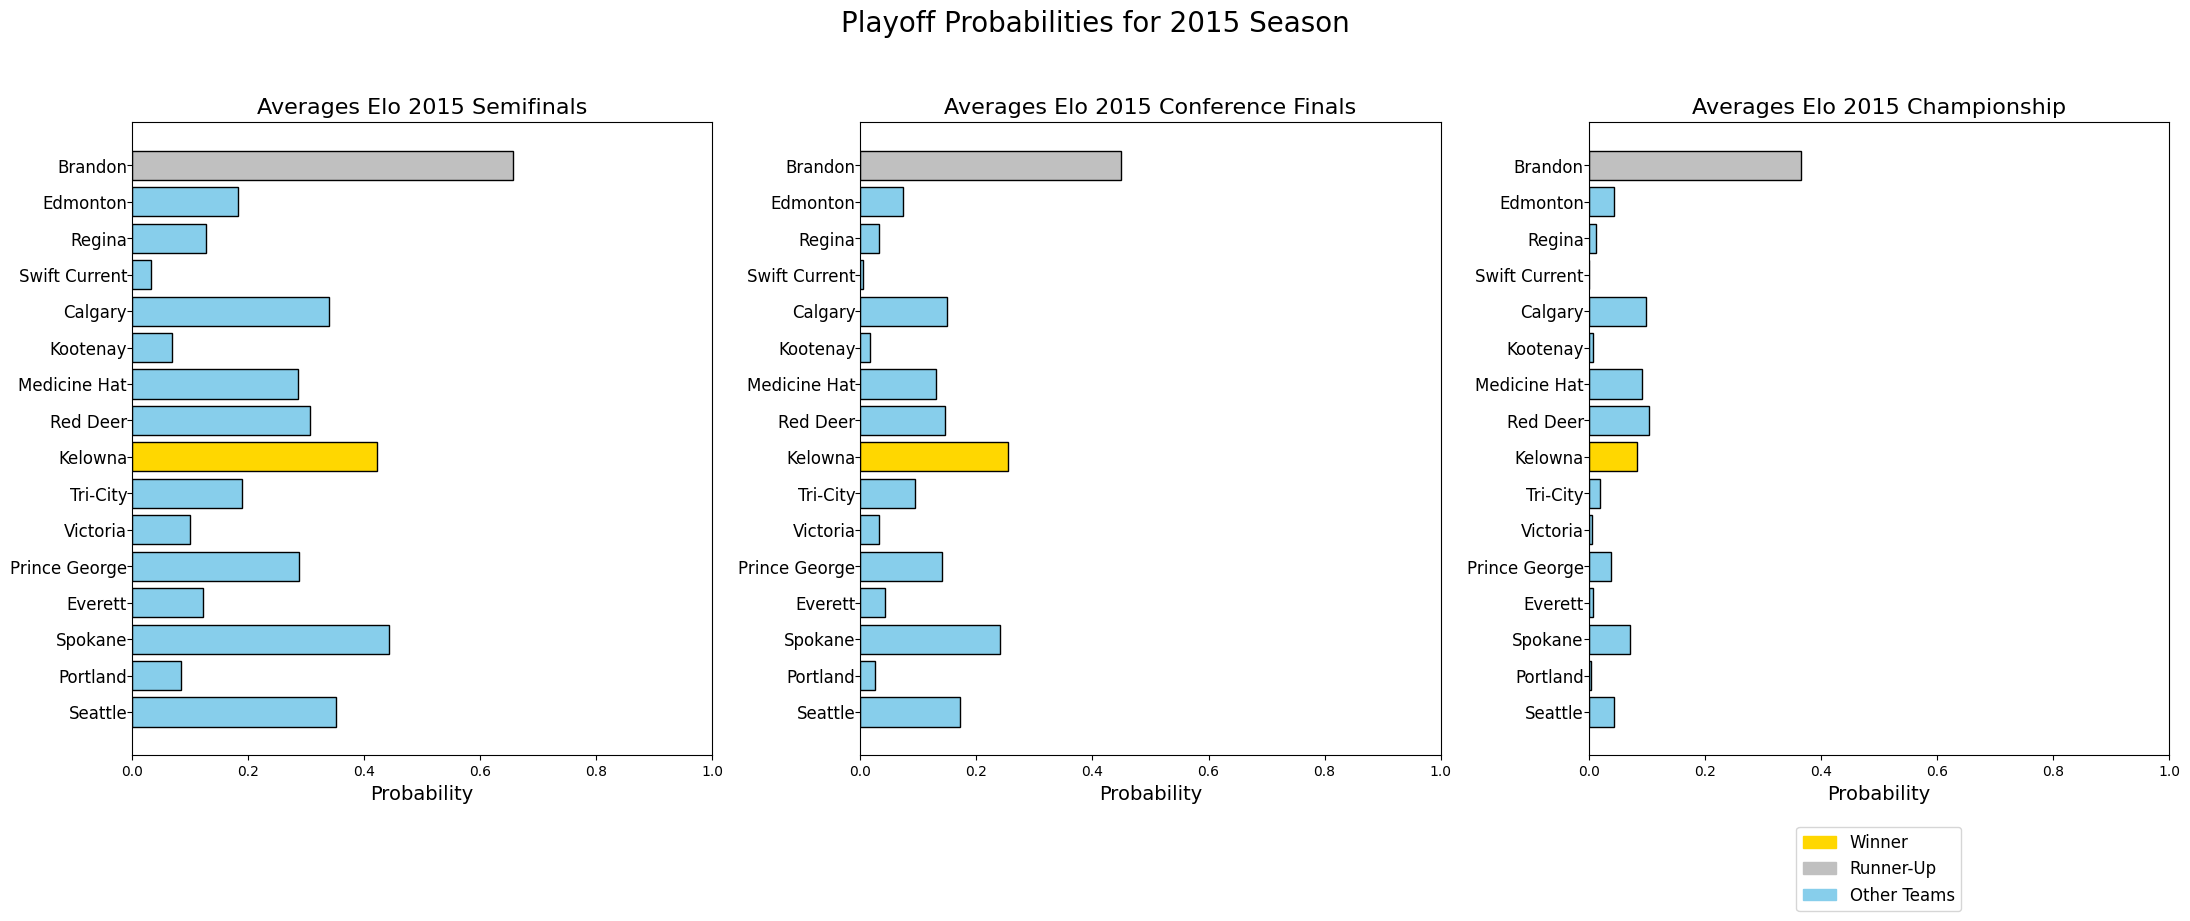

Processing year 2014...


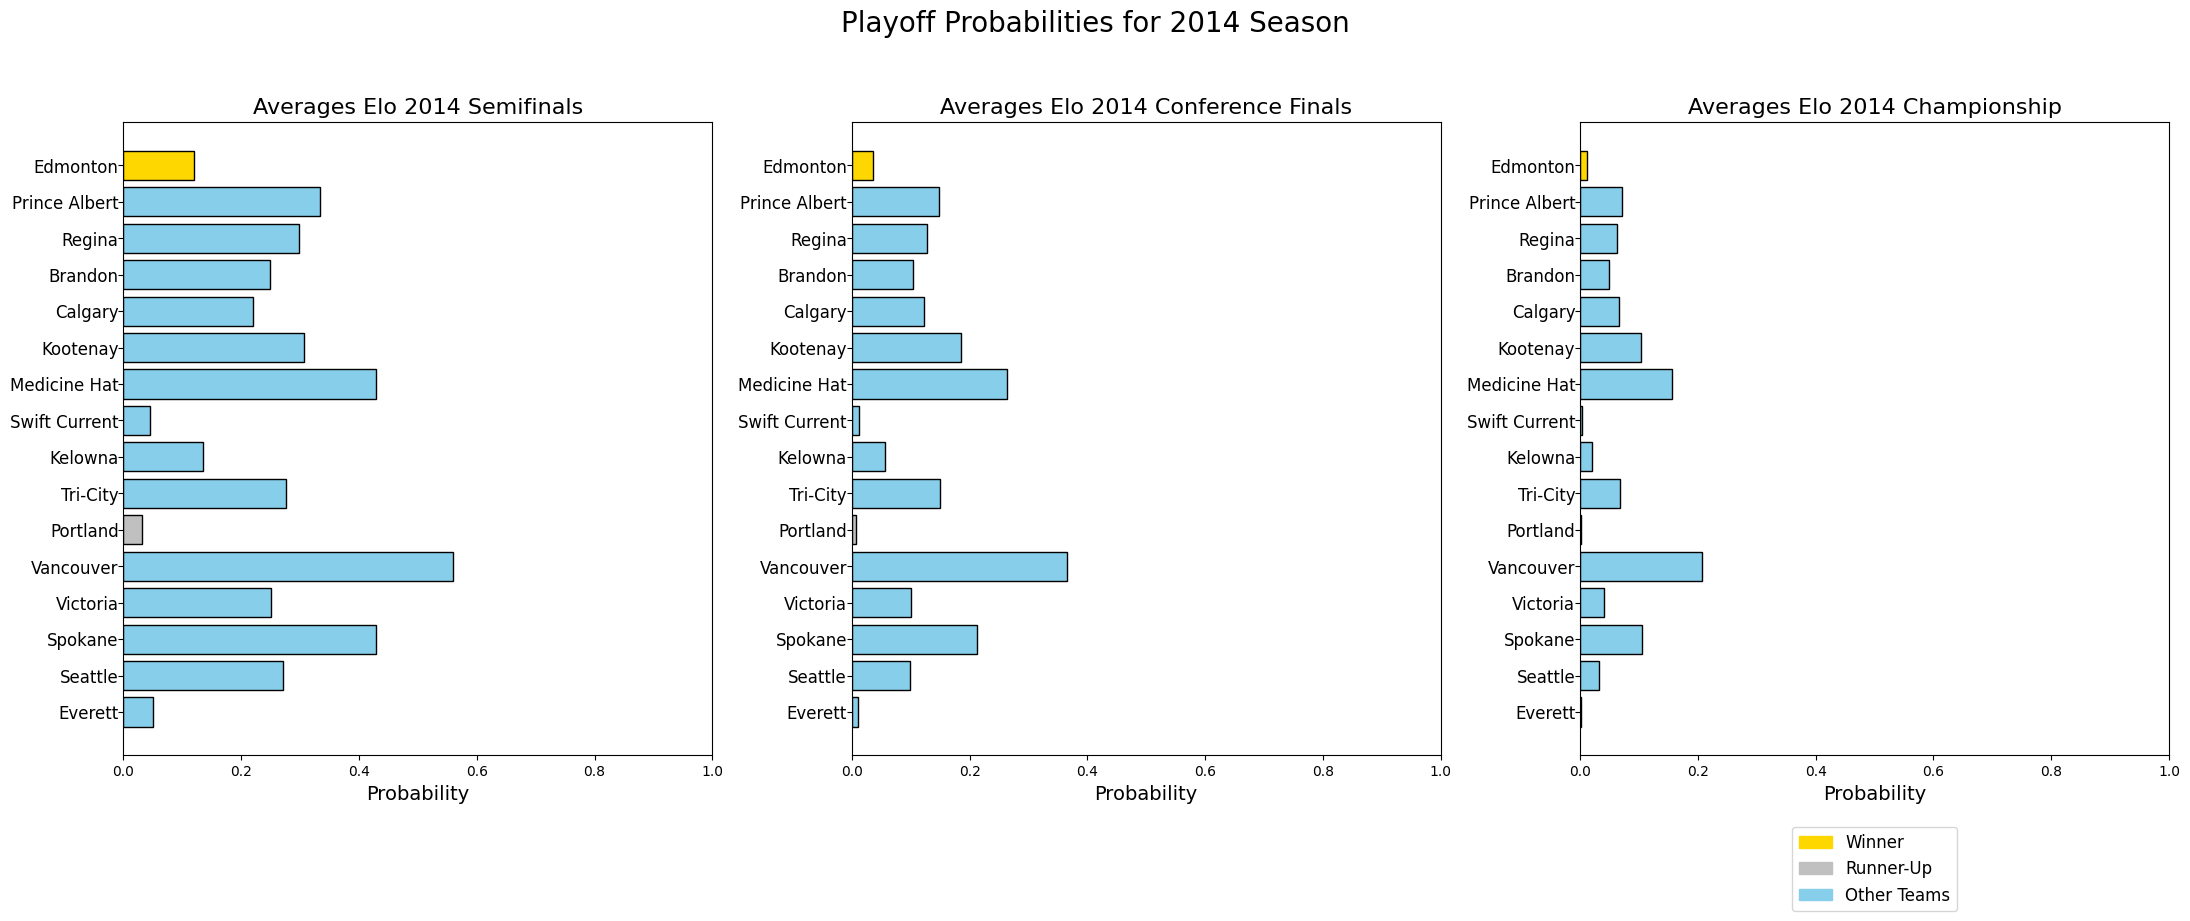

Processing year 2013...


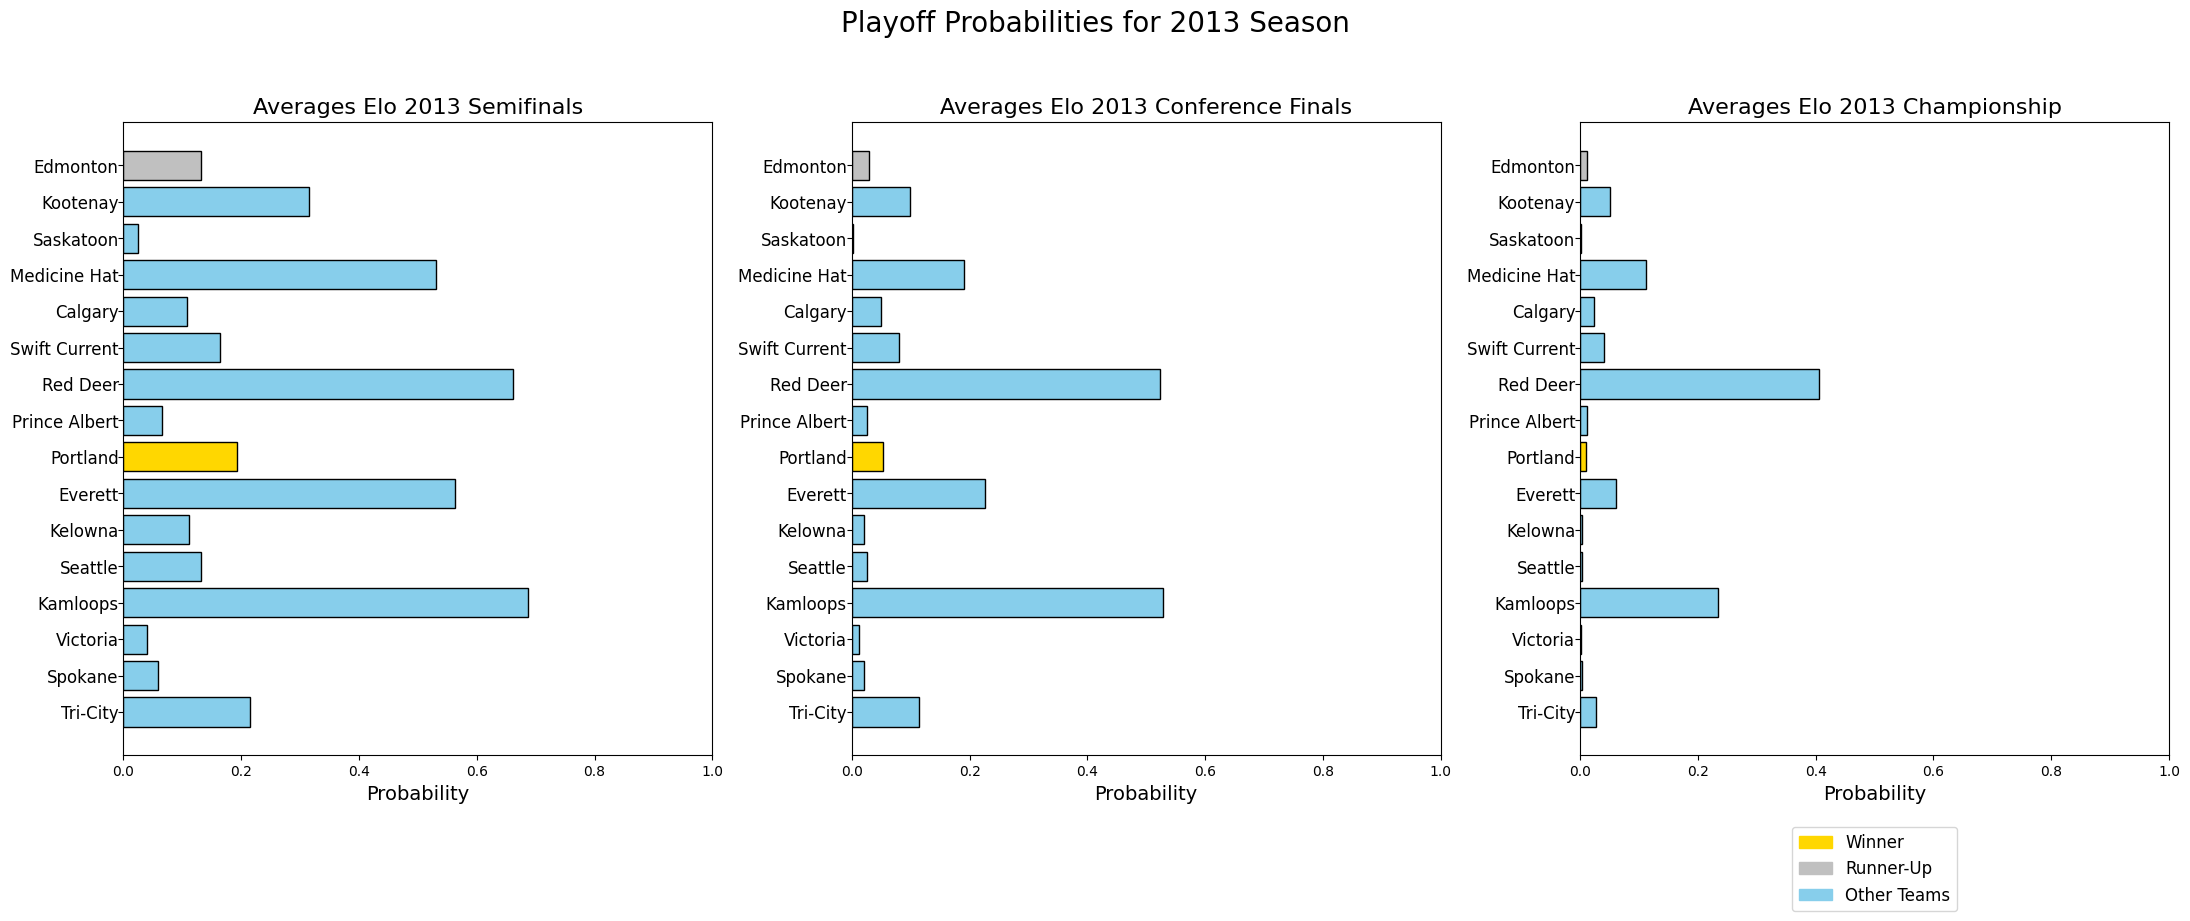

Processing year 2024...


KeyboardInterrupt: 

In [ ]:
for year in season_results_avg_std_stats.keys():
  plot_playoff_probabilities(season_results_avg_std_stats, winners_dict, runners_up_dict)